# Two Steps MultiFidelity Neural Network

Code to show the performance of the Neural Network when dealing with different LF datasets 

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)




Ray module not found. Multiprocessing features are not available


True

In [2]:
# reproducibility
seed = 7
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [3]:
# import of the train data
# st.Venant constitutive law for the HF data

mu_train_HF = np.loadtxt("../DATA_shear/Data_Train_bases_short/mu_train_HF.txt")
U_hf_train = np.loadtxt("../DATA_shear/Data_Train_bases_short/Uhf_train.txt")


# Linear constitutive law for the LF data
mu_train_LF = np.loadtxt("../DATA_shear/Data_Train_bases_linshort/mu_train_LF.txt")
U_lf_train = np.loadtxt("../DATA_shear/Data_Train_bases_linshort/Ulf_train.txt")
n_bases_train= U_lf_train.shape[1] 



In [4]:
# import of the test data
# st.Venant constitutive law for the HF data

mu_test = np.loadtxt("../DATA_shear/Data_Test_bases/mu_test.txt")
U_hf_test = np.loadtxt("../DATA_shear/Data_Test_bases/Uhf_test.txt")
mu_max = np.loadtxt("../DATA_shear/Data_Test_bases/mu_max.txt")
mu_min = np.loadtxt("../DATA_shear/Data_Test_bases/mu_min.txt")

# st.Venant constitutive law for the LF data
U_lf_test = np.loadtxt("../DATA_shear/Data_Test_bases/Ulf_test.txt")
n_bases_test= U_lf_test.shape[1]

n_bases=min(n_bases_test,n_bases_train)

print(f"Nb. of considered bases is {n_bases}")
# I create a list of the models
model_list=[0]*n_bases

Nb. of considered bases is 7


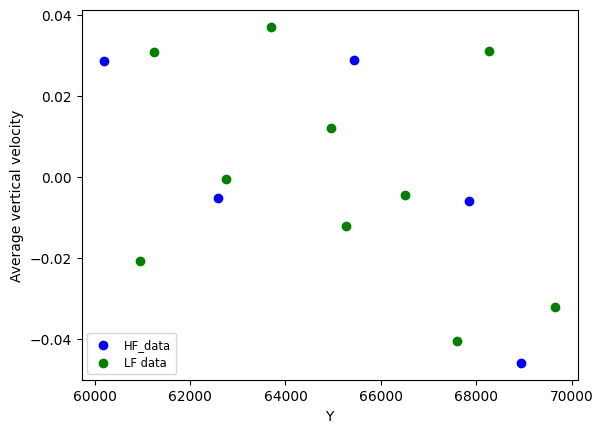

In [5]:
plt.scatter(mu_train_HF[:,0], U_hf_train-np.mean(U_hf_train), label='HF_data', color='blue', marker='o')
plt.scatter(mu_train_LF[:,0], U_lf_train[:,0]-np.mean(U_lf_train[:,0]), label='LF data', color='green', marker='o')
plt.xlabel('Y')
plt.ylabel('Average vertical velocity')
plt.legend(prop={'size': 8.3})
plt.show()

In [6]:
U_lf_train=U_lf_train-np.mean(U_hf_train)
U_hf_train=U_hf_train-np.mean(U_hf_train)

U_lf_test=U_lf_test-np.mean(U_hf_test)
U_hf_test=U_hf_test-np.mean(U_hf_test)


mu_test=(mu_test-mu_min)/(mu_max-mu_min)
mu_train_HF=(mu_train_HF-mu_min)/(mu_max-mu_min)
mu_train_LF=(mu_train_LF-mu_min)/(mu_max-mu_min)

In [7]:
# Number of data of High and Low Fidelity components of the dataset
n_HF = np.array([5])
Nlf = np.array([10])

batch_size=[10,5]

In [8]:
U_LF_list = []
U_HF_list = []
# number of epochs 
Nepo=[3000,2000]

# NepoLF = 7000  # number of epochs for first NN: NN_LF
# NepoHF = 8000  # number of epochs for second NN: NN_HF

r2_HF_df = pandas.DataFrame(columns=['NB.basis','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['NB.basis','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['NB.basis','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['NB.basis','MSE'])  # dataframe which stores LF MSE



## Neural Network
Cycle on the Discretization and the value of the diffusion 

Folder '2_step_models' already exists.
********************  # Nb. basis = 0  ********************
********************  # NHF: = 5  ********************
********************  # NLF: = 10  ********************





The function training took 6.773277521133423 seconds.


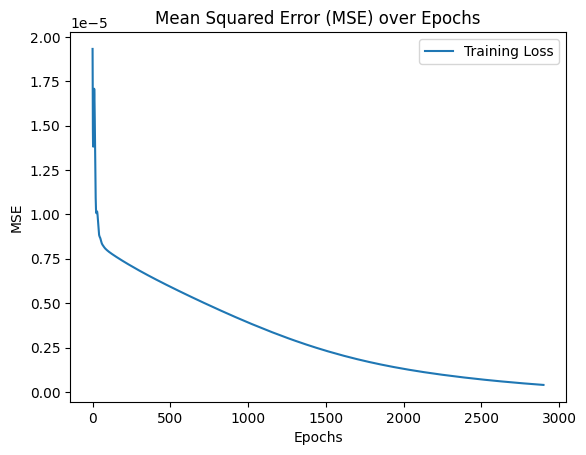

The function training took 4.106926202774048 seconds.


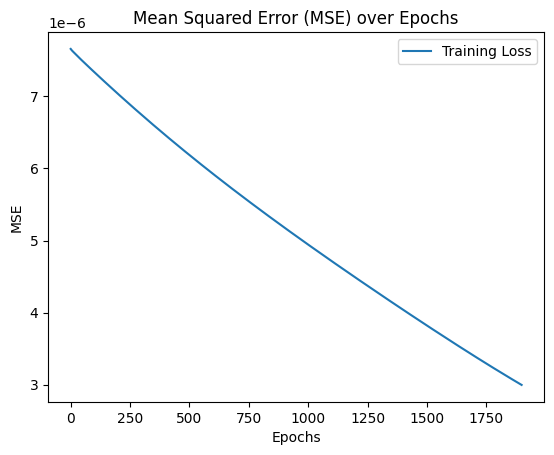

low fidelity NN
Test MSE: 0.0005581575126327302
R^2: -1.1777992797884576
Final model
Test MSE: 3.234931791382035e-06
R^2: 0.9952029435479081


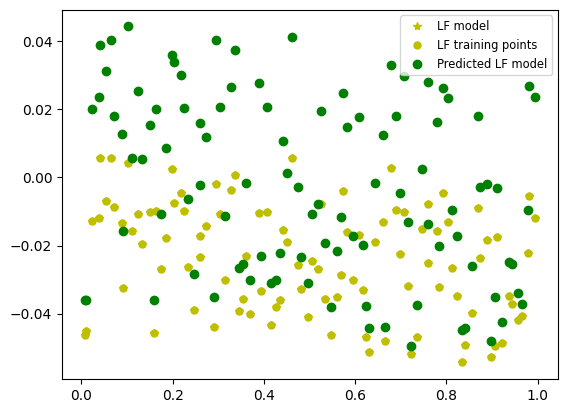

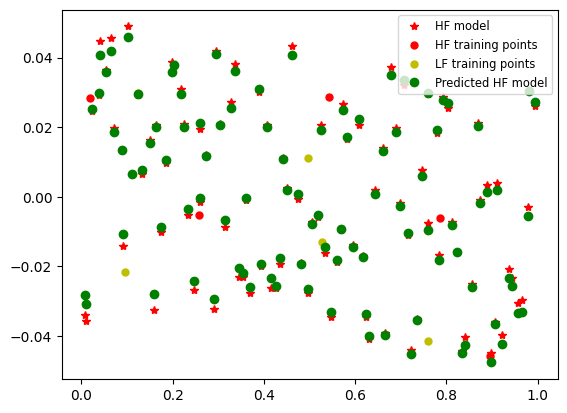

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_22192\2797720693.py:143: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_LF_df = pandas.concat([r2_LF_df, pandas.DataFrame([new_data])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_22192\2797720693.py:147: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_HF_df = pandas.concat([r2_HF_df, pandas.DataFrame([new_data])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_22192\2797720693.py:151: FutureWarning: The beha

Saving ...
********************  # Nb. basis = 1  ********************
********************  # NHF: = 5  ********************
********************  # NLF: = 10  ********************
The function training took 6.661936283111572 seconds.


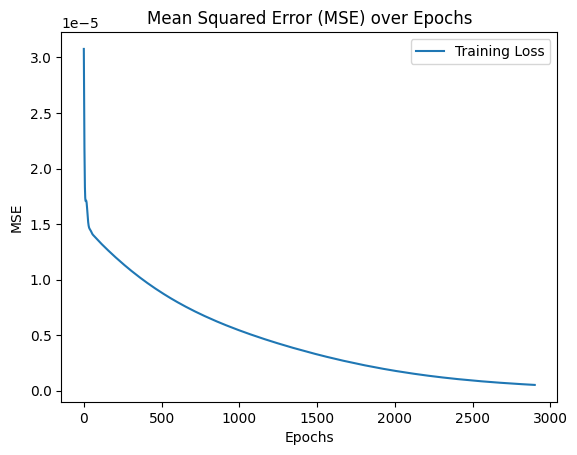

The function training took 4.038180351257324 seconds.


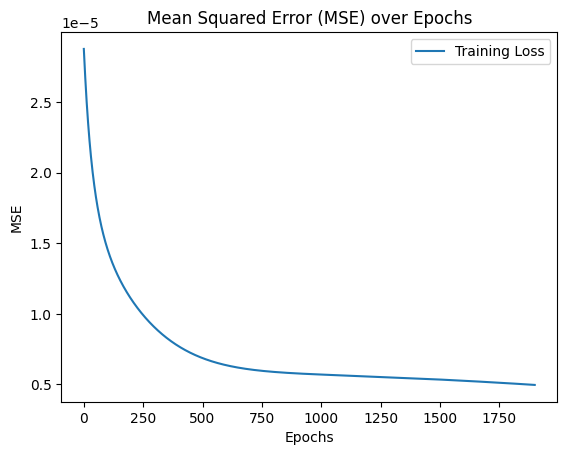

low fidelity NN
Test MSE: 2.9428902074369305e-06
R^2: 0.9955664717897181
Final model
Test MSE: 3.1318892445808283e-06
R^2: 0.9953557445792279


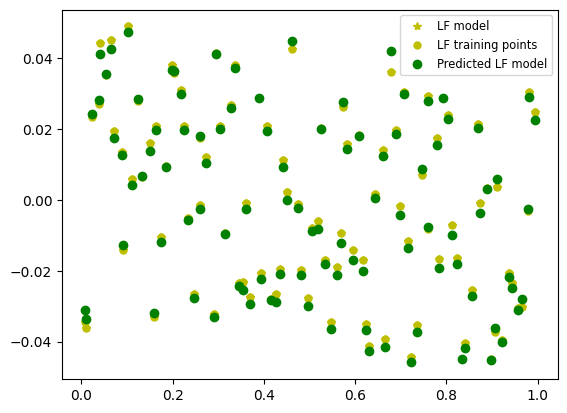

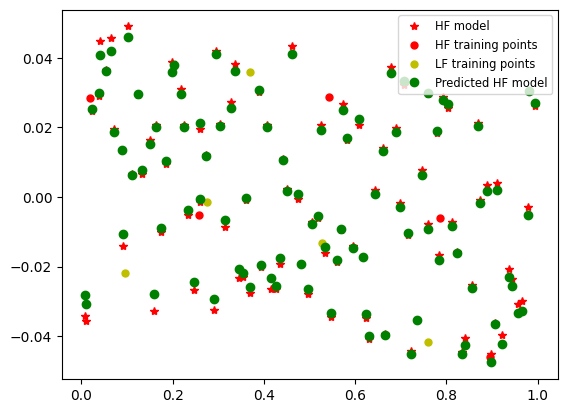

Saving ...
********************  # Nb. basis = 2  ********************
********************  # NHF: = 5  ********************
********************  # NLF: = 10  ********************


c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Shear_NN\../utils\Structure.py:576: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(self.model_list[index].model,folder)


The function training took 6.138159275054932 seconds.


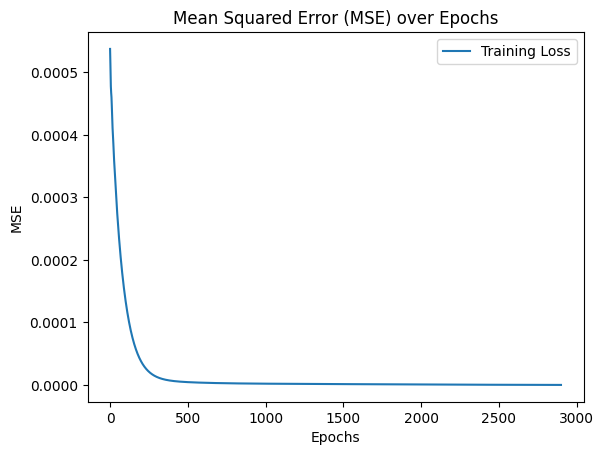

The function training took 3.8206052780151367 seconds.


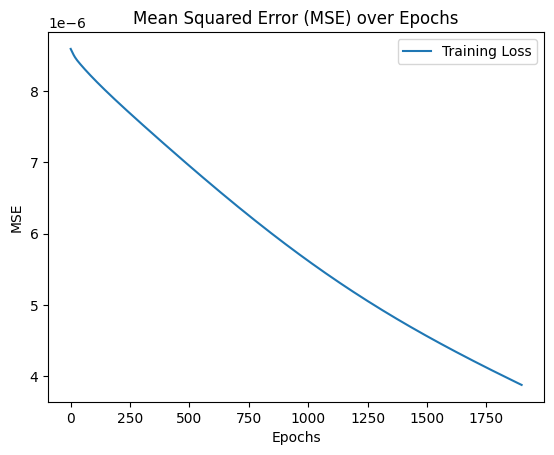

low fidelity NN
Test MSE: 3.5531628643999164e-05
R^2: 0.947086289335441
Final model
Test MSE: 3.3933723591484398e-06
R^2: 0.9949679932006081


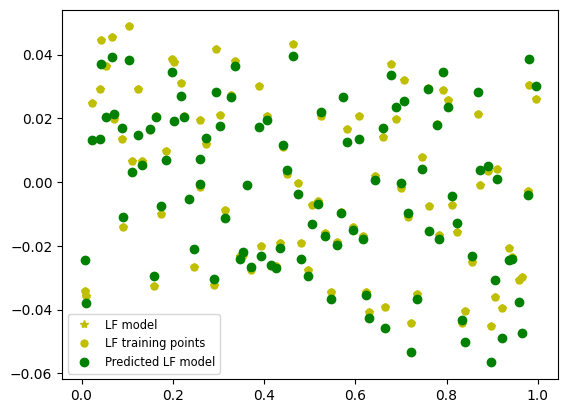

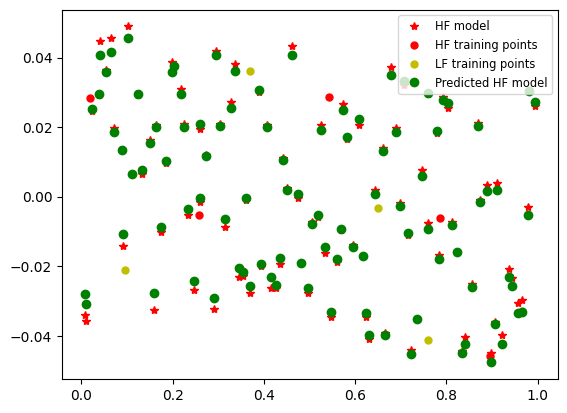

Saving ...
********************  # Nb. basis = 3  ********************
********************  # NHF: = 5  ********************
********************  # NLF: = 10  ********************


c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Shear_NN\../utils\Structure.py:576: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(self.model_list[index].model,folder)


The function training took 6.279229640960693 seconds.


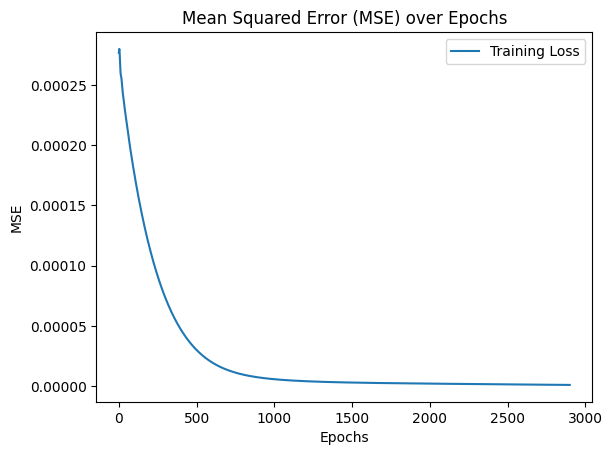

The function training took 4.064412593841553 seconds.


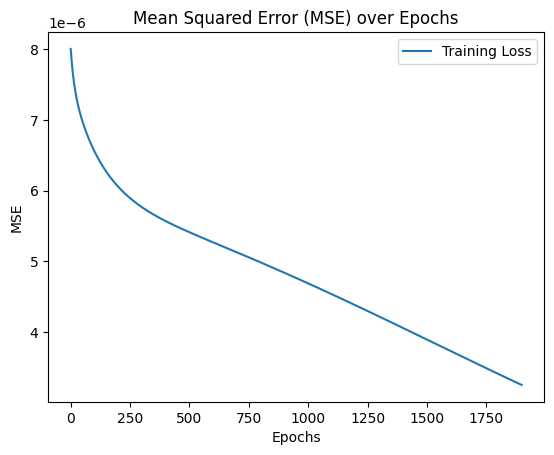

low fidelity NN
Test MSE: 1.3368251025468209e-05
R^2: 0.9800701039788152
Final model
Test MSE: 3.2986723512973497e-06
R^2: 0.9951084231425579


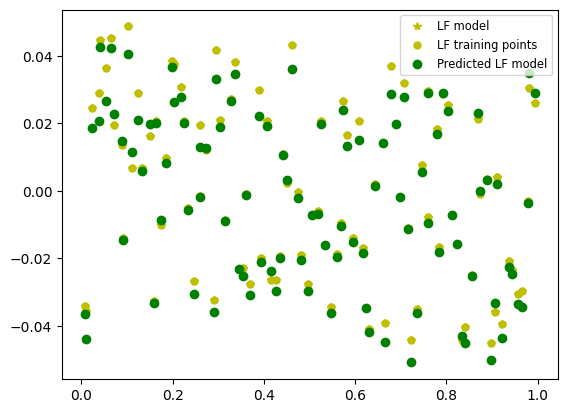

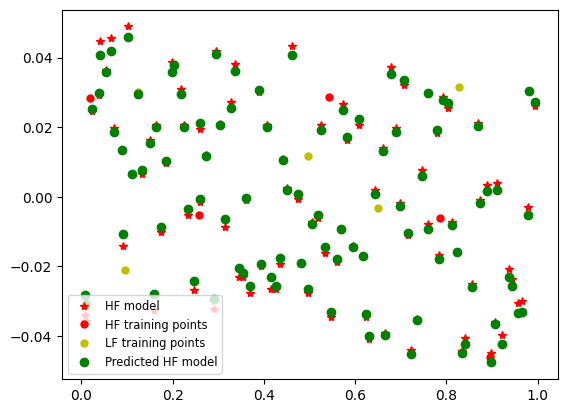

Saving ...
********************  # Nb. basis = 4  ********************
********************  # NHF: = 5  ********************
********************  # NLF: = 10  ********************


c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Shear_NN\../utils\Structure.py:576: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(self.model_list[index].model,folder)


The function training took 6.297143459320068 seconds.


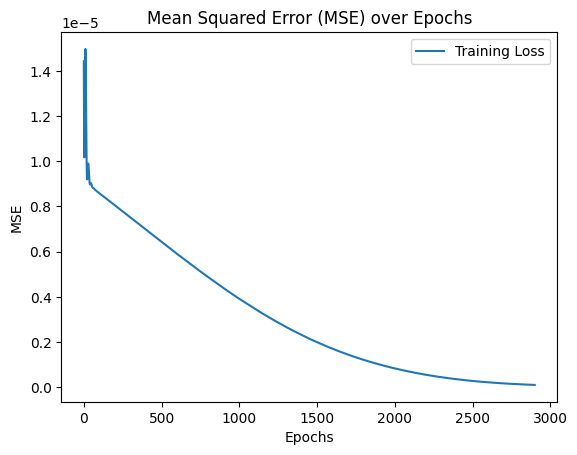

The function training took 4.051826477050781 seconds.


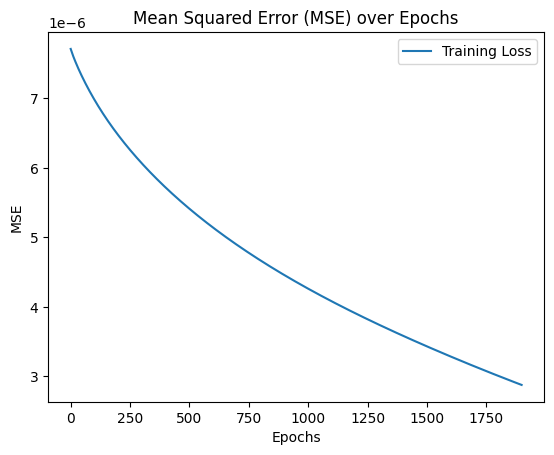

low fidelity NN
Test MSE: 8.398690698298308e-06
R^2: 0.9874872730923587
Final model
Test MSE: 3.2587003491202475e-06
R^2: 0.9951676973292525


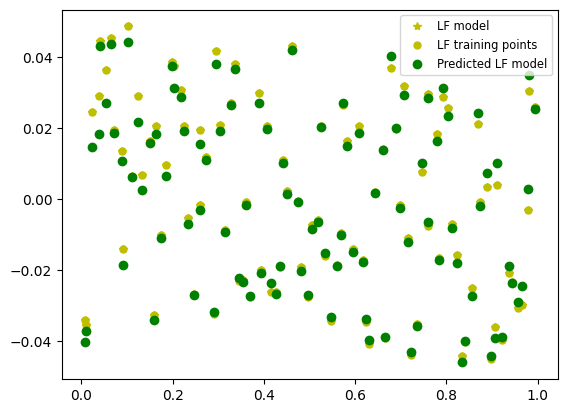

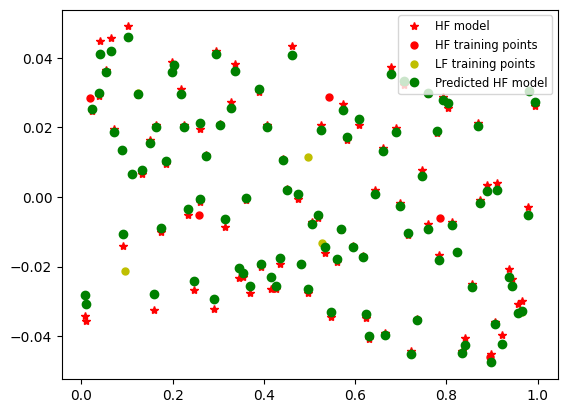

Saving ...
********************  # Nb. basis = 5  ********************
********************  # NHF: = 5  ********************
********************  # NLF: = 10  ********************


c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Shear_NN\../utils\Structure.py:576: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(self.model_list[index].model,folder)


The function training took 6.213379859924316 seconds.


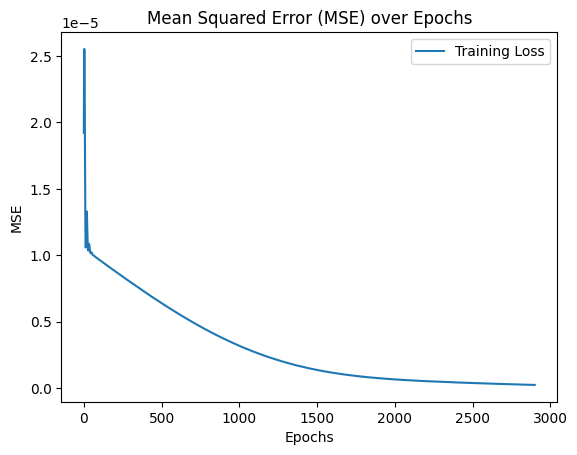

The function training took 4.00531530380249 seconds.


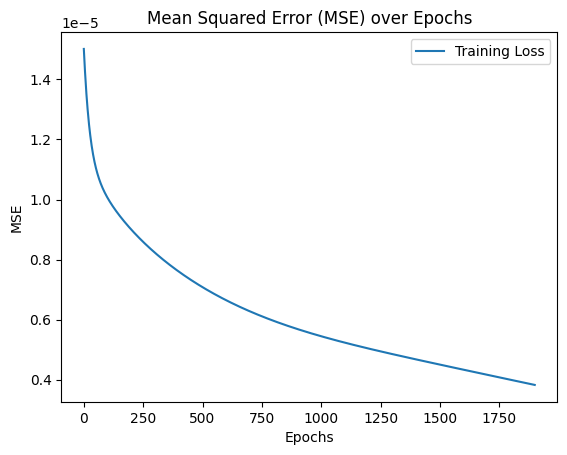

low fidelity NN
Test MSE: 5.370229213062959e-06
R^2: 0.9920309498972778
Final model
Test MSE: 3.299586675920065e-06
R^2: 0.9951070672973303


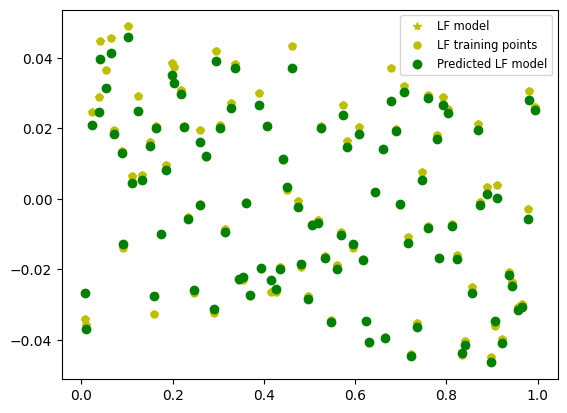

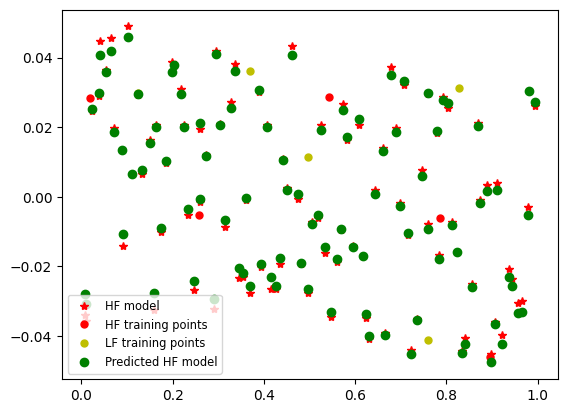

Saving ...
********************  # Nb. basis = 6  ********************
********************  # NHF: = 5  ********************
********************  # NLF: = 10  ********************


c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Shear_NN\../utils\Structure.py:576: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(self.model_list[index].model,folder)


The function training took 6.347299337387085 seconds.


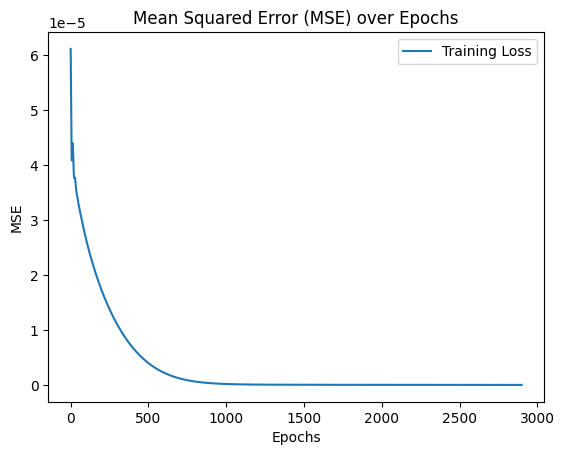

The function training took 3.802407741546631 seconds.


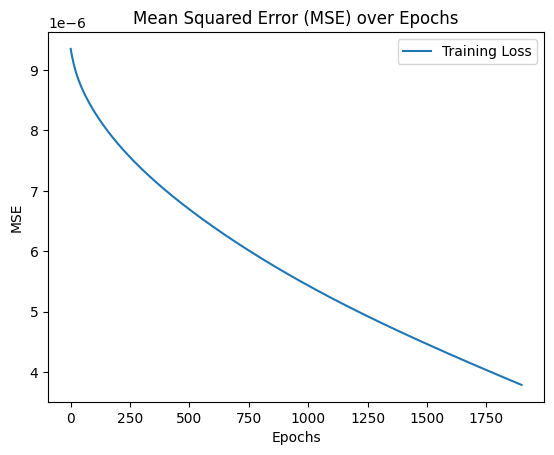

low fidelity NN
Test MSE: 8.814207337781537e-06
R^2: 0.9869250318512094
Final model
Test MSE: 3.176924845859813e-06
R^2: 0.9952889616188376


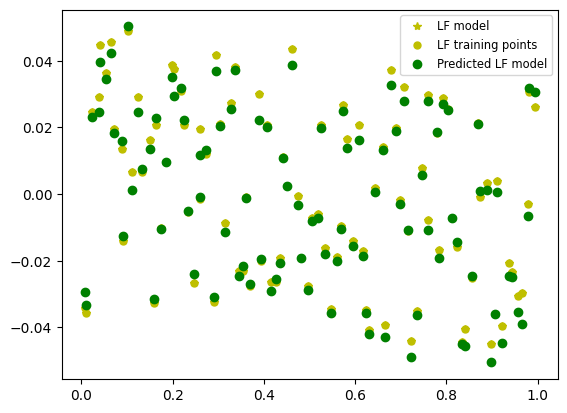

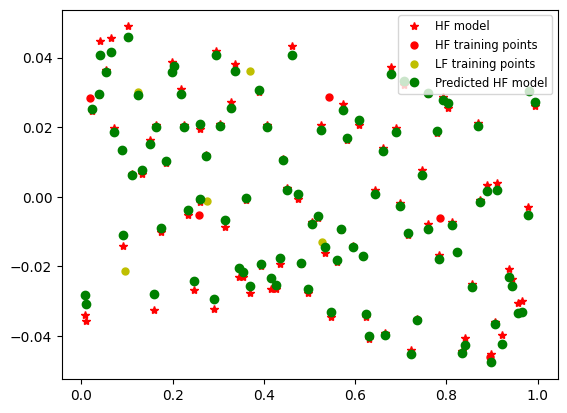

Saving ...
  NB.basis       R2
0        1  0.99520
1        2  0.99536
2        3  0.99497
3        4  0.99511
4        5  0.99517
5        6  0.99511
6        7  0.99529
  NB.basis  MSE       R2
0        1  0.0  0.99520
1        2  0.0  0.99536
2        3  0.0  0.99497
3        4  0.0  0.99511
4        5  0.0  0.99517
5        6  0.0  0.99511
6        7  0.0  0.99529


c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Shear_NN\../utils\Structure.py:576: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(self.model_list[index].model,folder)


In [9]:
# Name of the folder
folder_name = "2_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")

test_mse_HF_list = []
test_mse_LF_list = []

r2_HF_list = []
r2_LF_list = []

for m in range(n_bases):

    for nhf in n_HF:
        for nlf in Nlf:
    
            print(
            f"********************  # Nb. basis = {m}  ********************"
            )
            
            print(
            f"********************  # NHF: = {nhf}  ********************"
            )
            print(
            f"********************  # NLF: = {nlf}  ********************"
            )
           
            
            # randomization and selection of the training set
            permutation = np.random.permutation(len(mu_train_HF))
            mu_HF = mu_train_HF[permutation,:][0:nhf,:]
            U_HF = U_hf_train[permutation][0:nhf]
            
            permutation = np.random.permutation(len(mu_train_LF))
            mu_LF = mu_train_LF[permutation][0:nlf]
            U_train_LF = U_lf_train[permutation,m][0:nlf]

            ##########################      Neural Network     ##########################
            K.clear_session()
            
            # parameters 
            bestLF_params = {
                "lr": 0.0255,
                "kernel_init": "glorot_uniform",
                "opt": "Adamax",
            } 
            best_params = {'kernel_init': 'uniform', 'l2weight': 0.00012051711558537875, 'lr': 0.0017624104175516413, 'nodes': 18.0, 'opt': 'Adamax'}

            # Multifidelity network 
            names=["LF","HF"]
            params=[bestLF_params, best_params]
            data_train=[mu_LF, mu_HF]
            output_train=[U_train_LF,U_HF]
            model= NetworkFactory.build_network("2step",names,params=params,data_train=data_train,output_train=output_train,N=Nepo,n=batch_size,do_HPO=False,verbose=False)

            # low fidelity part of the network 
            ULF = model.model_list[0].prediction(mu_test)
            print("low fidelity NN")
            
            (test_mse_LF,r2_LF) = model.model_list[0].performance(mu_test,U_lf_test[:,m])
            test_mse_LF_list.append(test_mse_LF)
            r2_LF_list.append(r2_LF)

            # creation of the input of the second part of the 2 steps NN to study the high fidelity model
            input_HF = np.concatenate(
                (mu_test,  model.model_list[0].prediction(mu_test).reshape(-1,1)),axis=1
            )  # <- TRAINING INPUT for the second NN: NN_HF

            input_HF_train = np.concatenate(
                (mu_HF,  model.model_list[0].prediction(mu_HF).reshape(-1,1)),axis=1
            ) 
            # performance of the last part of the network
            print("Final model")
            (test_mse_HF,r2_HF) = model.model_list[1].performance(input_HF,U_hf_test)                
            test_mse_HF_list.append(test_mse_HF)
            r2_HF_list.append(r2_HF)
            
            
            # plots of the model
            plt.figure()
            plt.plot(
            mu_test[:, 0], U_lf_test[:,m], "y*", linewidth=1.5, label="LF model"
            )
            plt.plot(
            mu_test[:, 0],
            U_lf_test[:,m],
            "yo",
            markersize=5,
            label="LF training points",
            )
            plt.plot(
            mu_test[:, 0],
            model.model_list[0].prediction(mu_test),
            "go",
            linewidth=3,
            label="Predicted LF model",
            )
            plt.legend(prop={"size": 8.3})
            plt.show()
            
            plt.figure()
            plt.plot(
            mu_test[:,0], U_hf_test, "r*", linewidth=1.5, label="HF model"
            )
            plt.plot(
            mu_HF[:, 0],
            U_HF,
            "ro",
            markersize=5,
            label="HF training points",
            )
            
            
            order=np.argsort(mu_HF[:,0])
            
            plt.plot(
            mu_LF[order,0],
            U_train_LF[order],
            "yo",
            markersize=5,
            label="LF training points",
            )
            plt.plot(
            input_HF[:, 0],
            model.model_list[1].prediction(input_HF),
            "go",
            linewidth=3,
            label="Predicted HF model",
            )
            plt.legend(prop={"size": 8.3})
            plt.show()
            
            new_data = {'NB.basis': m+1}

            # DataFrame r2_LF_df
            new_data['R2'] = r2_LF_list[-1]
            r2_LF_df = pandas.concat([r2_LF_df, pandas.DataFrame([new_data])], ignore_index=True)

            # DataFrame r2_HF_df
            new_data['R2'] = r2_HF_list[-1]
            r2_HF_df = pandas.concat([r2_HF_df, pandas.DataFrame([new_data])], ignore_index=True)

            # DataFrame mse_LF_df
            new_data['MSE'] = test_mse_LF_list[-1]
            mse_LF_df = pandas.concat([mse_LF_df, pandas.DataFrame([new_data])], ignore_index=True)

            # DataFrame mse_HF_df
            new_data['MSE'] = test_mse_HF_list[-1]
            mse_HF_df = pandas.concat([mse_HF_df, pandas.DataFrame([new_data])], ignore_index=True)
        
        
            # save the model
            model_list[m]=model
            model.save(str(m),folder_path)

        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

## Save the output

In [10]:
# os.makedirs(folder_path)

# r2_HF_df.to_csv(
#     "./{folder_name}/r2_HF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
#     header=True,
#     index=False,
#     sep="\t",
#     mode="a",
# )
# mse_HF_df.to_csv(
#     "./{folder_name}/mse_HF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
#     header=True,
#     index=False,
#     sep="\t",
#     mode="a",
# )
# r2_LF_df.to_csv(
#     "./{folder_name}/r2_LF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
#     header=True,
#     index=False,
#     sep="\t",
#     mode="a",
# )
# mse_LF_df.to_csv(
#     "./{folder_name}/mse_LF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
#     header=True,
#     index=False,
#     sep="\t",
#     mode="a",
# )

# with open("./{folder_name}/U_HF_list.data", "wb") as filehandle:
#     # store the data as binary data stream
#     pickle.dump(U_HF_list, filehandle)

# with open("./{folder_name}/U_LF_list.data", "wb") as filehandle:
#     pickle.dump(U_LF_list, filehandle)

# Inverse problem

In [11]:
real_x = np.random.rand(1,3)

real values are [[0.15373916 0.64911885 0.55741353]]
Sampling chain 1/4


Running chain, α = 0.26: 100%|██████████| 2000/2000 [02:52<00:00, 11.58it/s]


Sampling chain 2/4


Running chain, α = 0.25: 100%|██████████| 2000/2000 [02:53<00:00, 11.55it/s]


Sampling chain 3/4


Running chain, α = 0.21: 100%|██████████| 2000/2000 [03:09<00:00, 10.55it/s]


Sampling chain 4/4


Running chain, α = 0.20: 100%|██████████| 2000/2000 [03:14<00:00, 10.30it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.4   0.441 0.531]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.400  0.677  -0.821    1.714      0.041    0.035     274.0     220.0   
x1  0.441  0.723  -0.859    1.768      0.051    0.036     199.0     345.0   
x2  0.531  0.695  -0.567    1.949      0.042    0.030     275.0     304.0   

    r_hat  
x0   1.02  
x1   1.02  
x2   1.02  
Autocorrelation...
[[0.24626084 0.20811885 0.02641353]]


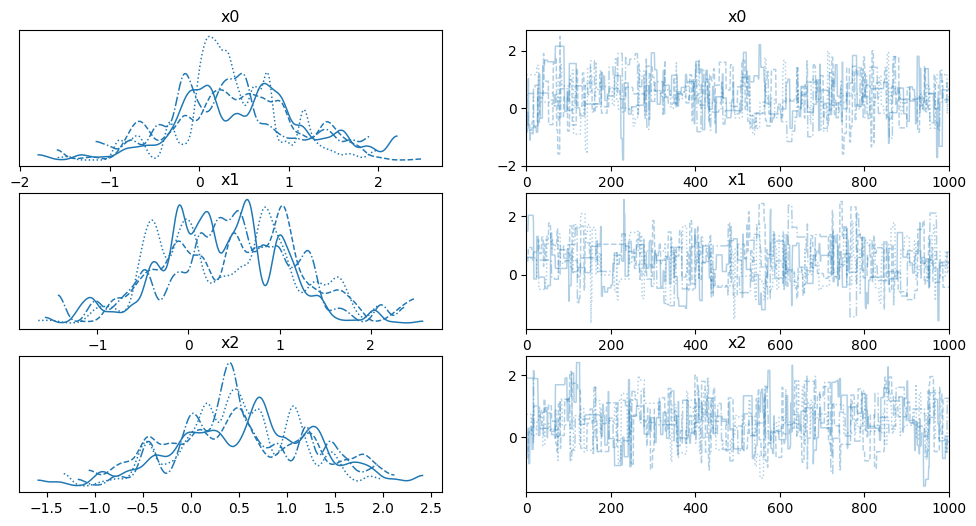

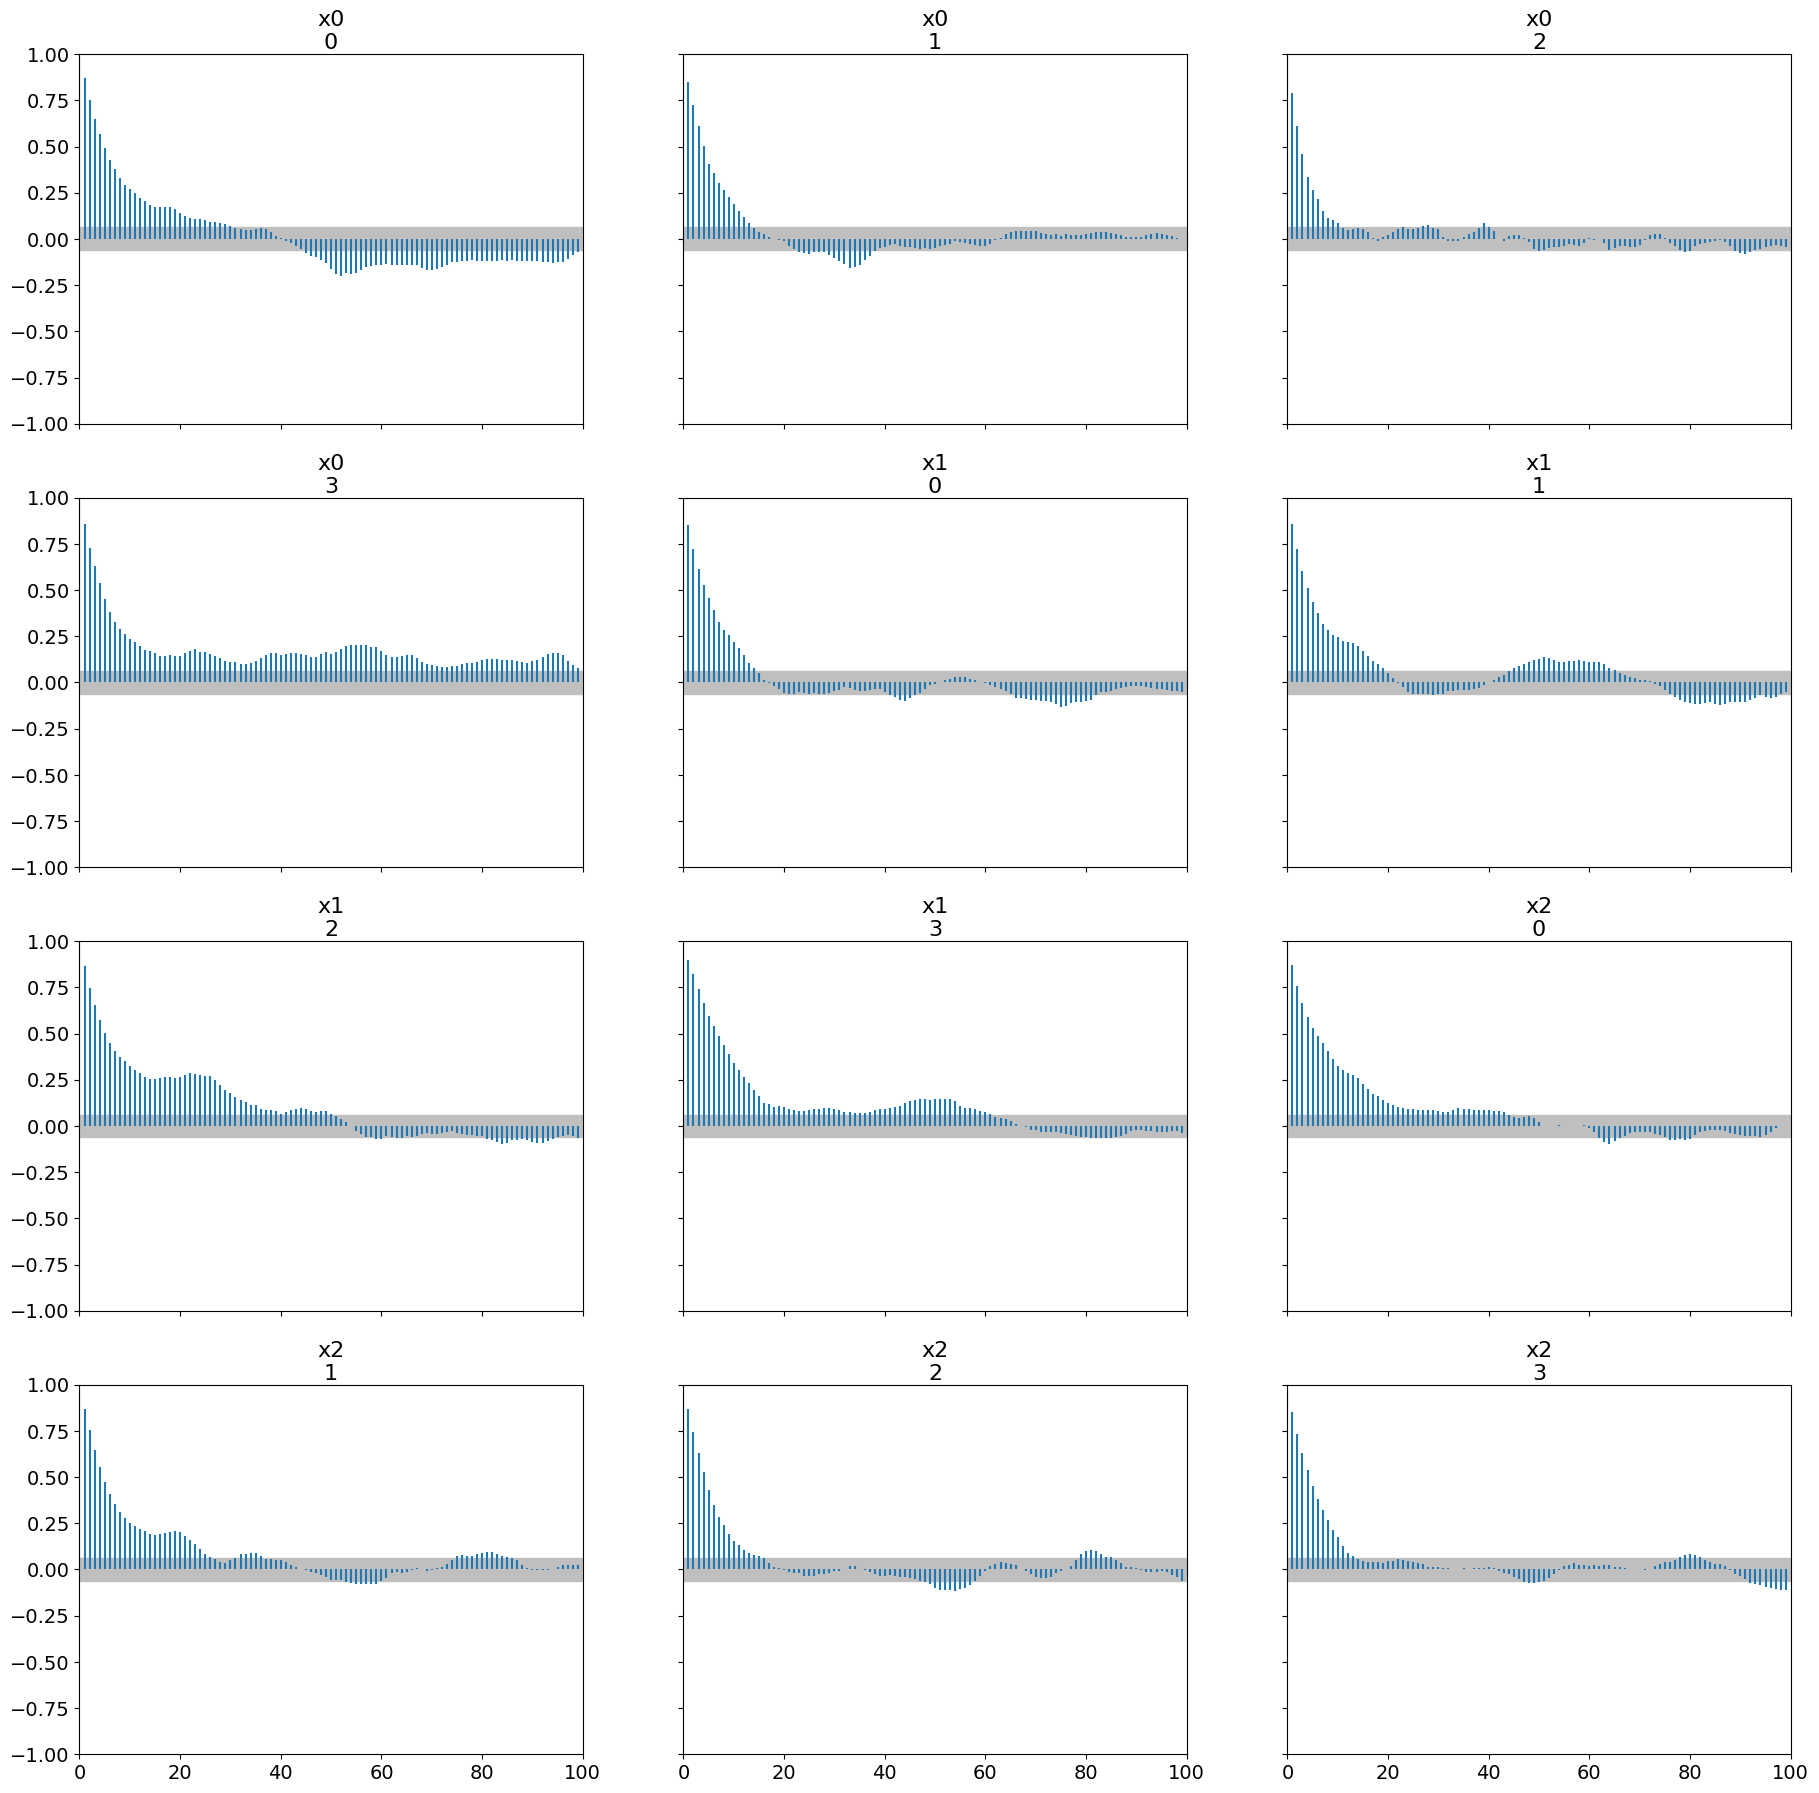

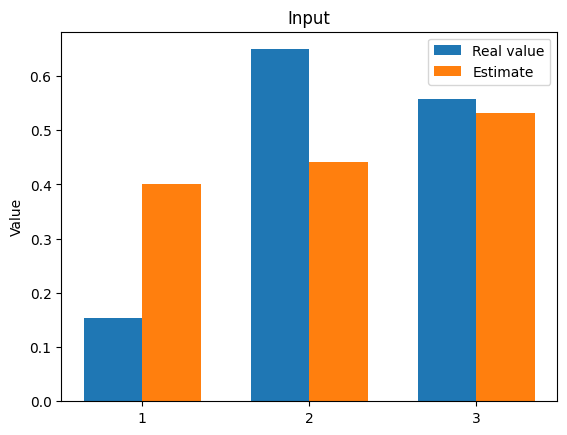

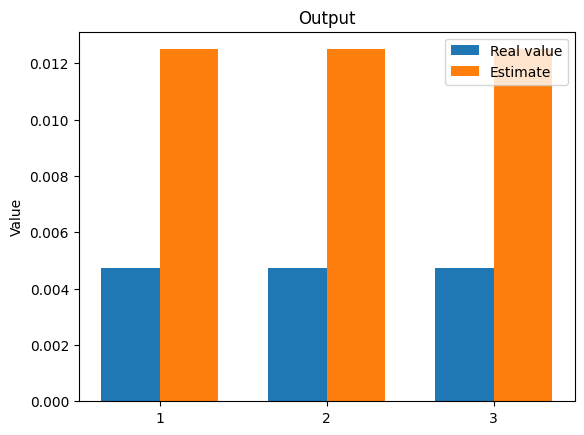

The function inverse took 758.2903468608856 seconds.


In [14]:

mean_prior=np.ones(3)*0.5
cov_prior=np.eye(3)*0.5
sigma=1
sigma_noise=0.005
rwmh_cov = np.eye(real_x.shape[1]) # !
rmwh_scaling = 0.01
rwmh_adaptive = True
iterations =2000
burnin = 1000
n_chains=4

closest_indices=np.argmin(np.sum(np.abs(mu_test - real_x),axis=1))
nearest_x=mu_test[closest_indices]
nearest_U=U_hf_test[closest_indices]
estimate_MF=model_list[-1].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="DREAMZ")


real values are [[0.15373916 0.64911885 0.55741353]]
Sampling chain 1/4


Running chain, α = 0.15: 100%|██████████| 3000/3000 [04:20<00:00, 11.53it/s]


Sampling chain 2/4


Running chain, α = 0.22: 100%|██████████| 3000/3000 [04:21<00:00, 11.48it/s]


Sampling chain 3/4


Running chain, α = 0.23: 100%|██████████| 3000/3000 [04:28<00:00, 11.17it/s]


Sampling chain 4/4


Running chain, α = 0.23: 100%|██████████| 3000/3000 [04:29<00:00, 11.12it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.513 0.499 0.553]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.513  0.724  -0.859    1.805      0.028    0.022     652.0     561.0   
x1  0.499  0.695  -0.754    1.766      0.027    0.019     661.0     712.0   
x2  0.553  0.709  -0.847    1.894      0.030    0.021     560.0     689.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.00  
Autocorrelation...
[[0.35926084 0.15011885 0.00441353]]


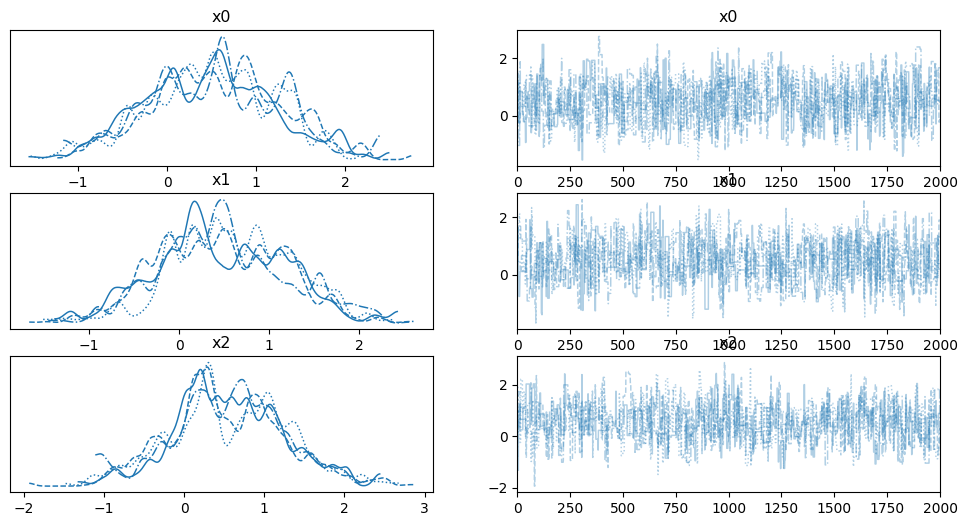

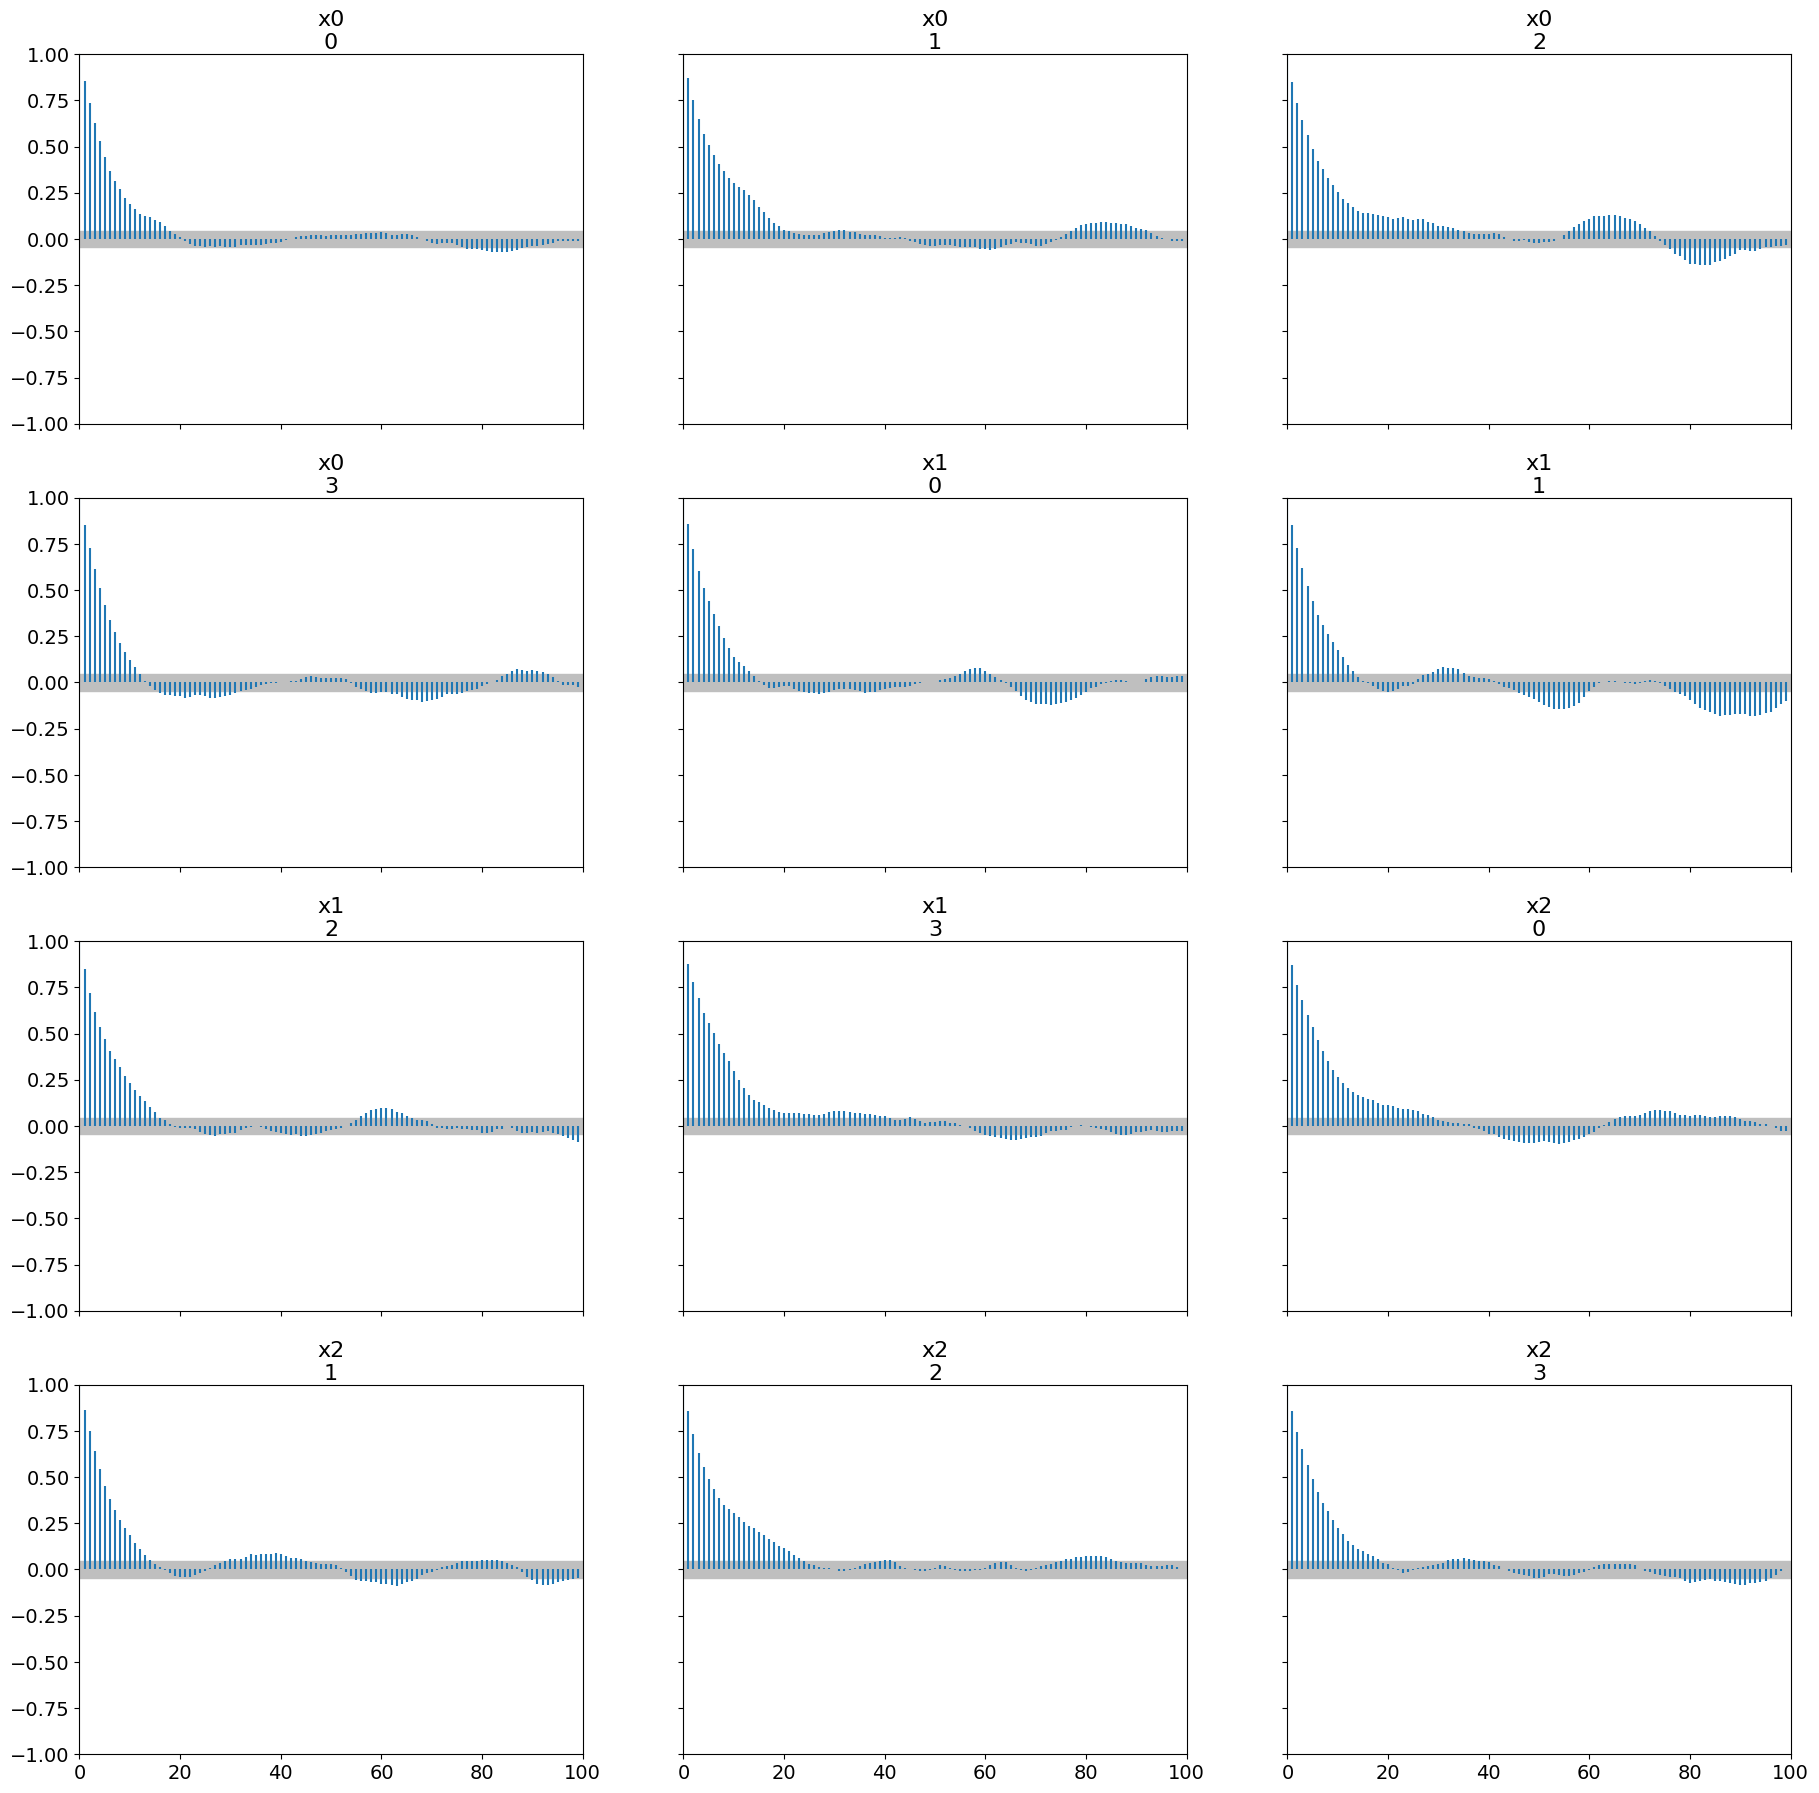

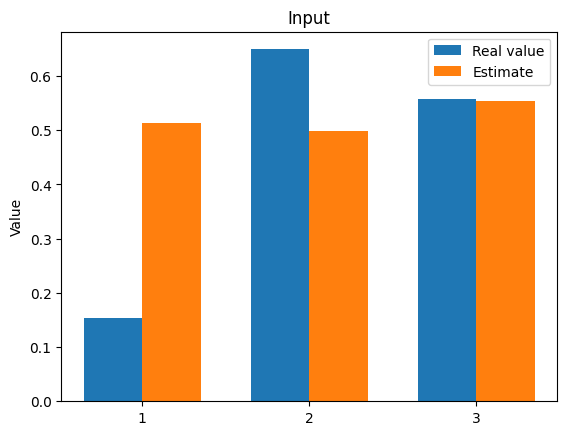

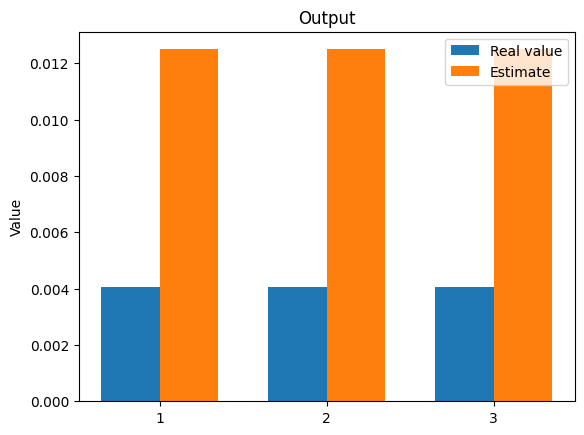

The function inverse took 1063.122566461563 seconds.


In [15]:

mean_prior=np.ones(3)*0.5
cov_prior=np.eye(3)*0.5
sigma=0.9
sigma_noise=0.005
rwmh_cov = np.eye(real_x.shape[1]) # !
rmwh_scaling = 0.01
rwmh_adaptive = True
iterations =3000
burnin = 1000
n_chains=4

closest_indices=np.argmin(np.sum(np.abs(mu_test - real_x),axis=1))
nearest_x=mu_test[closest_indices]
nearest_U=U_hf_test[closest_indices]
estimate_MF=model_list[-1].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="DREAMZ")


In [72]:
mean_prior=np.ones(3)*0.5
cov_prior=np.eye(3)*0.5
sigma=0.1
sigma_noise=0.005
rwmh_cov = np.eye(real_x.shape[1]) # !
rmwh_scaling = 0.2
rwmh_adaptive = False
iterations =1000
burnin = 500
n_chains=2

closest_indices=np.argmin(np.sum(np.abs(mu_test - real_x),axis=1))
nearest_x=mu_test[closest_indices]
nearest_U=U_hf_test[closest_indices]


fatto che alfa rimanga alto fa pensare che non abbia modo di "incastrarsi" a valore soddisfacente -> provo a mettere passo adaptive e a ridurre varianza


real values are [[0.55310878 0.78299984 0.97284695]]
Sampling chain 1/2


Running chain, α = 0.44: 100%|██████████| 1000/1000 [01:26<00:00, 11.60it/s]


Sampling chain 2/2


Running chain, α = 0.50: 100%|██████████| 1000/1000 [01:25<00:00, 11.68it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.539 0.484 0.456]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.539  0.666  -0.601    1.700      0.064    0.046     110.0     199.0   
x1  0.484  0.685  -0.901    1.570      0.063    0.044     123.0     174.0   
x2  0.456  0.559  -0.438    1.535      0.052    0.037     114.0     168.0   

    r_hat  
x0   1.00  
x1   1.02  
x2   1.01  
Autocorrelation...
[[0.01410878 0.29899984 0.51684695]]


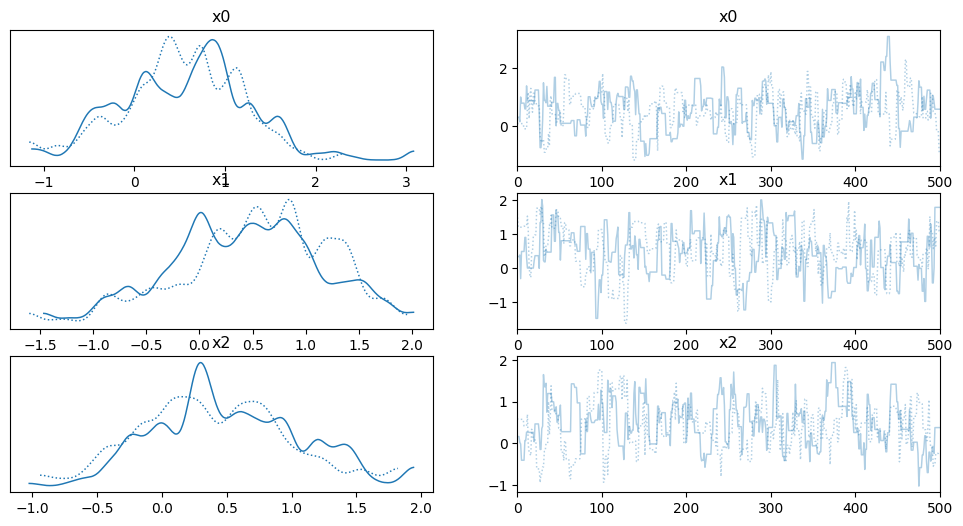

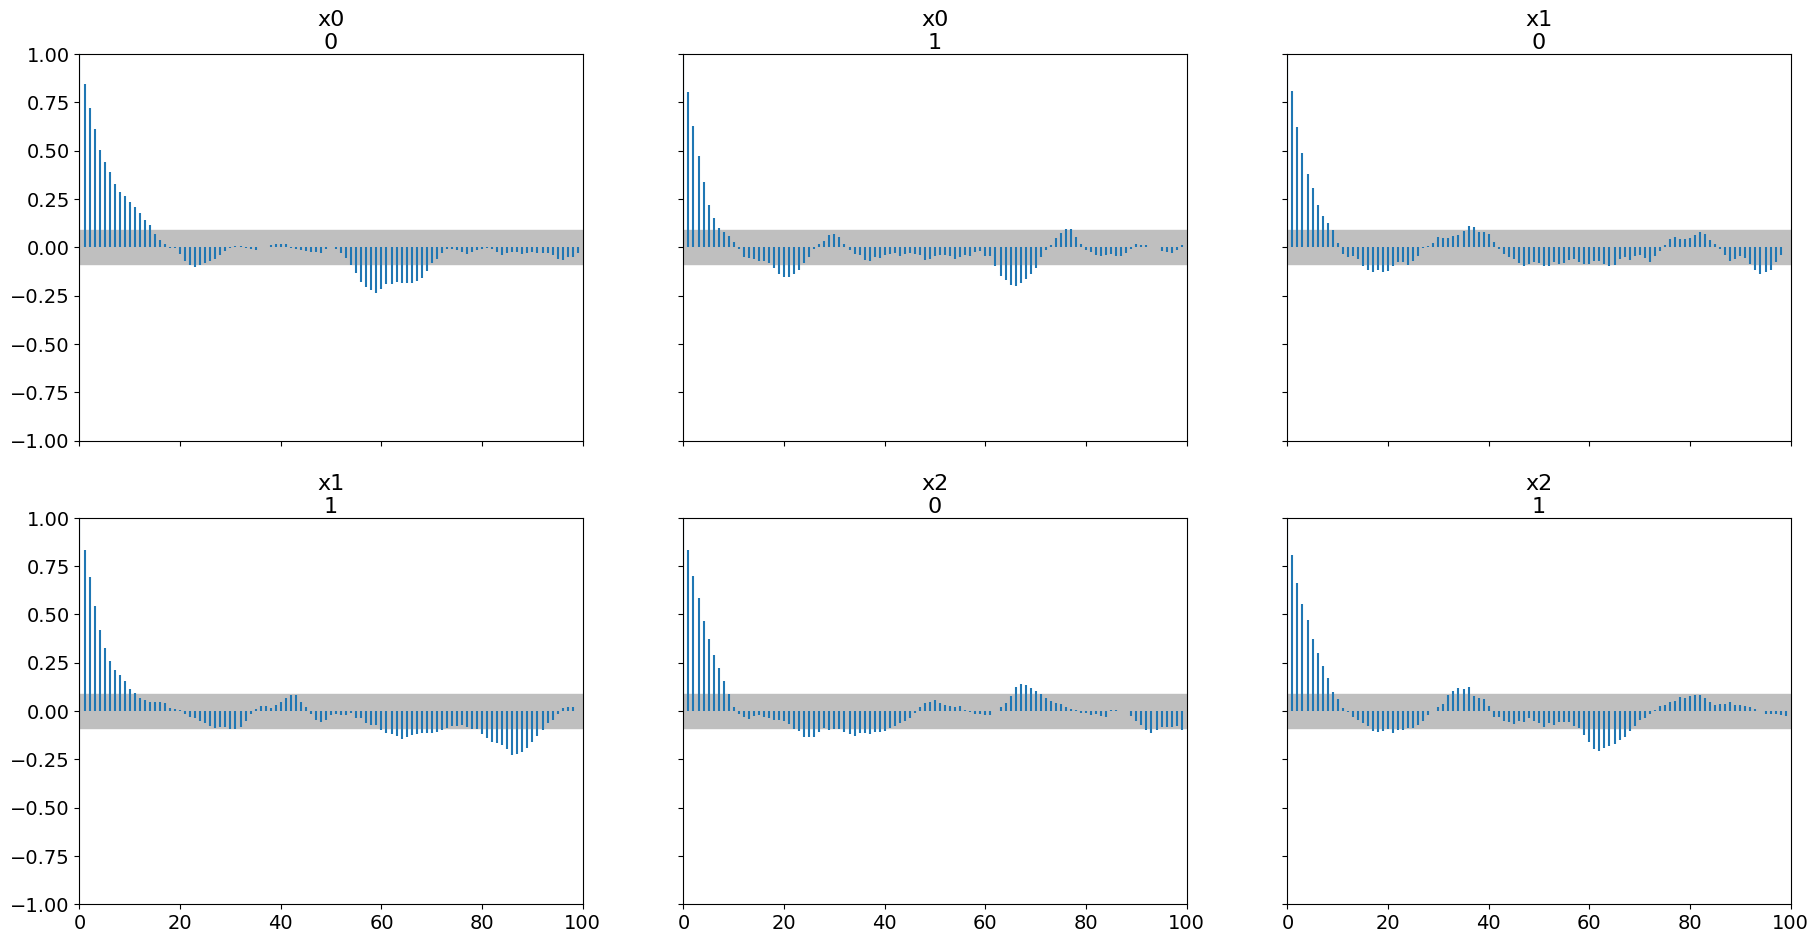

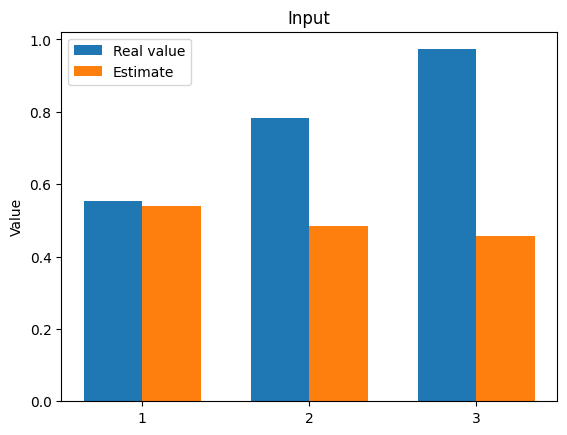

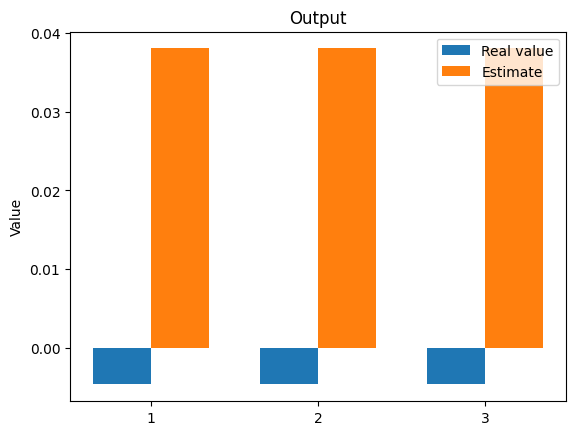

The function inverse took 189.82006525993347 seconds.


In [73]:
estimate_MF=model_list[-1].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")


real values are [[0.55310878 0.78299984 0.97284695]]
Sampling chain 1/2


Running chain, α = 0.50: 100%|██████████| 1000/1000 [01:38<00:00, 10.12it/s]


Sampling chain 2/2


Running chain, α = 0.45: 100%|██████████| 1000/1000 [01:50<00:00,  9.04it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.597 0.662 0.426]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.597  0.690  -0.670    1.796      0.079    0.056      76.0     132.0   
x1  0.662  0.651  -0.646    1.801      0.068    0.048      96.0     129.0   
x2  0.426  0.638  -0.707    1.666      0.065    0.048      97.0     173.0   

    r_hat  
x0   1.02  
x1   1.02  
x2   1.03  
Autocorrelation...
[[0.04389122 0.12099984 0.54684695]]


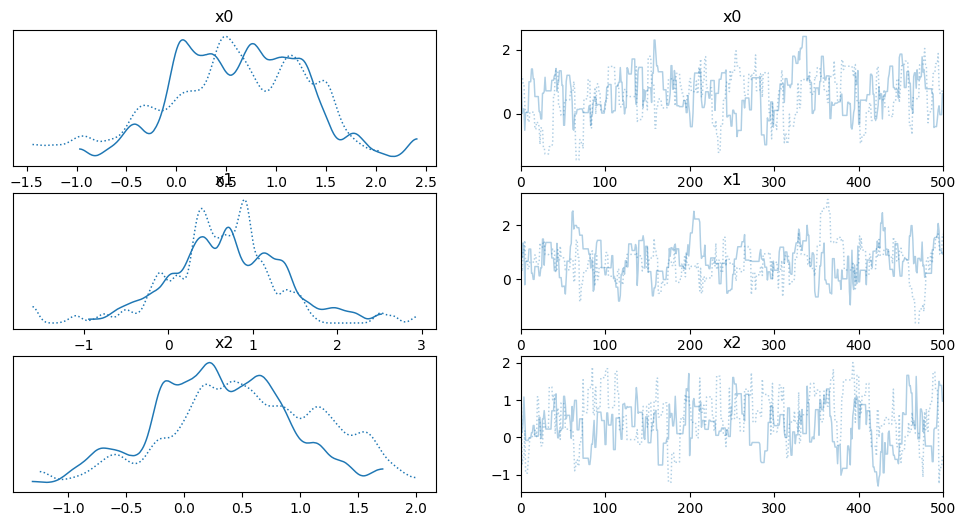

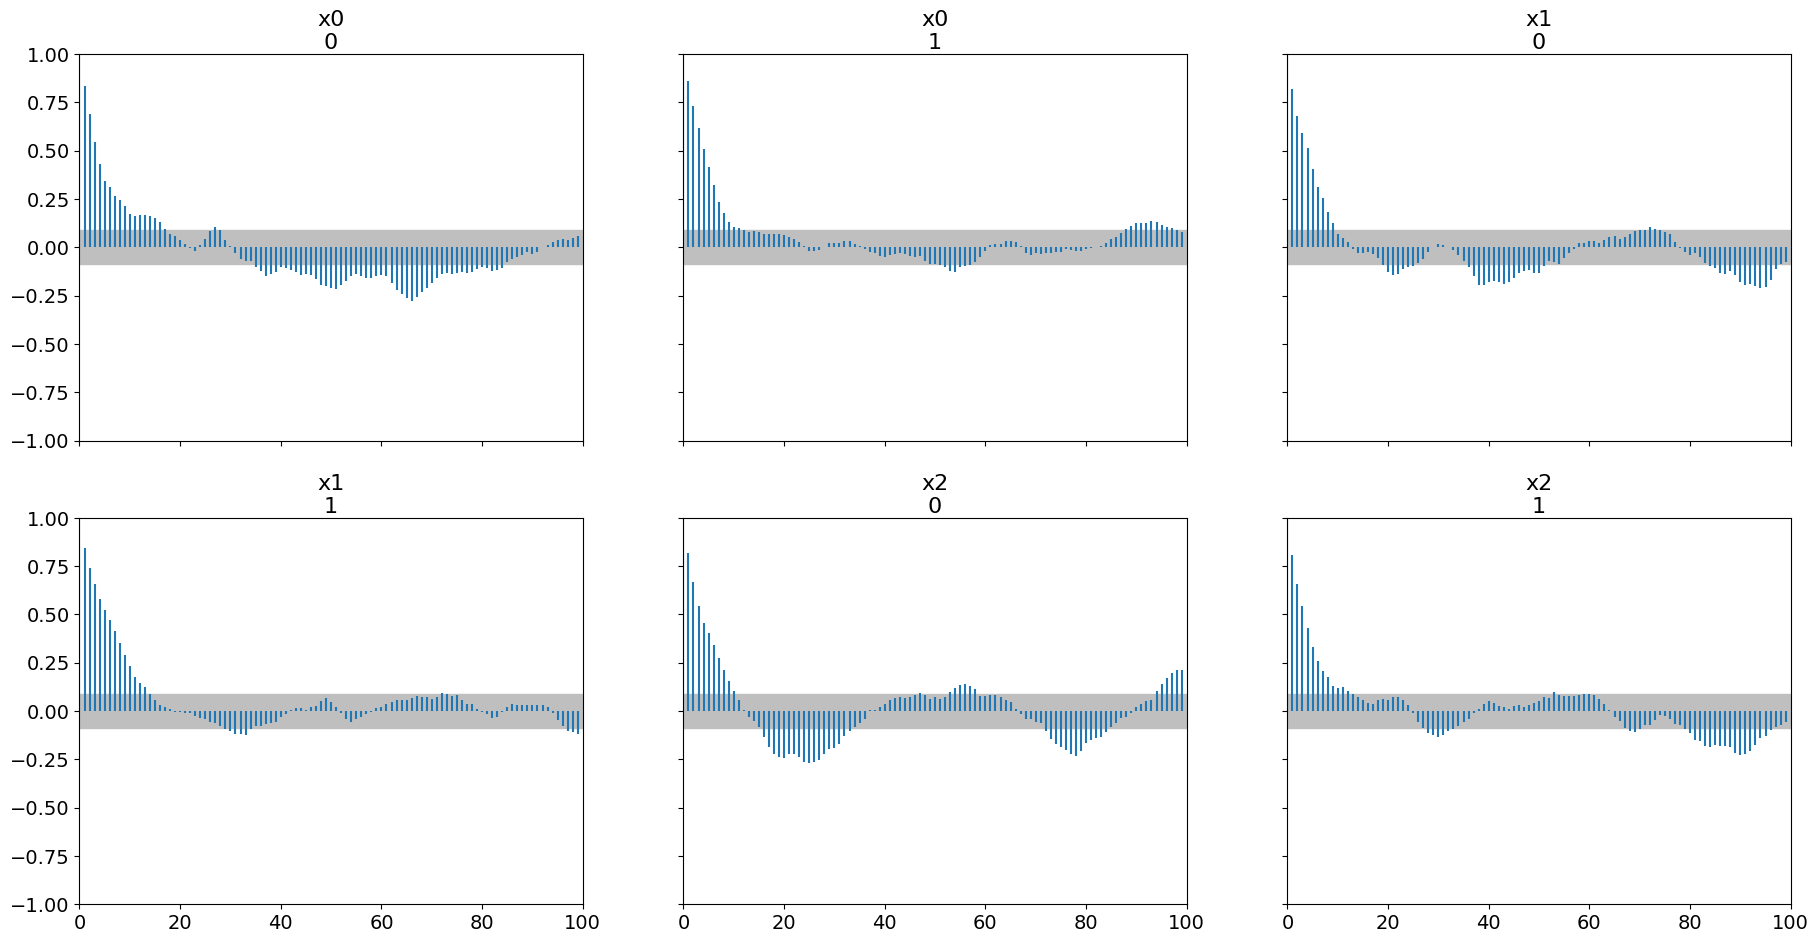

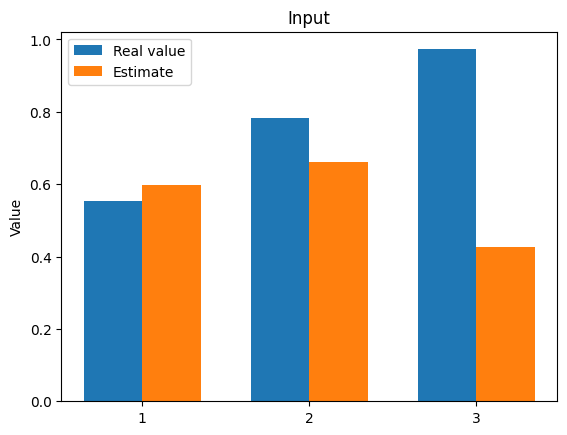

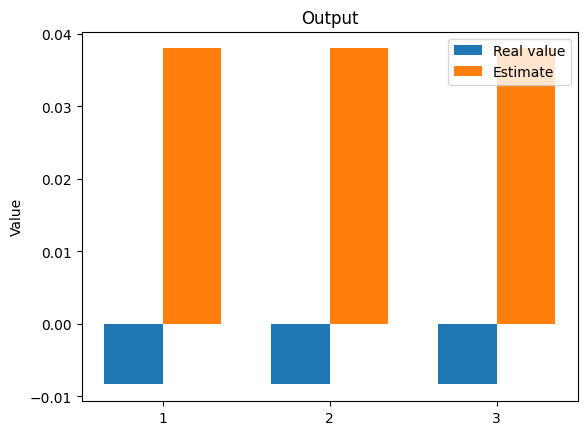

The function inverse took 233.30767369270325 seconds.


In [75]:
mean_prior=np.ones(3)*0.5
cov_prior=np.eye(3)*0.5
sigma=1
sigma_noise=0.005
rwmh_cov = np.eye(real_x.shape[1]) # !
rmwh_scaling = 0.001
rwmh_adaptive = False
iterations =1000
burnin = 500
n_chains=2

closest_indices=np.argmin(np.sum(np.abs(mu_test - real_x),axis=1))
nearest_x=mu_test[closest_indices]
nearest_U=U_hf_test[closest_indices]
estimate_MF=model_list[-1].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")


real values are [[0.55310878 0.78299984 0.97284695]]
Sampling chain 1/2


Running chain, α = 0.47: 100%|██████████| 1000/1000 [01:55<00:00,  8.64it/s]


Sampling chain 2/2


Running chain, α = 0.40: 100%|██████████| 1000/1000 [02:03<00:00,  8.12it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.528 0.631 0.633]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.528  0.885  -1.095    2.015      0.090    0.064      99.0     128.0   
x1  0.631  0.813  -0.690    2.166      0.095    0.068      74.0     171.0   
x2  0.633  0.857  -0.939    2.188      0.083    0.060     108.0     107.0   

    r_hat  
x0   1.02  
x1   1.01  
x2   1.02  
Autocorrelation...
[[0.02510878 0.15199984 0.33984695]]


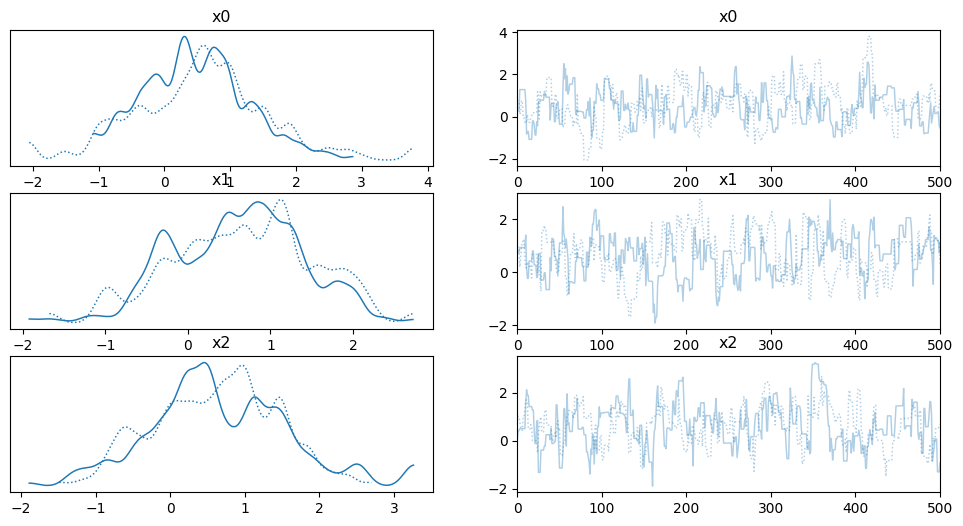

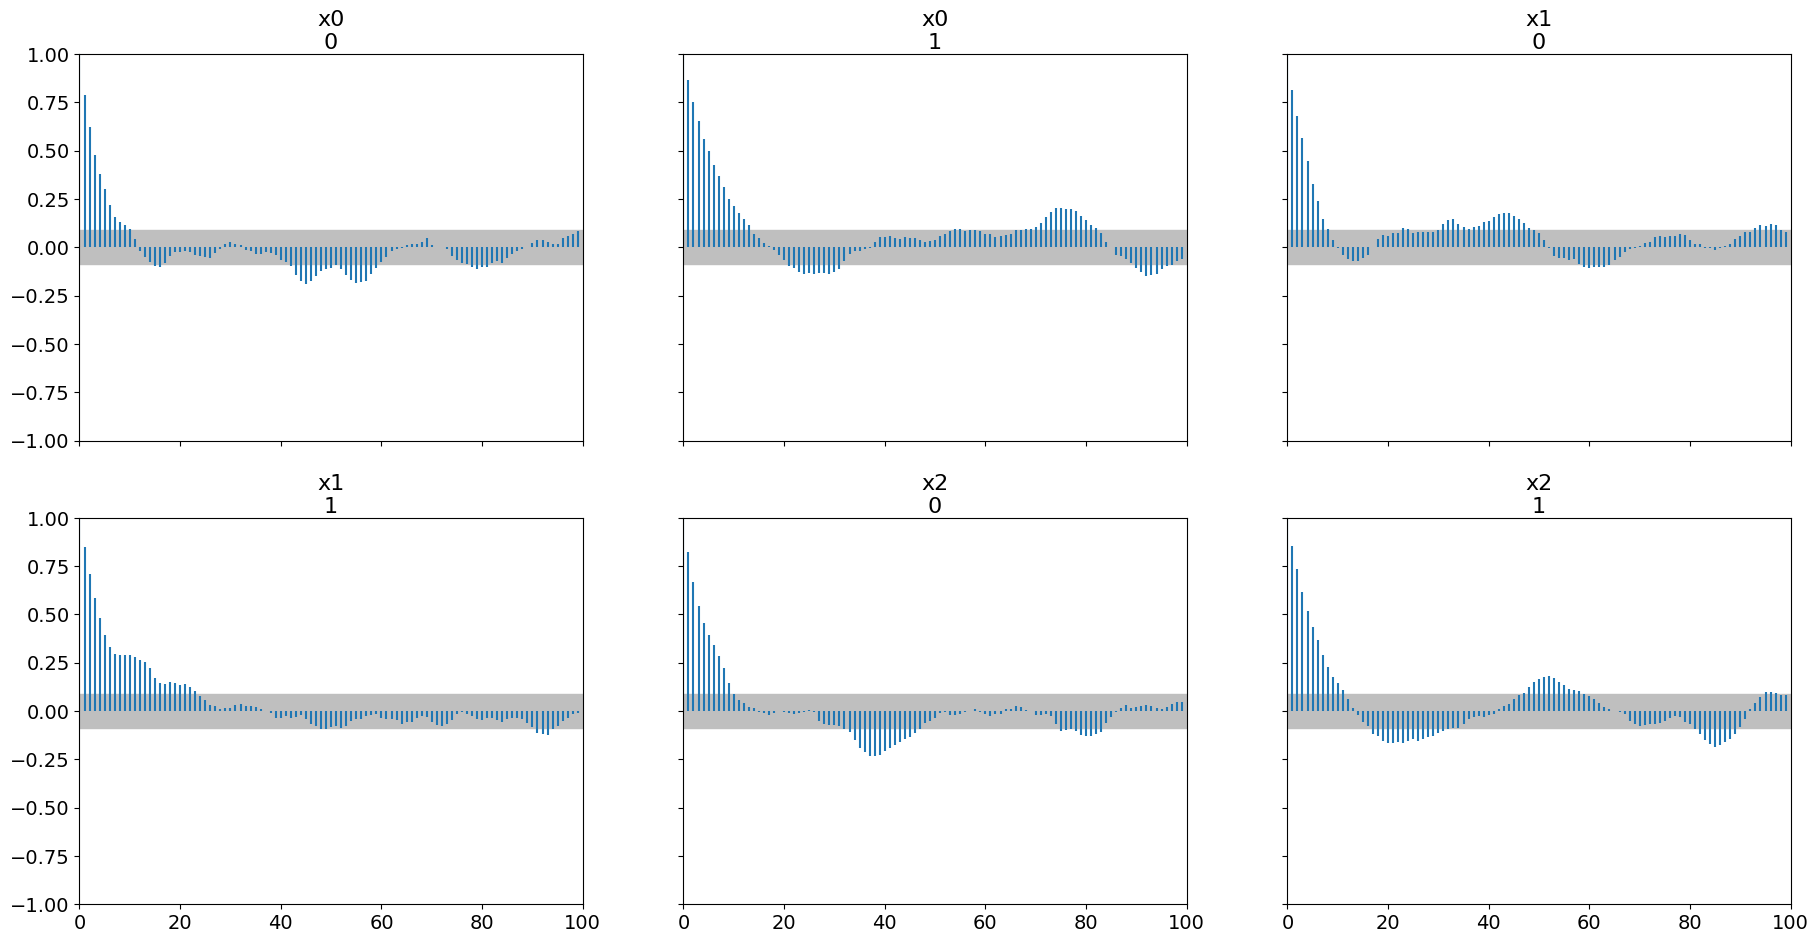

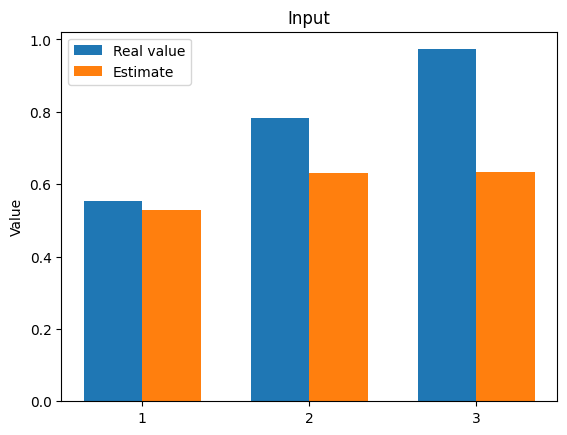

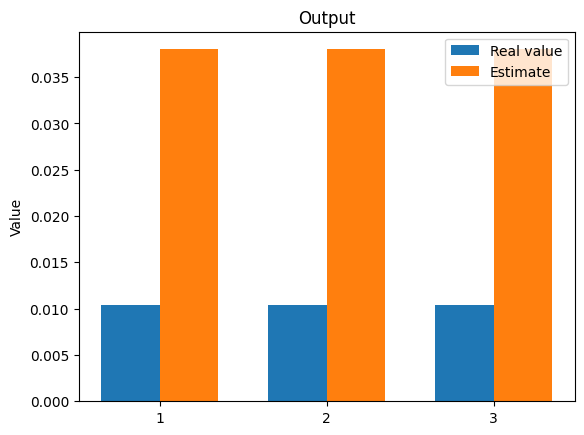

The function inverse took 272.2568368911743 seconds.


In [76]:
mean_prior=np.ones(3)*0.5
cov_prior=np.eye(3)*0.75
sigma=1
sigma_noise=0.005
rwmh_cov = np.eye(real_x.shape[1]) # !
rmwh_scaling = 0.001
rwmh_adaptive = False
iterations =1000
burnin = 500
n_chains=2

closest_indices=np.argmin(np.sum(np.abs(mu_test - real_x),axis=1))
nearest_x=mu_test[closest_indices]
nearest_U=U_hf_test[closest_indices]
estimate_MF=model_list[-1].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")


real values are [[0.55310878 0.78299984 0.97284695]]
Sampling chain 1/5


Running chain, α = 0.51: 100%|██████████| 2000/2000 [02:54<00:00, 11.48it/s]


Sampling chain 2/5


Running chain, α = 0.45: 100%|██████████| 2000/2000 [03:01<00:00, 11.01it/s]


Sampling chain 3/5


...

Sampling chain 4/5


Running chain, α = 0.50: 100%|██████████| 2000/2000 [03:04<00:00, 10.85it/s]


Sampling chain 5/5


Running chain, α = 0.46: 100%|██████████| 2000/2000 [03:06<00:00, 10.73it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.538 0.484 0.488]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.538  0.816  -0.901    2.036      0.037    0.026     479.0     689.0   
x1  0.484  0.859  -1.156    2.037      0.043    0.030     410.0     541.0   
x2  0.488  0.844  -1.032    2.089      0.046    0.033     335.0     669.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
Autocorrelation...
[[0.01510878 0.29899984 0.48484695]]


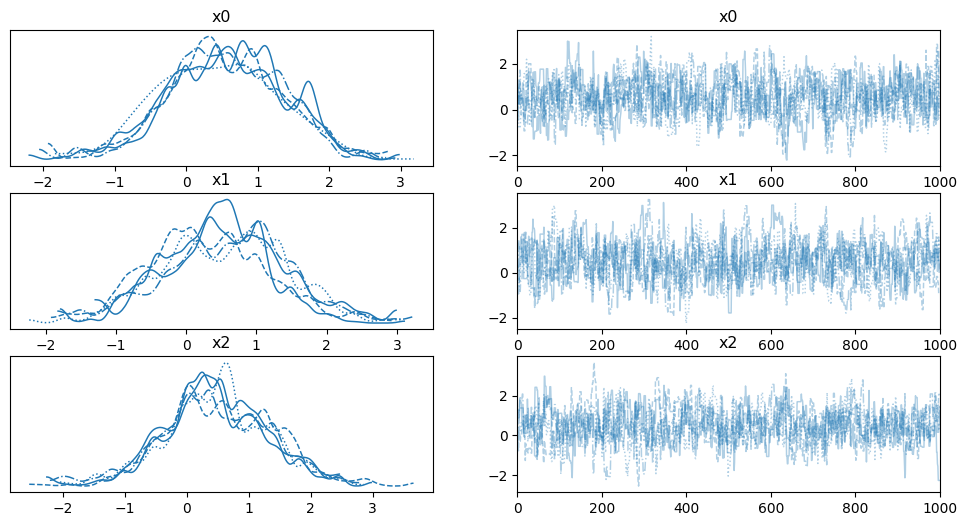

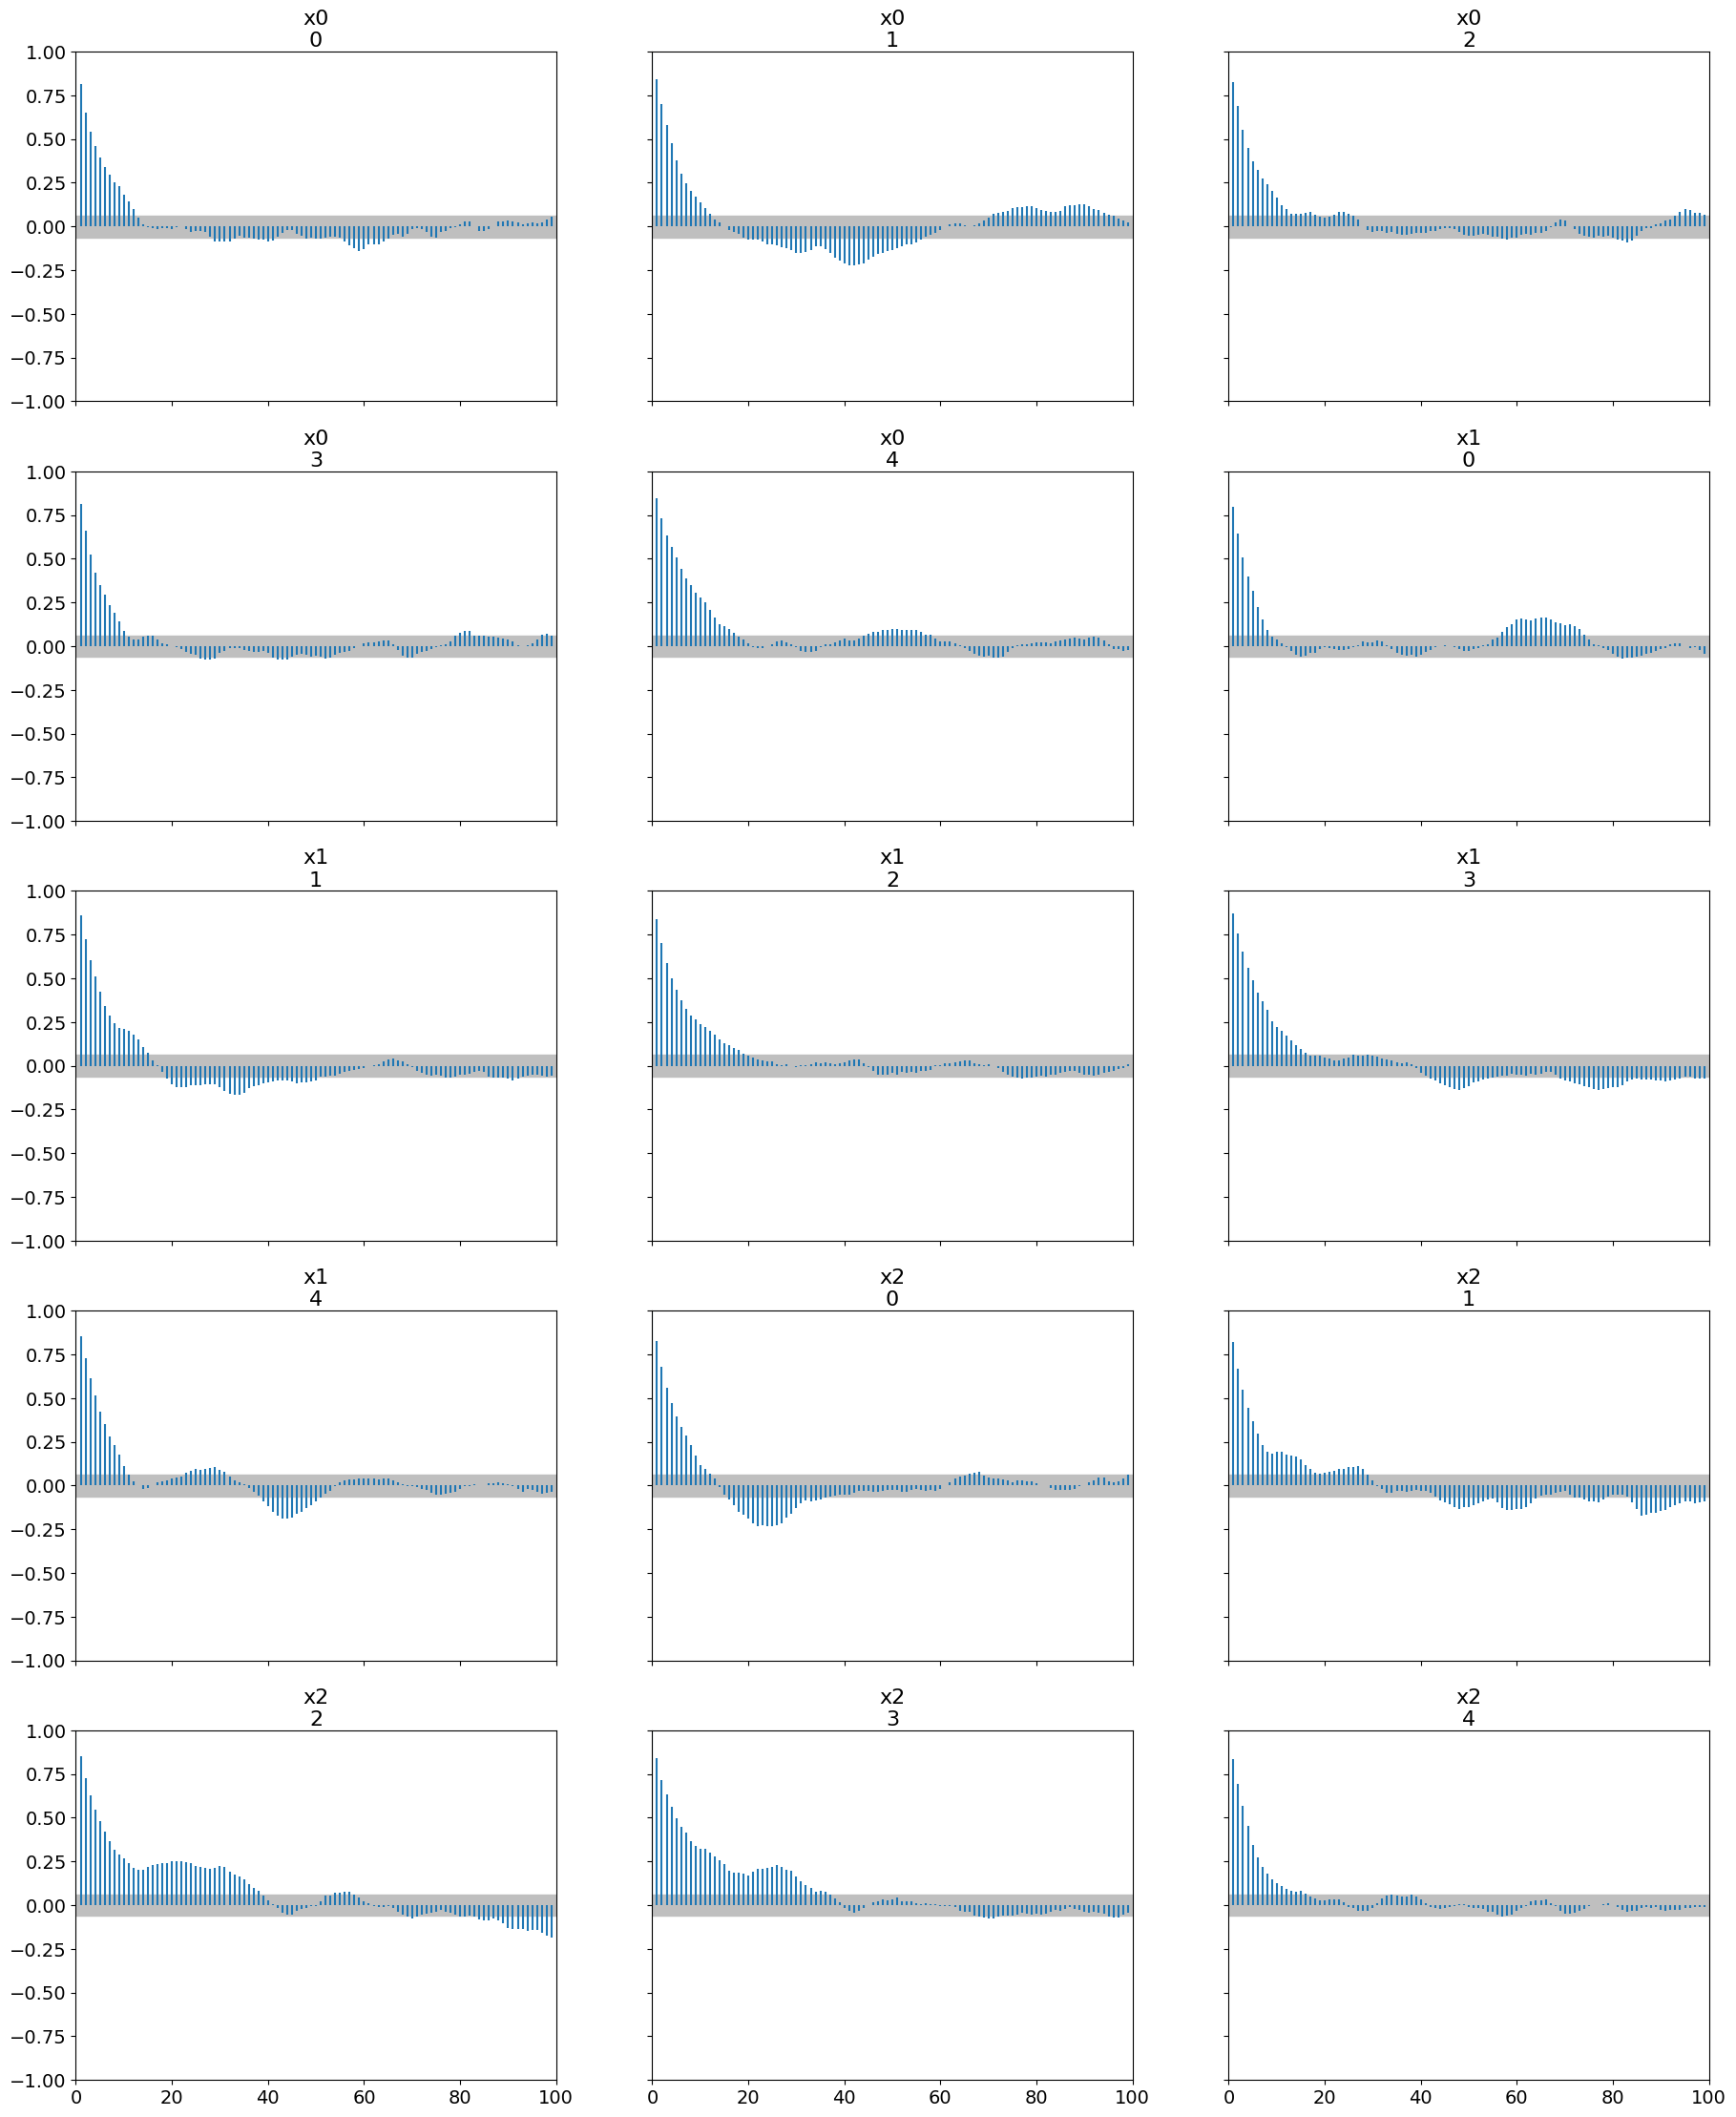

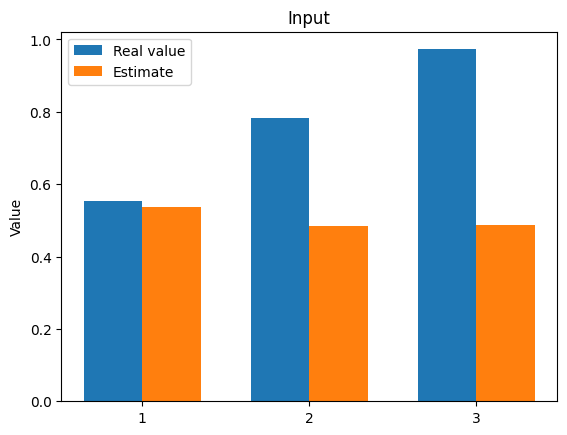

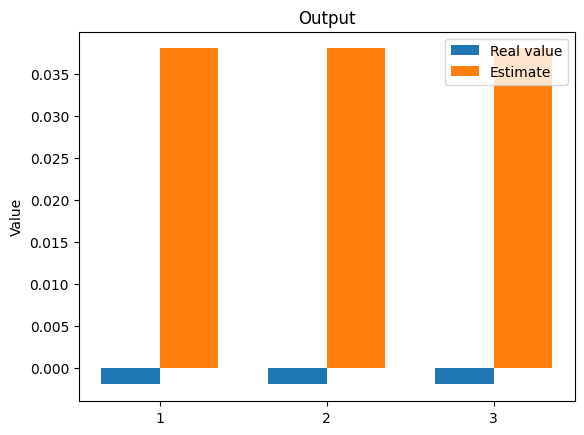

The function inverse took 917.4185824394226 seconds.


In [79]:
mean_prior=np.ones(3)*0.5
cov_prior=np.eye(3)*0.75
sigma=1
sigma_noise=0.005
rwmh_cov = np.eye(real_x.shape[1]) # !
rmwh_scaling = 0.001
rwmh_adaptive = False
iterations =2000
burnin = 1000
n_chains=5

closest_indices=np.argmin(np.sum(np.abs(mu_test - real_x),axis=1))
nearest_x=mu_test[closest_indices]
nearest_U=U_hf_test[closest_indices]
estimate_MF=model_list[-1].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")


real values are [[0.22025001 0.10636052 0.74751992]]
Sampling chain 1/4


Running chain, α = 0.59: 100%|██████████| 2000/2000 [03:08<00:00, 10.60it/s]


Sampling chain 2/4


Running chain, α = 0.49: 100%|██████████| 2000/2000 [03:08<00:00, 10.60it/s]


Sampling chain 3/4


Running chain, α = 0.49: 100%|██████████| 2000/2000 [03:08<00:00, 10.60it/s]


Sampling chain 4/4


Running chain, α = 0.51: 100%|██████████| 2000/2000 [03:08<00:00, 10.62it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.489 0.496 0.489]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.489  0.225   0.074    0.893      0.013    0.009     319.0     454.0   
x1  0.496  0.225   0.092    0.932      0.021    0.015     121.0     281.0   
x2  0.489  0.215   0.093    0.881      0.013    0.009     258.0     505.0   

    r_hat  
x0   1.02  
x1   1.02  
x2   1.01  
Autocorrelation...
[[0.26874999 0.38963948 0.25851992]]


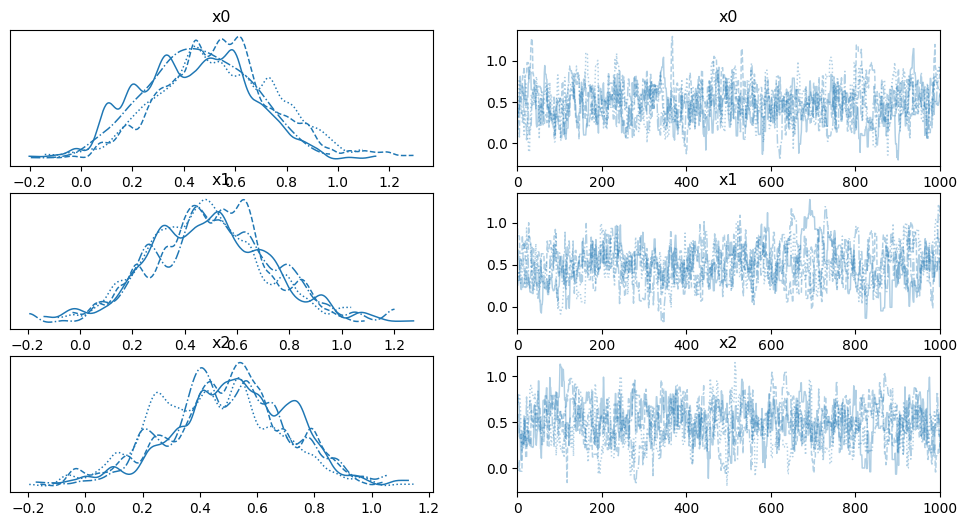

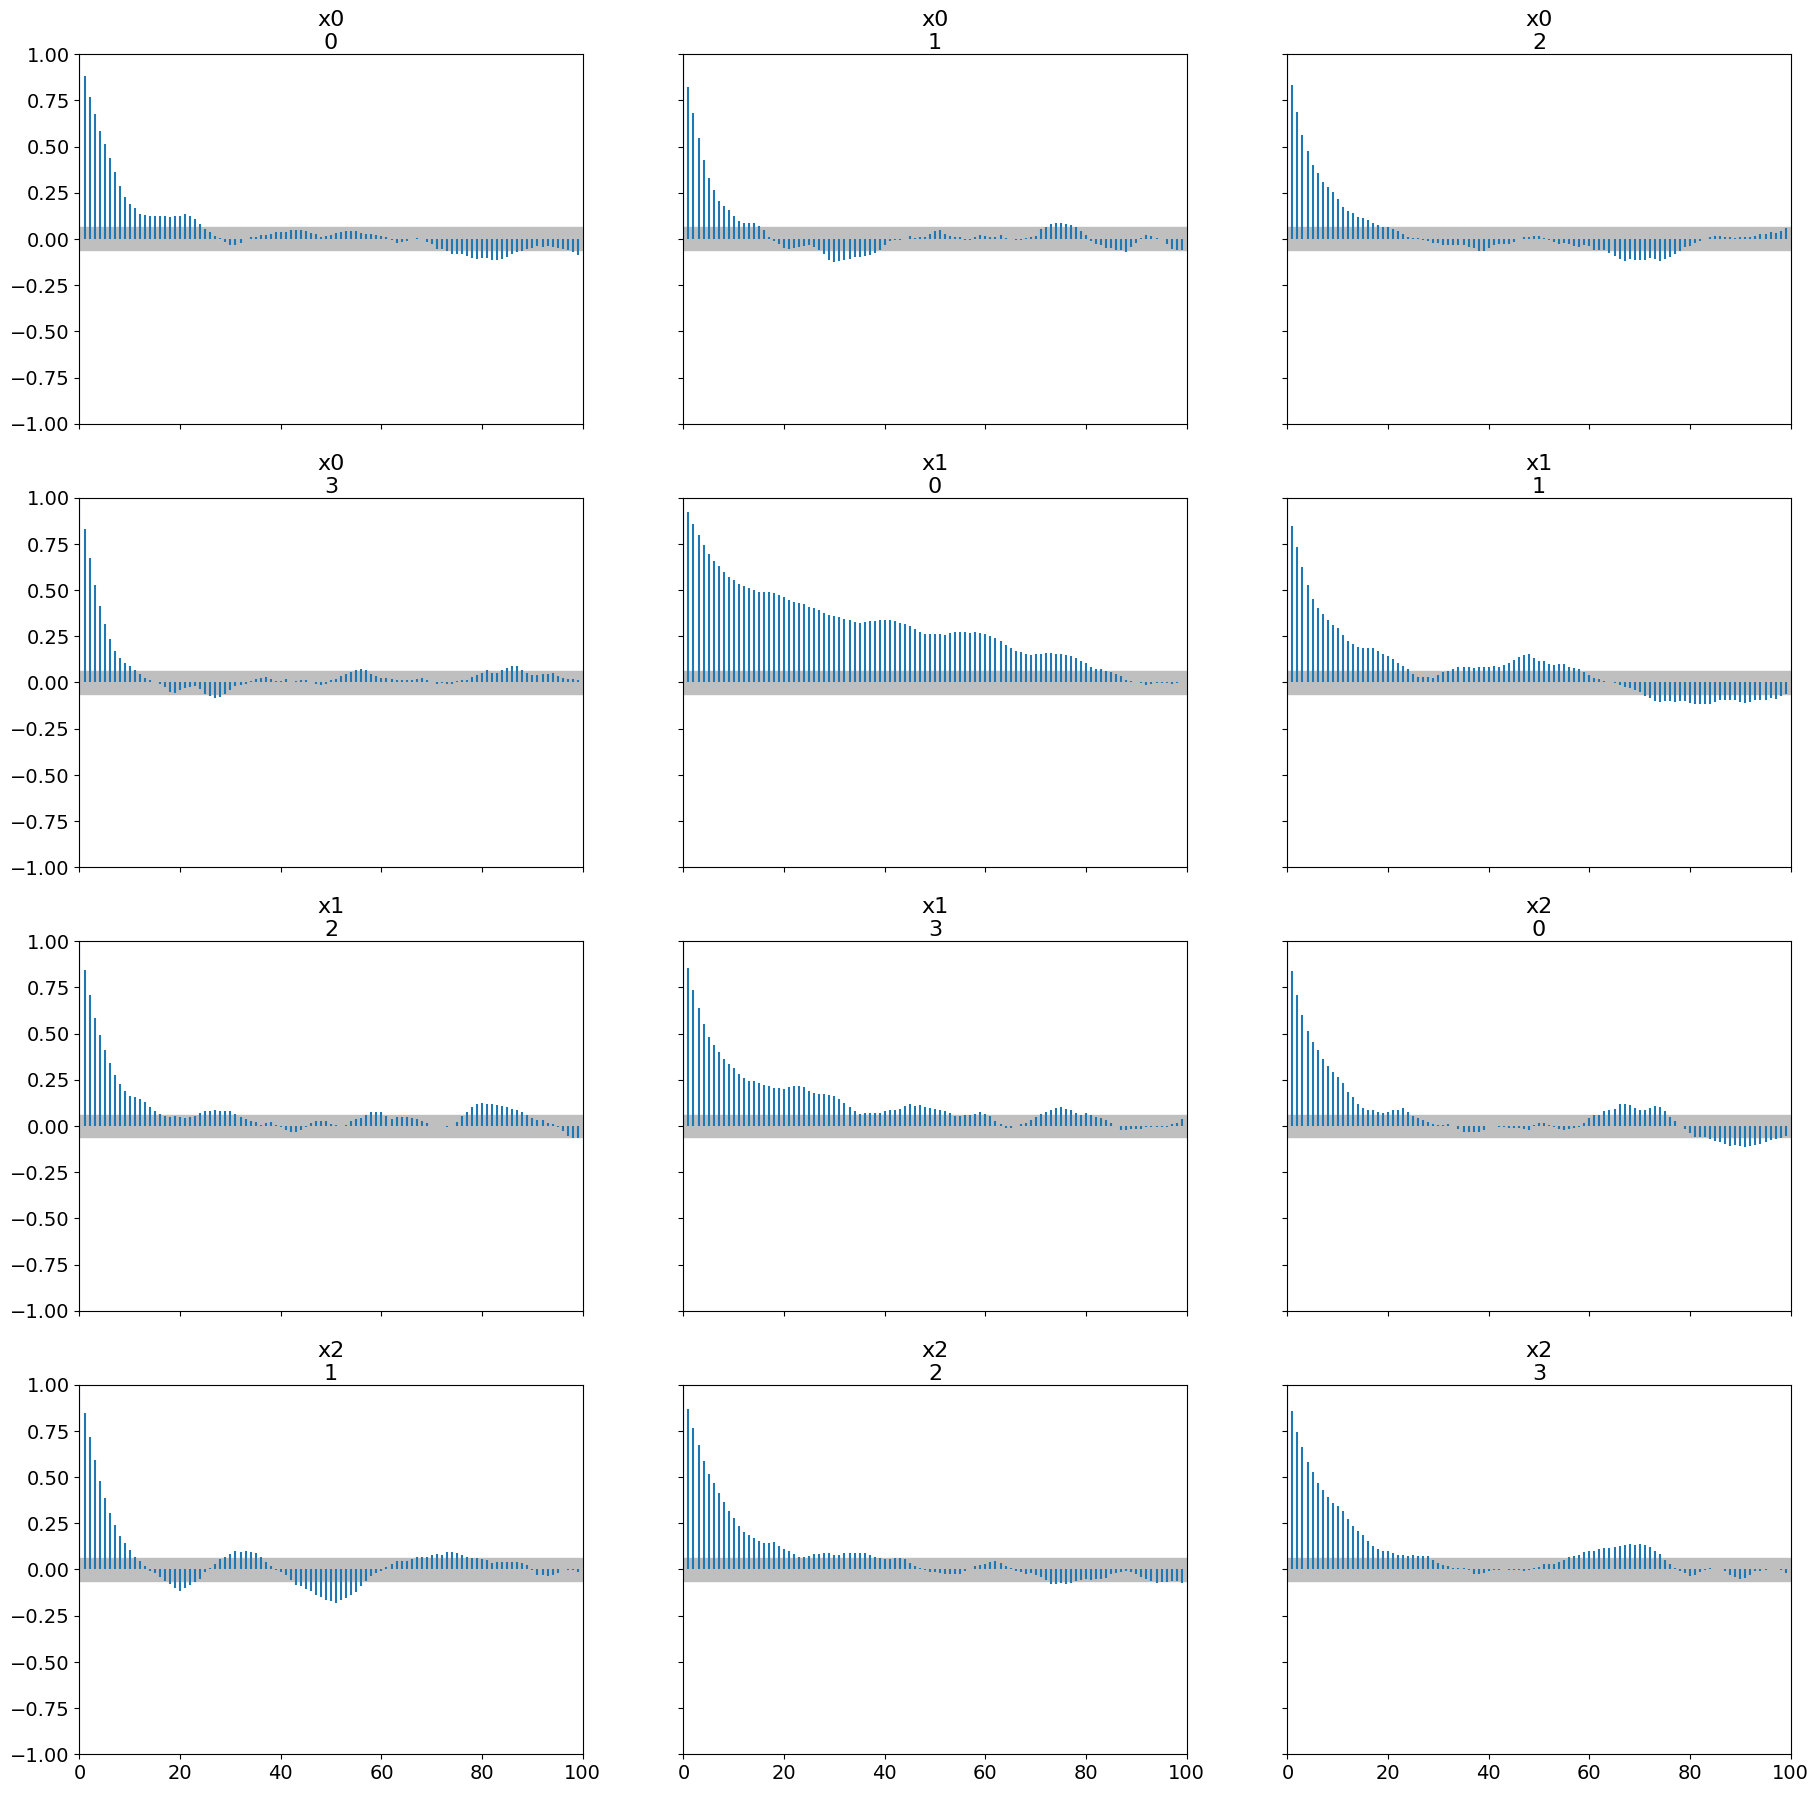

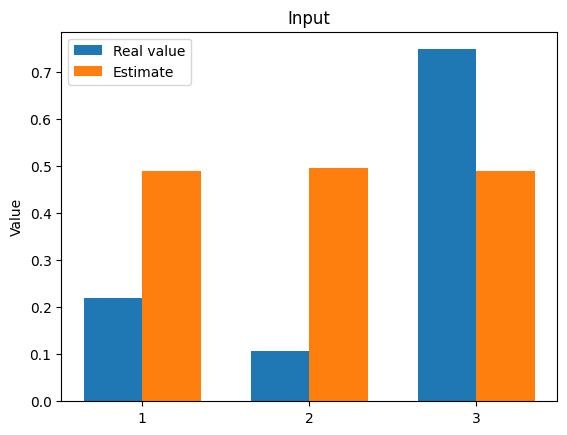

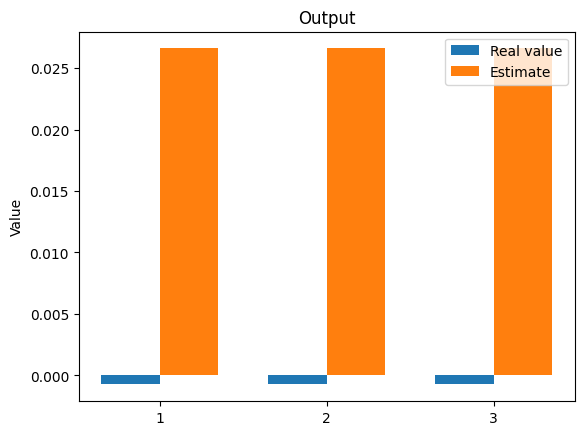

The function inverse took 781.3399353027344 seconds.


In [ ]:
estimate_MF2=model_list[-1].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")


********************  # Nb. basis = 1  ********************
real values are [[0.73861976 0.43766412 0.1882289 ]]
Sampling chain 1/4


Running chain, α = 0.85: 100%|██████████| 4000/4000 [06:04<00:00, 10.96it/s]


Sampling chain 2/4


Running chain, α = 0.86: 100%|██████████| 4000/4000 [07:50<00:00,  8.50it/s]


Sampling chain 3/4


Running chain, α = 0.90: 100%|██████████| 4000/4000 [11:47<00:00,  5.65it/s]


Sampling chain 4/4


Running chain, α = 0.94: 100%|██████████| 4000/4000 [11:37<00:00,  5.73it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.507 0.513 0.519]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.507  0.211   0.123    0.912      0.034    0.024      38.0      76.0   
x1  0.513  0.228   0.093    0.948      0.041    0.029      31.0     170.0   
x2  0.519  0.231   0.089    0.964      0.023    0.017     101.0     168.0   

    r_hat  
x0   1.09  
x1   1.13  
x2   1.03  
Autocorrelation...
[[0.23161976 0.07533588 0.3307711 ]]


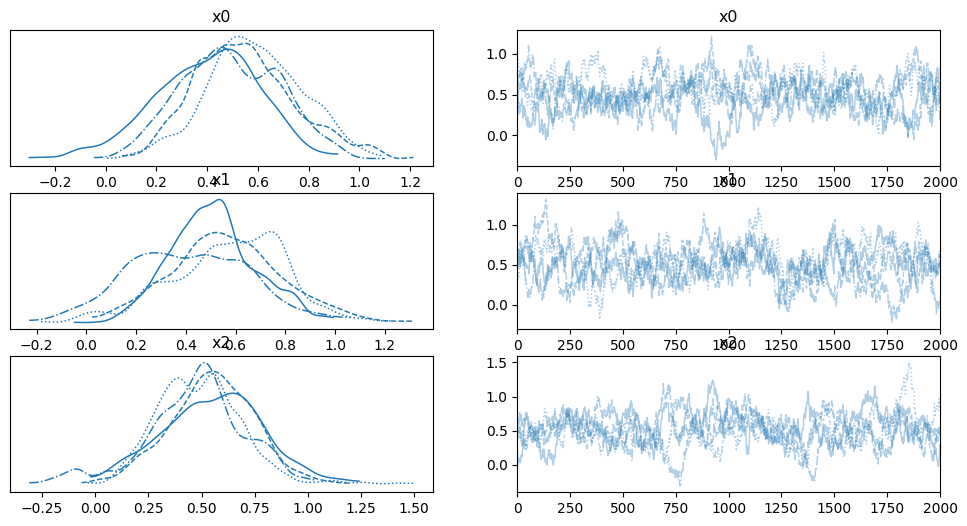

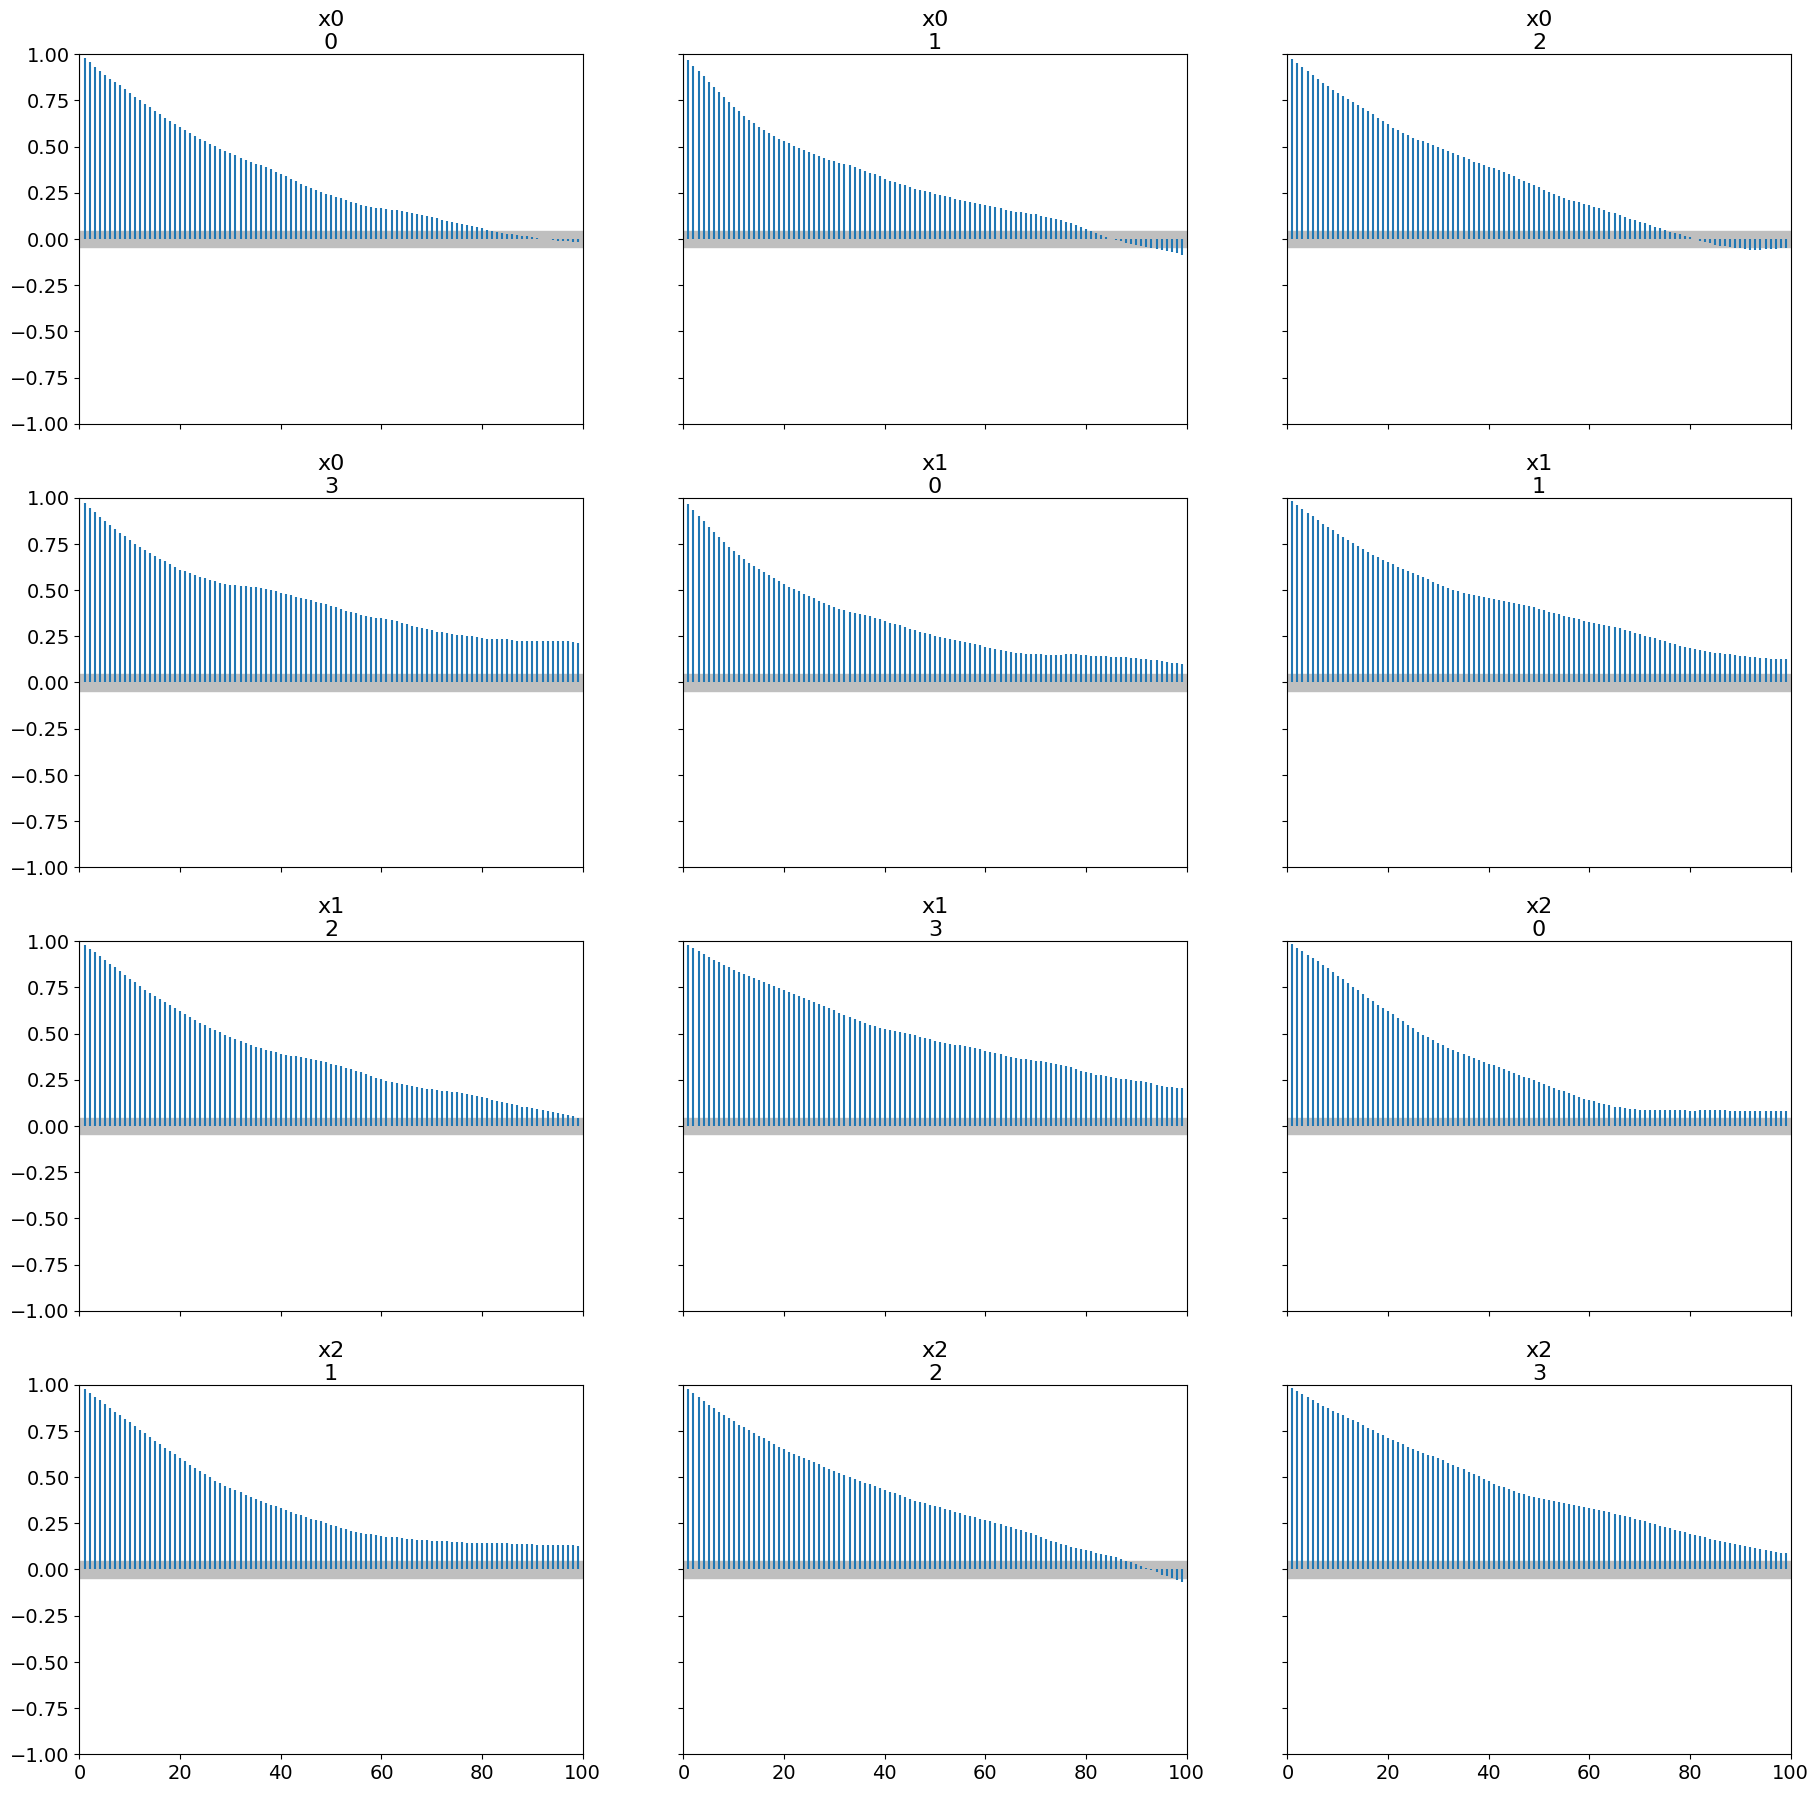

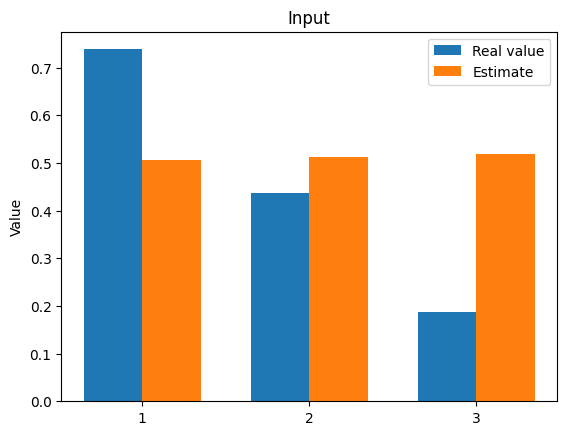

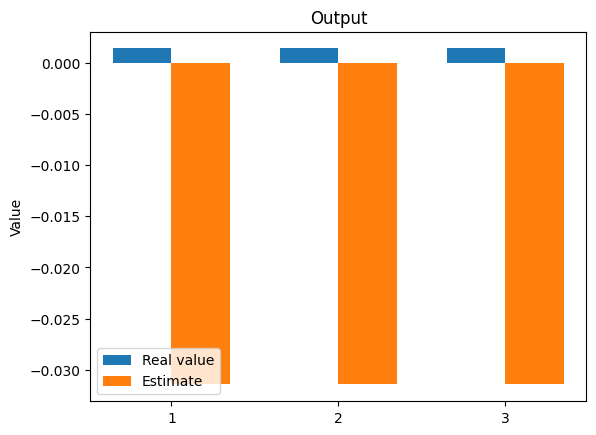

The function inverse took 2265.3156719207764 seconds.
********************  # Nb. basis = 2  ********************
real values are [[0.73861976 0.43766412 0.1882289 ]]
Sampling chain 1/4


Running chain, α = 0.83: 100%|██████████| 4000/4000 [11:28<00:00,  5.81it/s]


Sampling chain 2/4


Running chain, α = 0.82: 100%|██████████| 4000/4000 [11:28<00:00,  5.81it/s]


Sampling chain 3/4


Running chain, α = 0.88: 100%|██████████| 4000/4000 [11:28<00:00,  5.81it/s]


Sampling chain 4/4


Running chain, α = 0.83: 100%|██████████| 4000/4000 [10:06<00:00,  6.59it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.488 0.508 0.552]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.488  0.226   0.082    0.914      0.029    0.020      62.0     111.0   
x1  0.508  0.228   0.079    0.948      0.035    0.027      44.0     163.0   
x2  0.552  0.202   0.172    0.925      0.021    0.015      91.0     213.0   

    r_hat  
x0   1.04  
x1   1.08  
x2   1.07  
Autocorrelation...
[[0.25061976 0.07033588 0.3637711 ]]


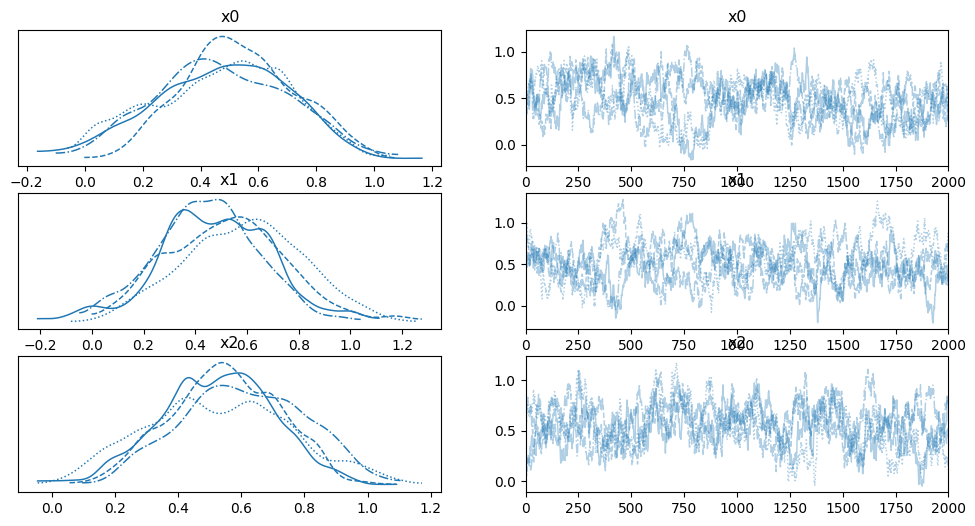

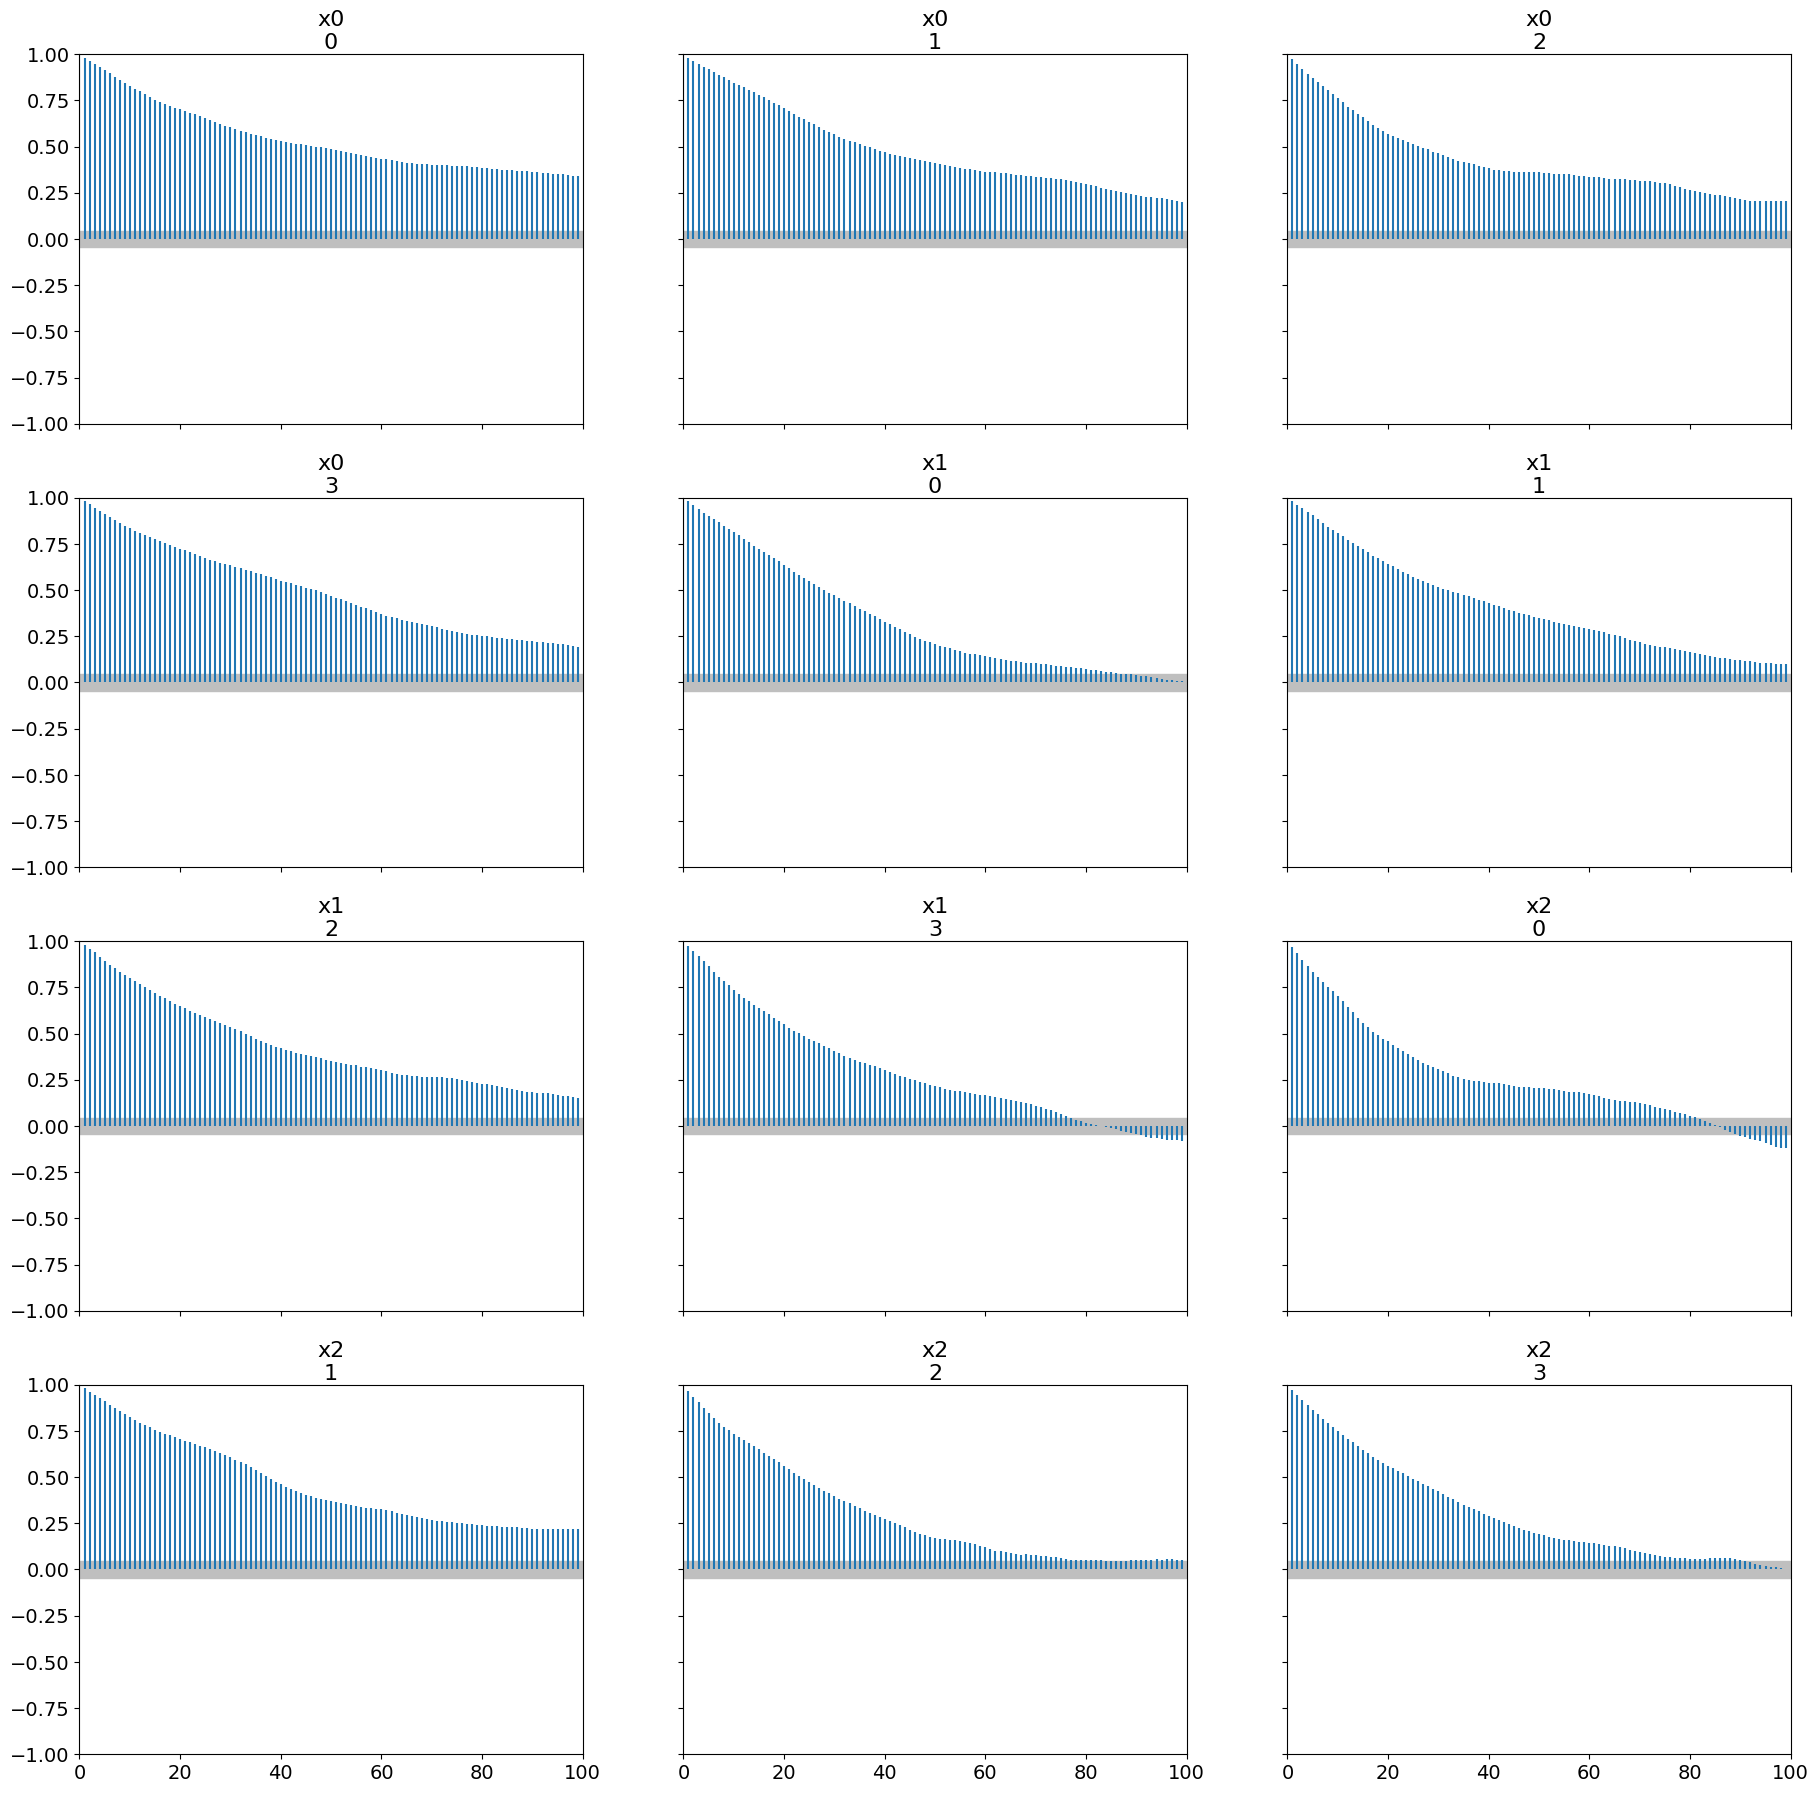

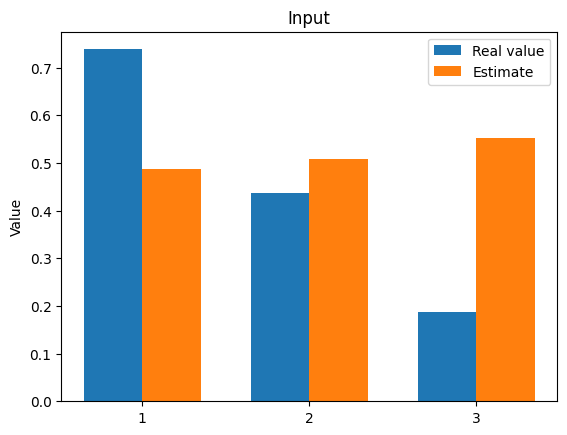

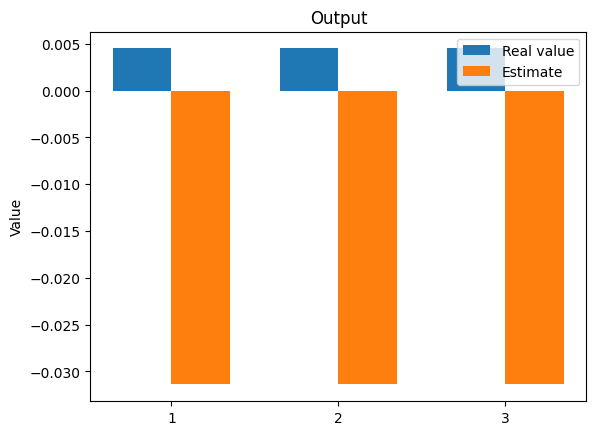

The function inverse took 2717.74631357193 seconds.
********************  # Nb. basis = 3  ********************
real values are [[0.73861976 0.43766412 0.1882289 ]]
Sampling chain 1/4


Running chain, α = 0.84:  91%|█████████▏| 3656/4000 [09:21<00:52,  6.51it/s]


KeyboardInterrupt: 

In [14]:

for j in range(len(model_list)):
    print(
        f"********************  # Nb. basis = {j+1}  ********************"
        )
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="MH")


********************  # Nb. basis = 1  ********************
real values are [[0.15373916 0.64911885 0.55741353]]
Sampling chain 1/4


Running chain, α = 0.43: 100%|██████████| 4000/4000 [05:28<00:00, 12.17it/s]


Sampling chain 2/4


Running chain, α = 0.45: 100%|██████████| 4000/4000 [05:28<00:00, 12.16it/s]


Sampling chain 3/4


Running chain, α = 0.41: 100%|██████████| 4000/4000 [05:29<00:00, 12.13it/s]


Sampling chain 4/4


Running chain, α = 0.47: 100%|██████████| 4000/4000 [05:28<00:00, 12.17it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.5   0.517 0.5  ]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.500  0.220   0.108    0.940      0.009    0.007     571.0    1013.0   
x1  0.517  0.226   0.084    0.940      0.009    0.006     641.0     786.0   
x2  0.500  0.228   0.096    0.951      0.009    0.006     690.0     958.0   

    r_hat  
x0   1.00  
x1   1.01  
x2   1.00  
Autocorrelation...
[[0.34626084 0.13211885 0.05741353]]


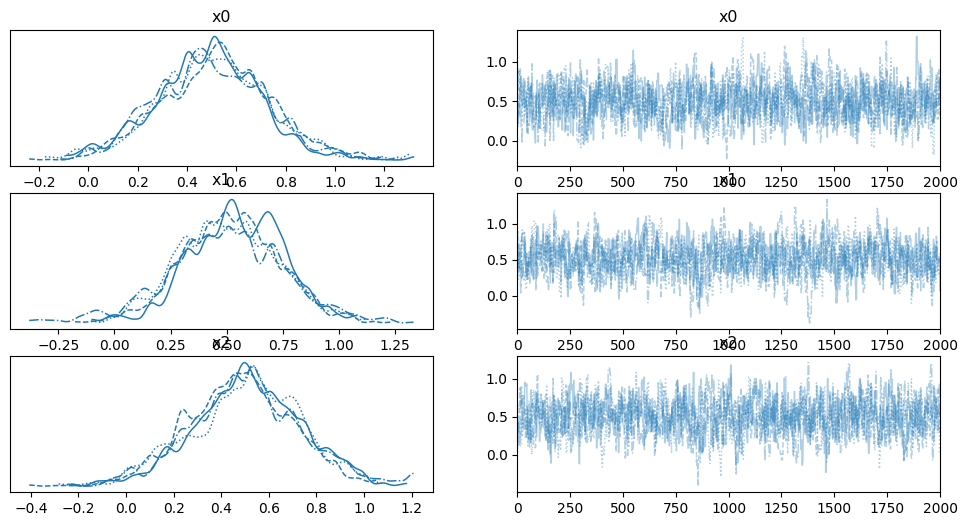

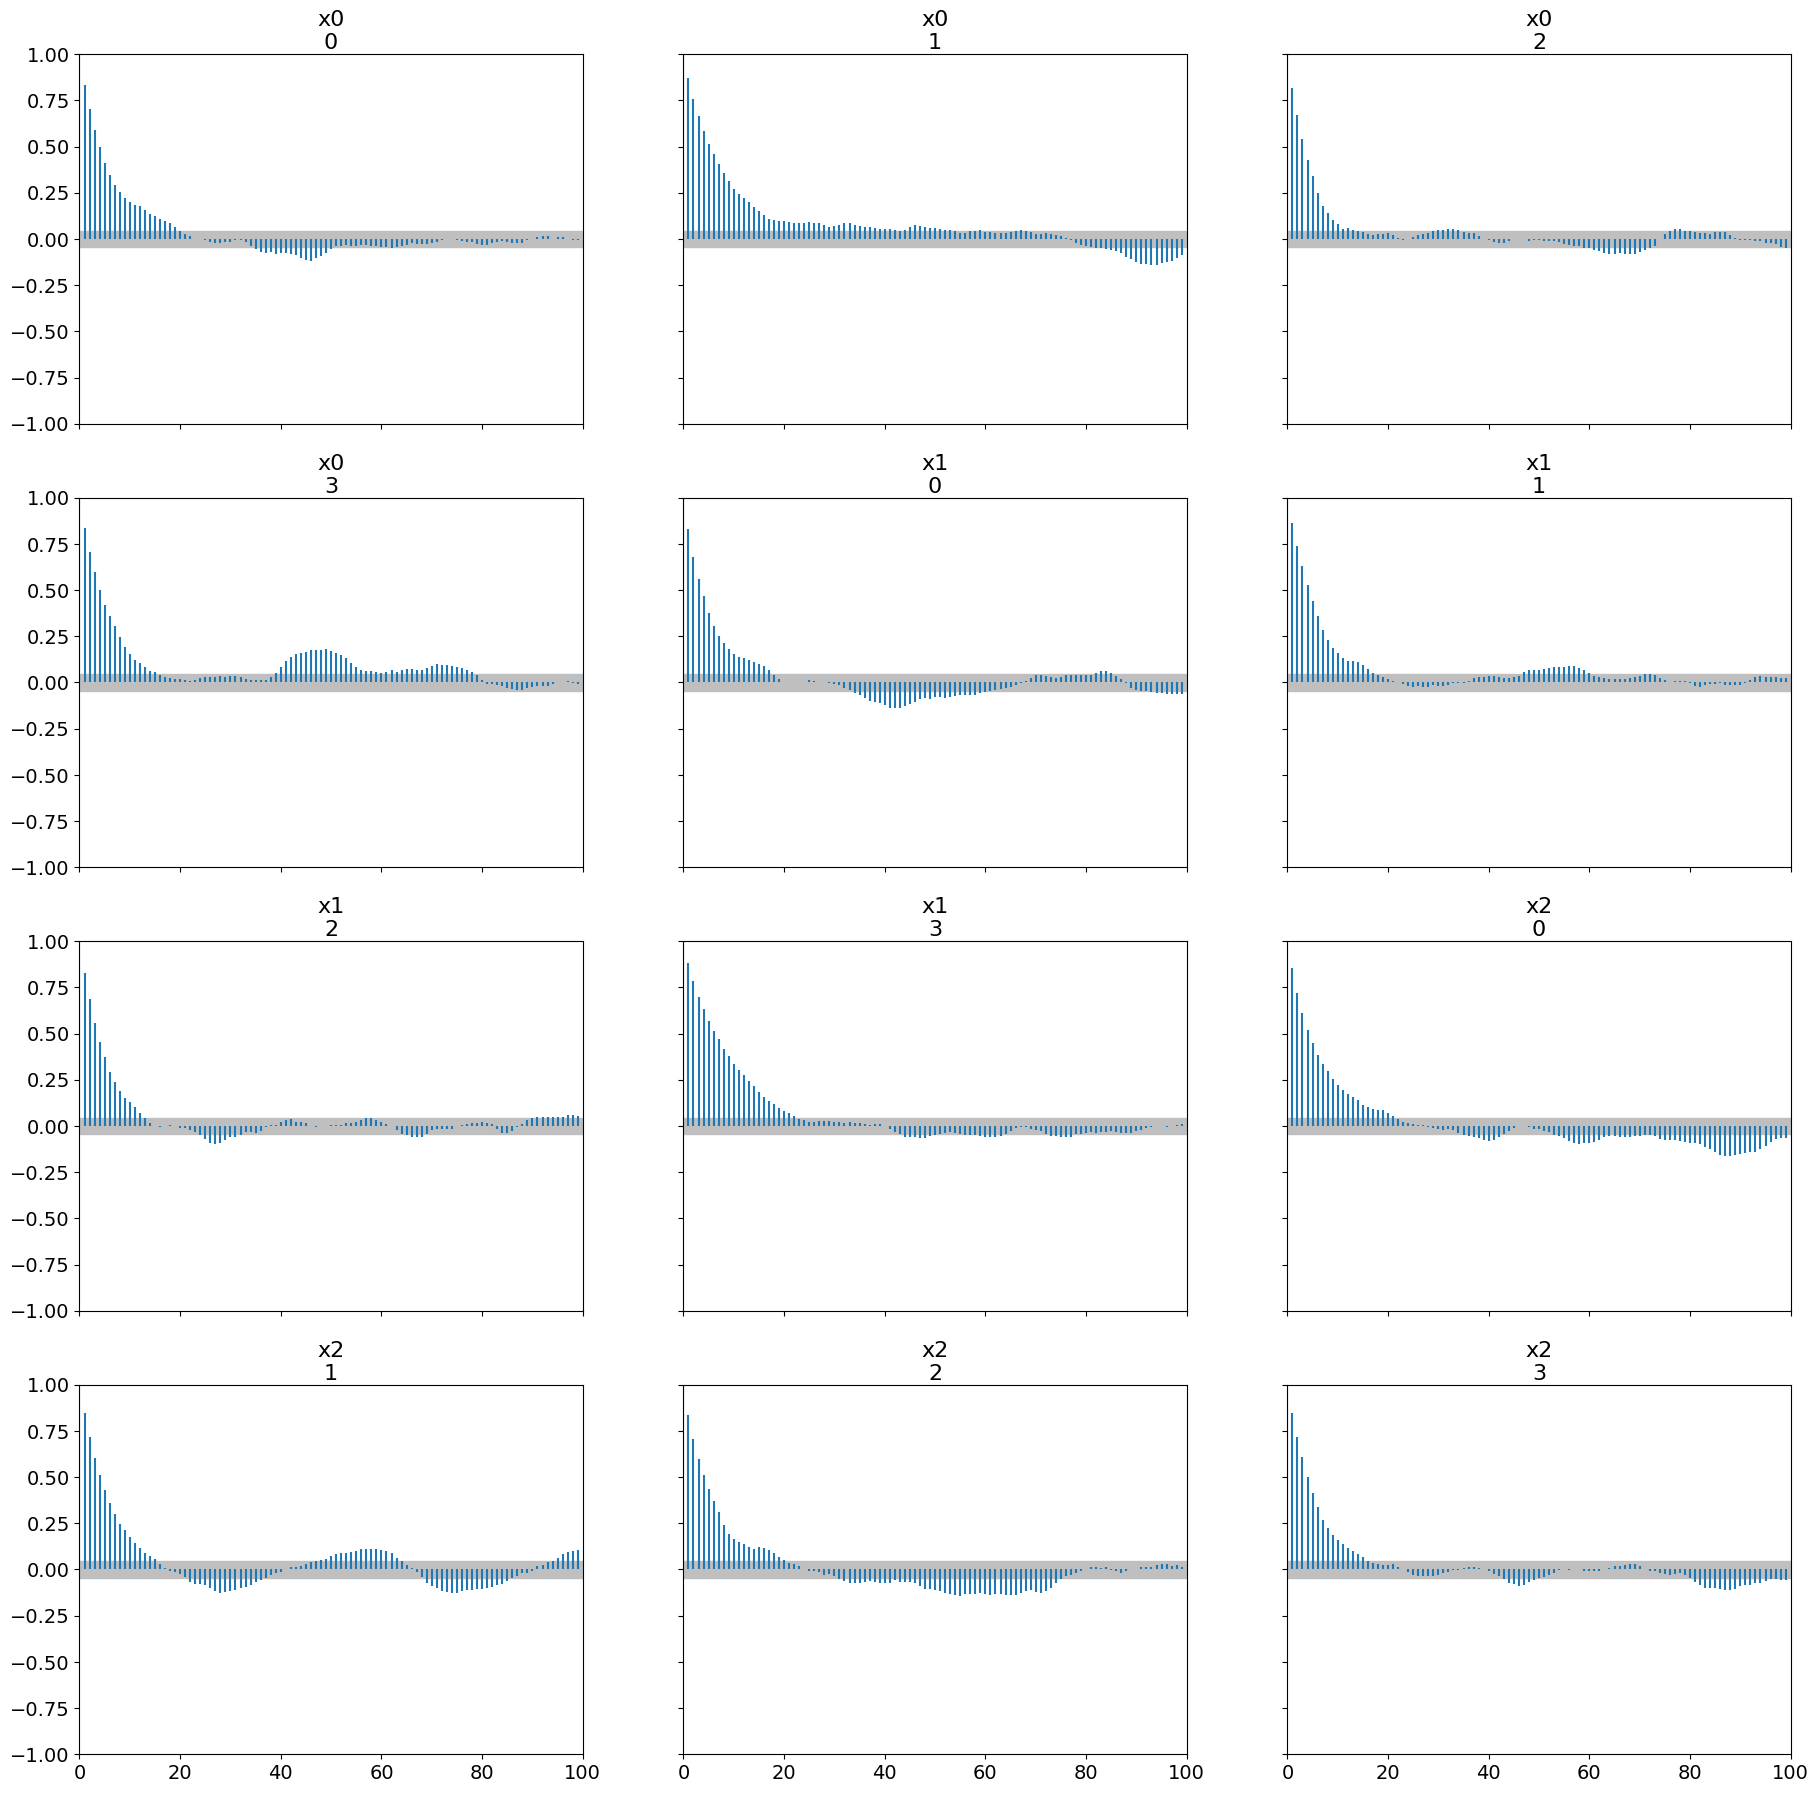

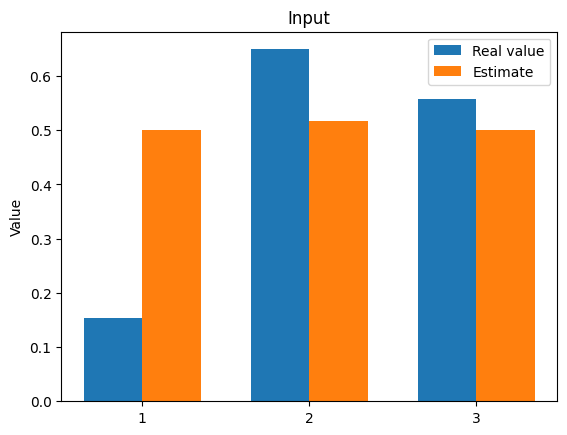

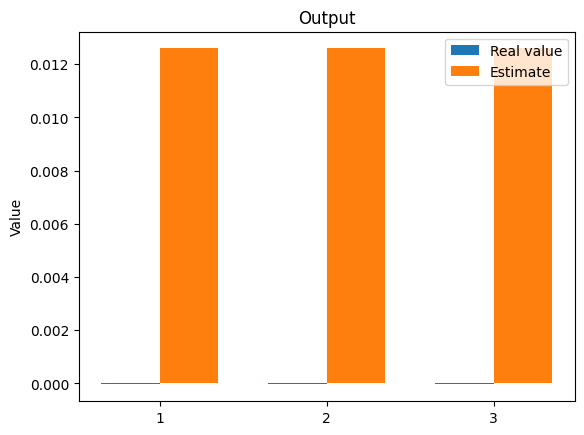

The function inverse took 1340.4931905269623 seconds.
********************  # Nb. basis = 2  ********************
real values are [[0.15373916 0.64911885 0.55741353]]
Sampling chain 1/4


Running chain, α = 0.44: 100%|██████████| 4000/4000 [05:29<00:00, 12.12it/s]


Sampling chain 2/4


Running chain, α = 0.52: 100%|██████████| 4000/4000 [05:29<00:00, 12.13it/s]


Sampling chain 3/4


Running chain, α = 0.45: 100%|██████████| 4000/4000 [05:28<00:00, 12.19it/s]


Sampling chain 4/4


Running chain, α = 0.48: 100%|██████████| 4000/4000 [05:29<00:00, 12.16it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.494 0.497 0.51 ]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.494  0.226   0.112    0.949      0.009    0.006     662.0    1127.0   
x1  0.497  0.223   0.092    0.913      0.009    0.006     623.0     875.0   
x2  0.510  0.223   0.096    0.926      0.009    0.006     647.0     824.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
Autocorrelation...
[[0.34026084 0.15211885 0.04741353]]


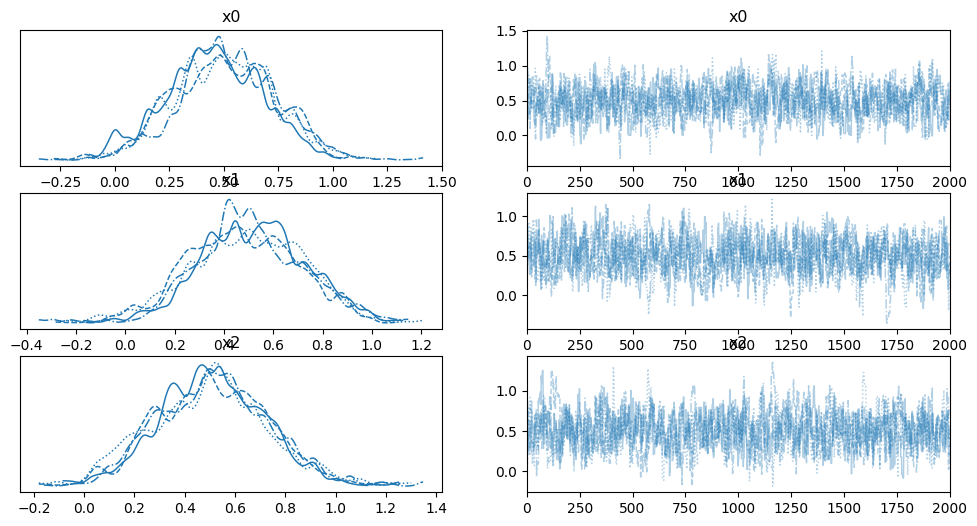

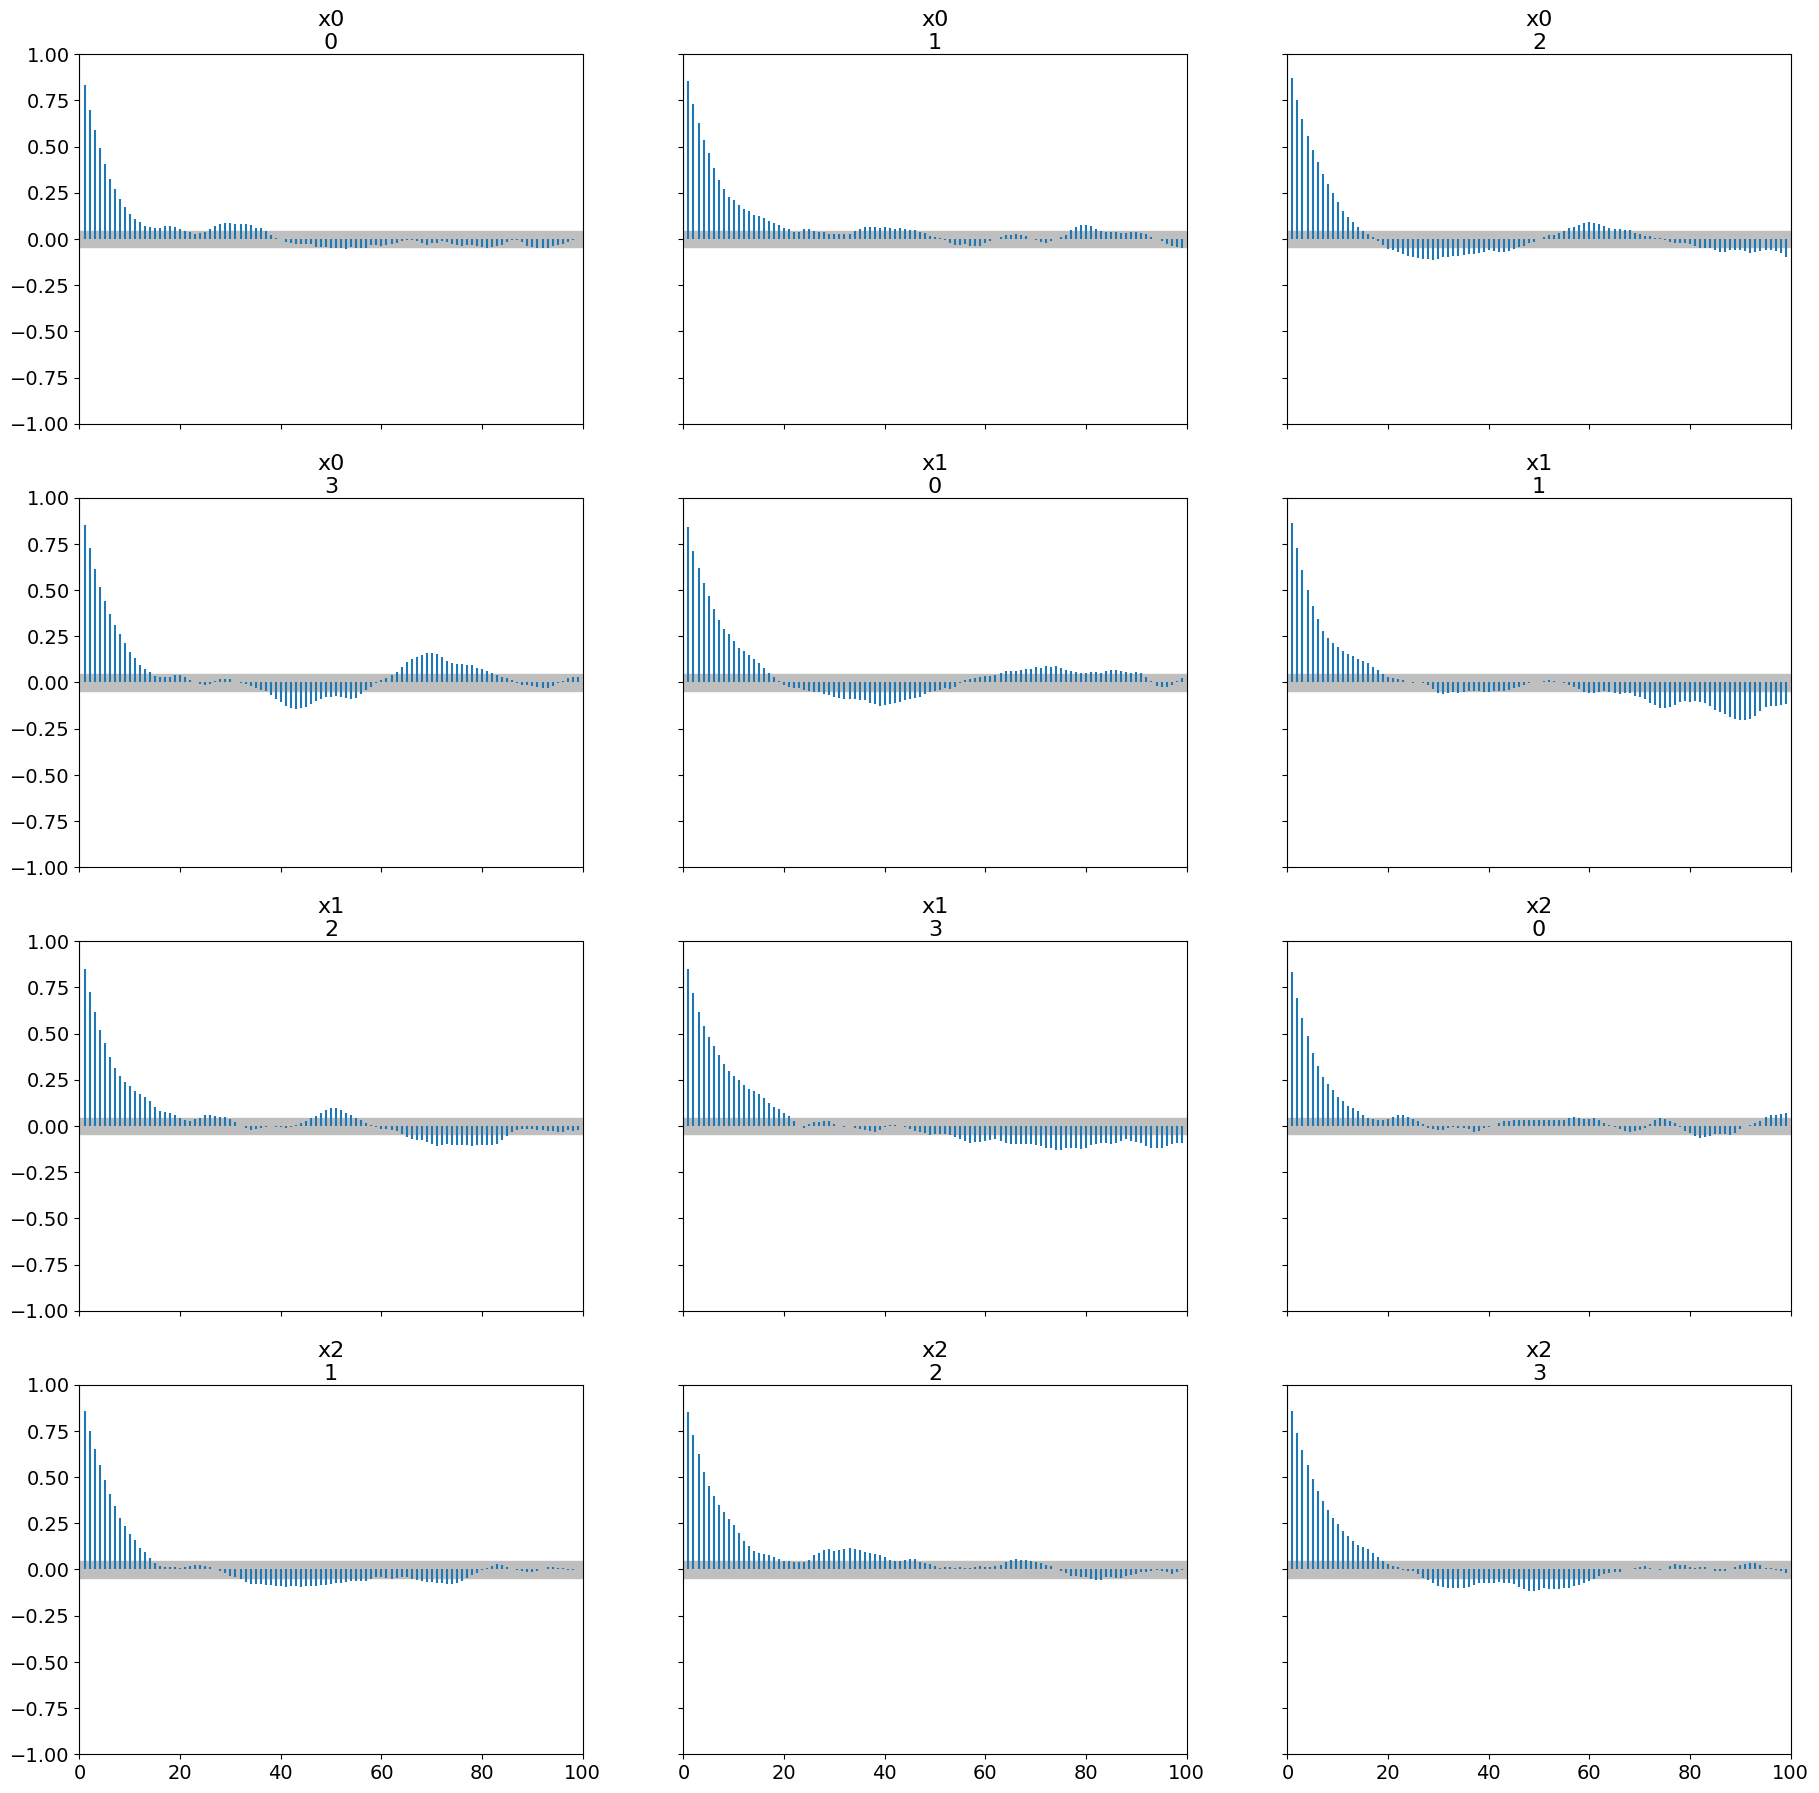

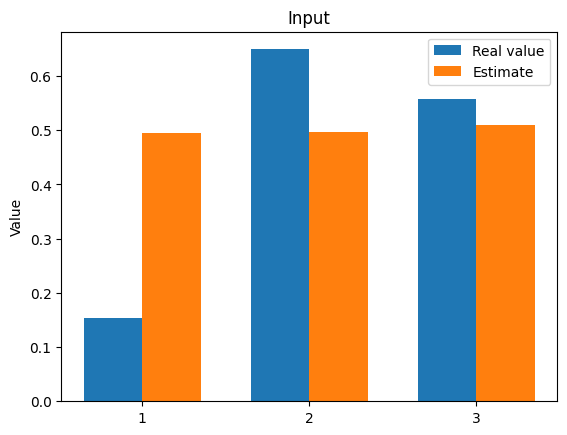

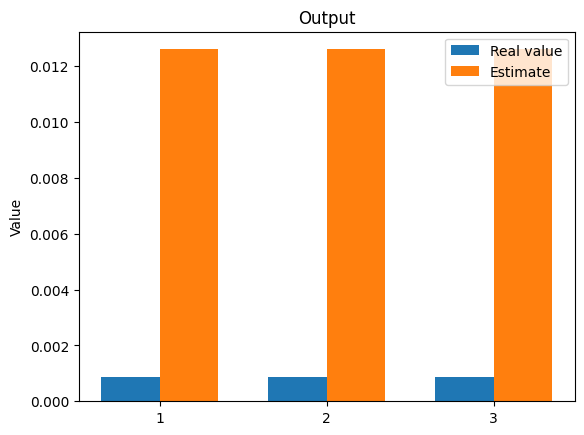

The function inverse took 1345.5281991958618 seconds.
********************  # Nb. basis = 3  ********************
real values are [[0.15373916 0.64911885 0.55741353]]
Sampling chain 1/4


Running chain, α = 0.53: 100%|██████████| 4000/4000 [05:31<00:00, 12.07it/s]


Sampling chain 2/4


Running chain, α = 0.44: 100%|██████████| 4000/4000 [05:30<00:00, 12.11it/s]


Sampling chain 3/4


Running chain, α = 0.41: 100%|██████████| 4000/4000 [05:28<00:00, 12.17it/s]


Sampling chain 4/4


Running chain, α = 0.45: 100%|██████████| 4000/4000 [05:28<00:00, 12.17it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.503 0.496 0.511]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.503  0.220   0.051    0.883      0.009    0.006     645.0     873.0   
x1  0.496  0.223   0.070    0.886      0.008    0.006     704.0    1095.0   
x2  0.511  0.230   0.086    0.949      0.009    0.006     629.0    1002.0   

    r_hat  
x0   1.01  
x1   1.00  
x2   1.01  
Autocorrelation...
[[0.34926084 0.15311885 0.04641353]]


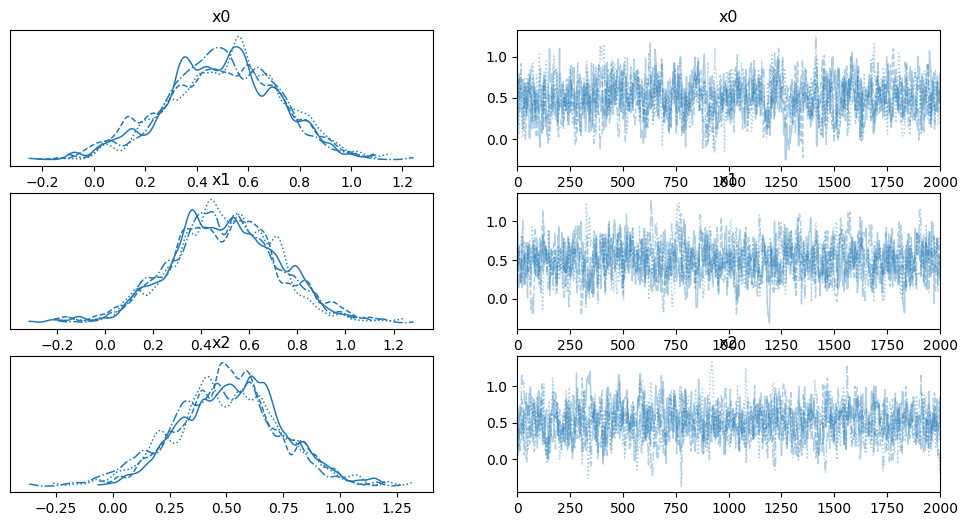

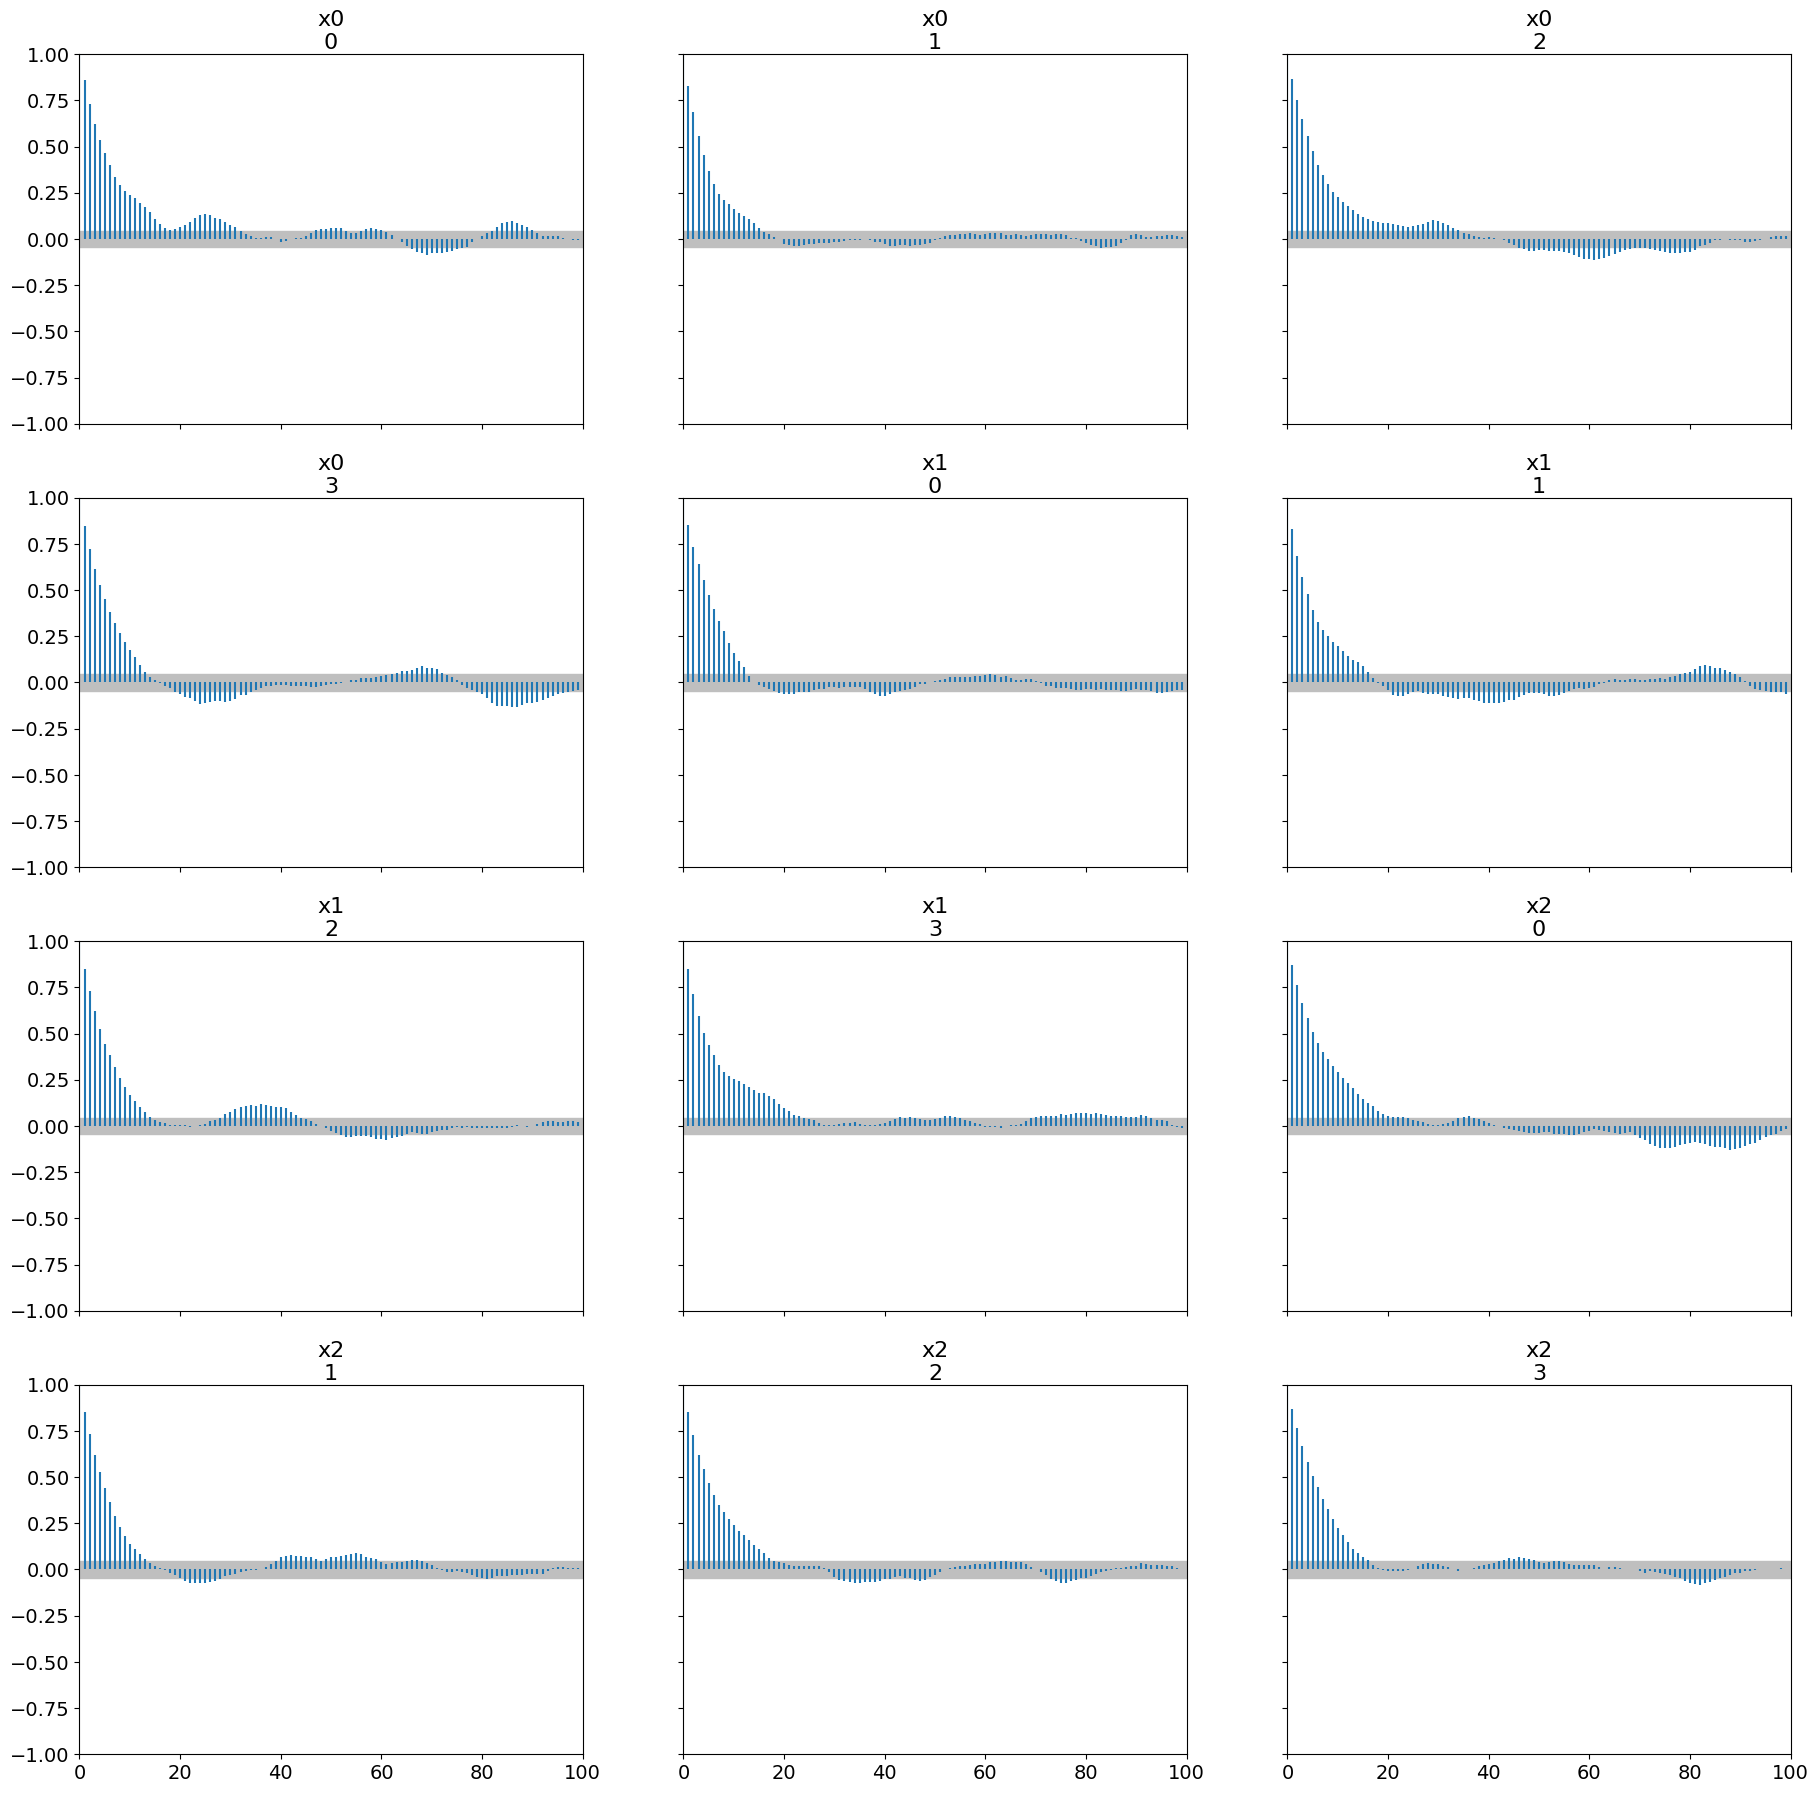

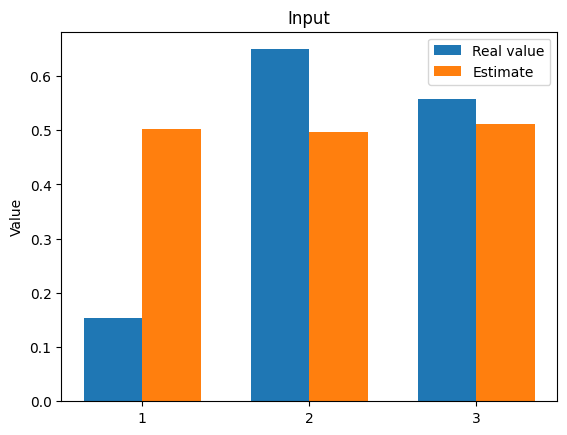

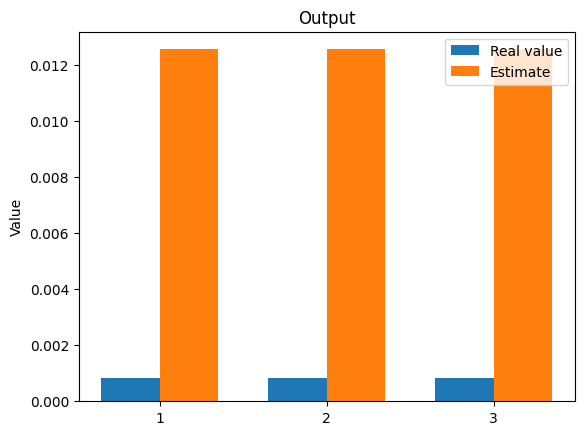

The function inverse took 1340.2063326835632 seconds.
********************  # Nb. basis = 4  ********************
real values are [[0.15373916 0.64911885 0.55741353]]
Sampling chain 1/4


Running chain, α = 0.47: 100%|██████████| 4000/4000 [05:31<00:00, 12.08it/s]


Sampling chain 2/4


Running chain, α = 0.53: 100%|██████████| 4000/4000 [05:29<00:00, 12.14it/s]


Sampling chain 3/4


Running chain, α = 0.46: 100%|██████████| 4000/4000 [05:28<00:00, 12.19it/s]


Sampling chain 4/4


Running chain, α = 0.50: 100%|██████████| 4000/4000 [05:29<00:00, 12.15it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.502 0.507 0.511]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.502  0.223   0.094    0.935      0.009    0.007     574.0     709.0   
x1  0.507  0.233   0.066    0.946      0.010    0.007     557.0     809.0   
x2  0.511  0.223   0.076    0.910      0.010    0.007     532.0    1011.0   

    r_hat  
x0   1.00  
x1   1.00  
x2   1.01  
Autocorrelation...
[[0.34826084 0.14211885 0.04641353]]


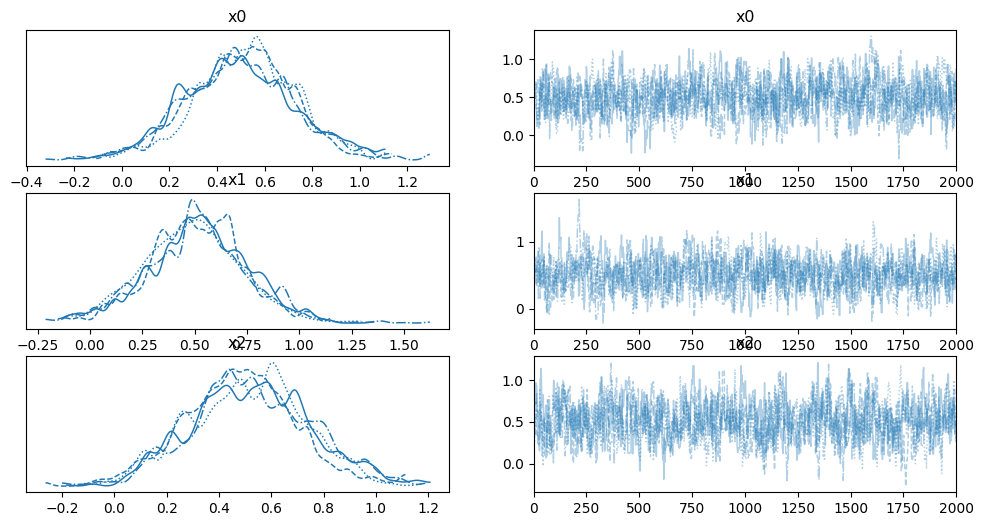

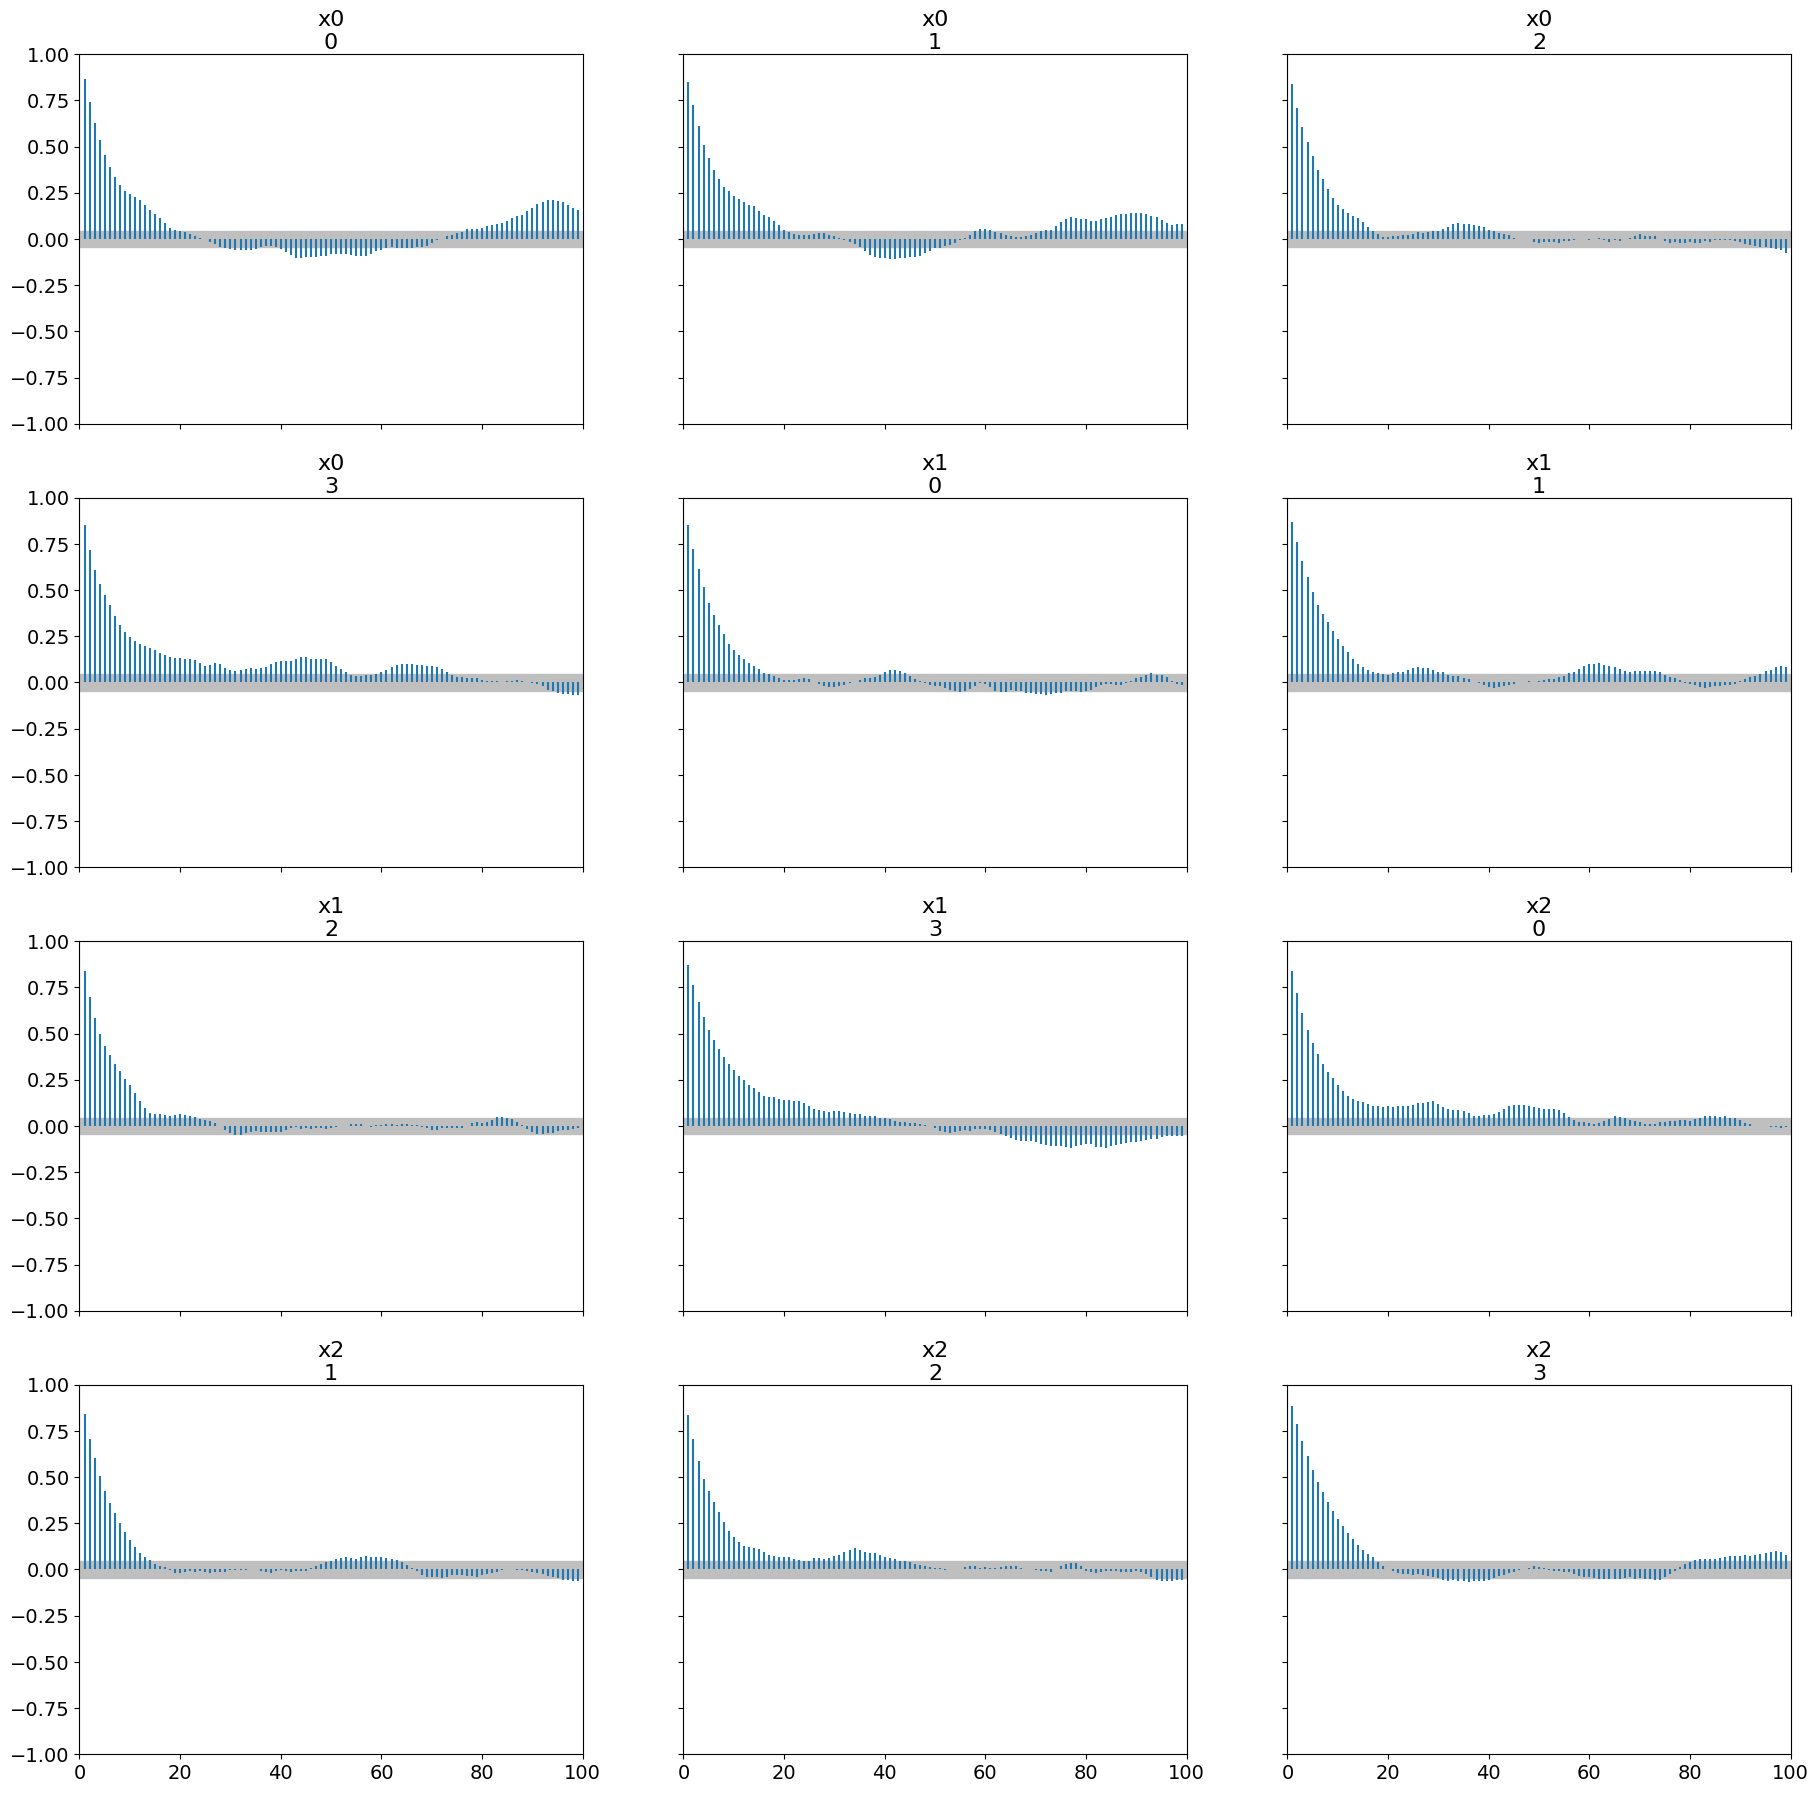

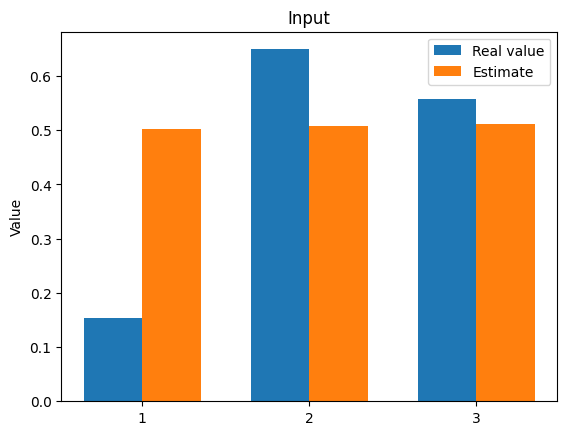

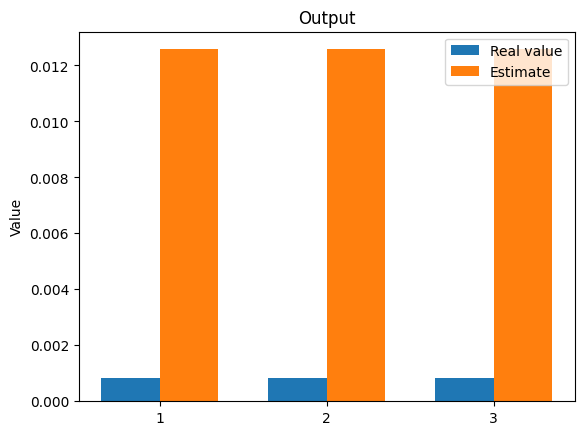

The function inverse took 1368.1416010856628 seconds.
********************  # Nb. basis = 5  ********************
real values are [[0.15373916 0.64911885 0.55741353]]
Sampling chain 1/4


Running chain, α = 0.45: 100%|██████████| 4000/4000 [05:35<00:00, 11.94it/s]


Sampling chain 2/4


Running chain, α = 0.55: 100%|██████████| 4000/4000 [05:32<00:00, 12.03it/s]


Sampling chain 3/4


Running chain, α = 0.41: 100%|██████████| 4000/4000 [05:28<00:00, 12.18it/s]


Sampling chain 4/4


Running chain, α = 0.43: 100%|██████████| 4000/4000 [05:29<00:00, 12.13it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.507 0.486 0.499]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.507  0.215   0.106    0.895      0.009    0.006     620.0    1055.0   
x1  0.486  0.228   0.065    0.915      0.009    0.006     671.0     945.0   
x2  0.499  0.217   0.101    0.933      0.008    0.005     814.0    1107.0   

    r_hat  
x0   1.00  
x1   1.01  
x2   1.01  
Autocorrelation...
[[0.35326084 0.16311885 0.05841353]]


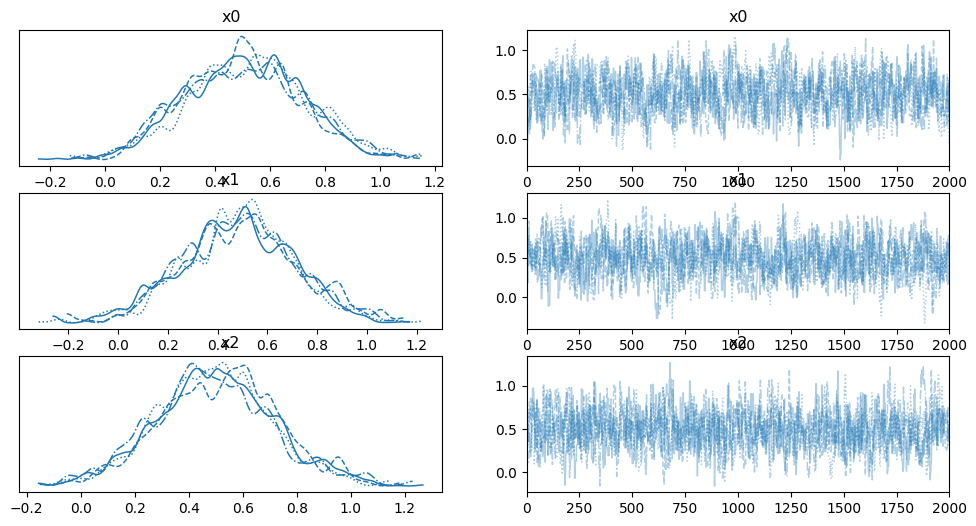

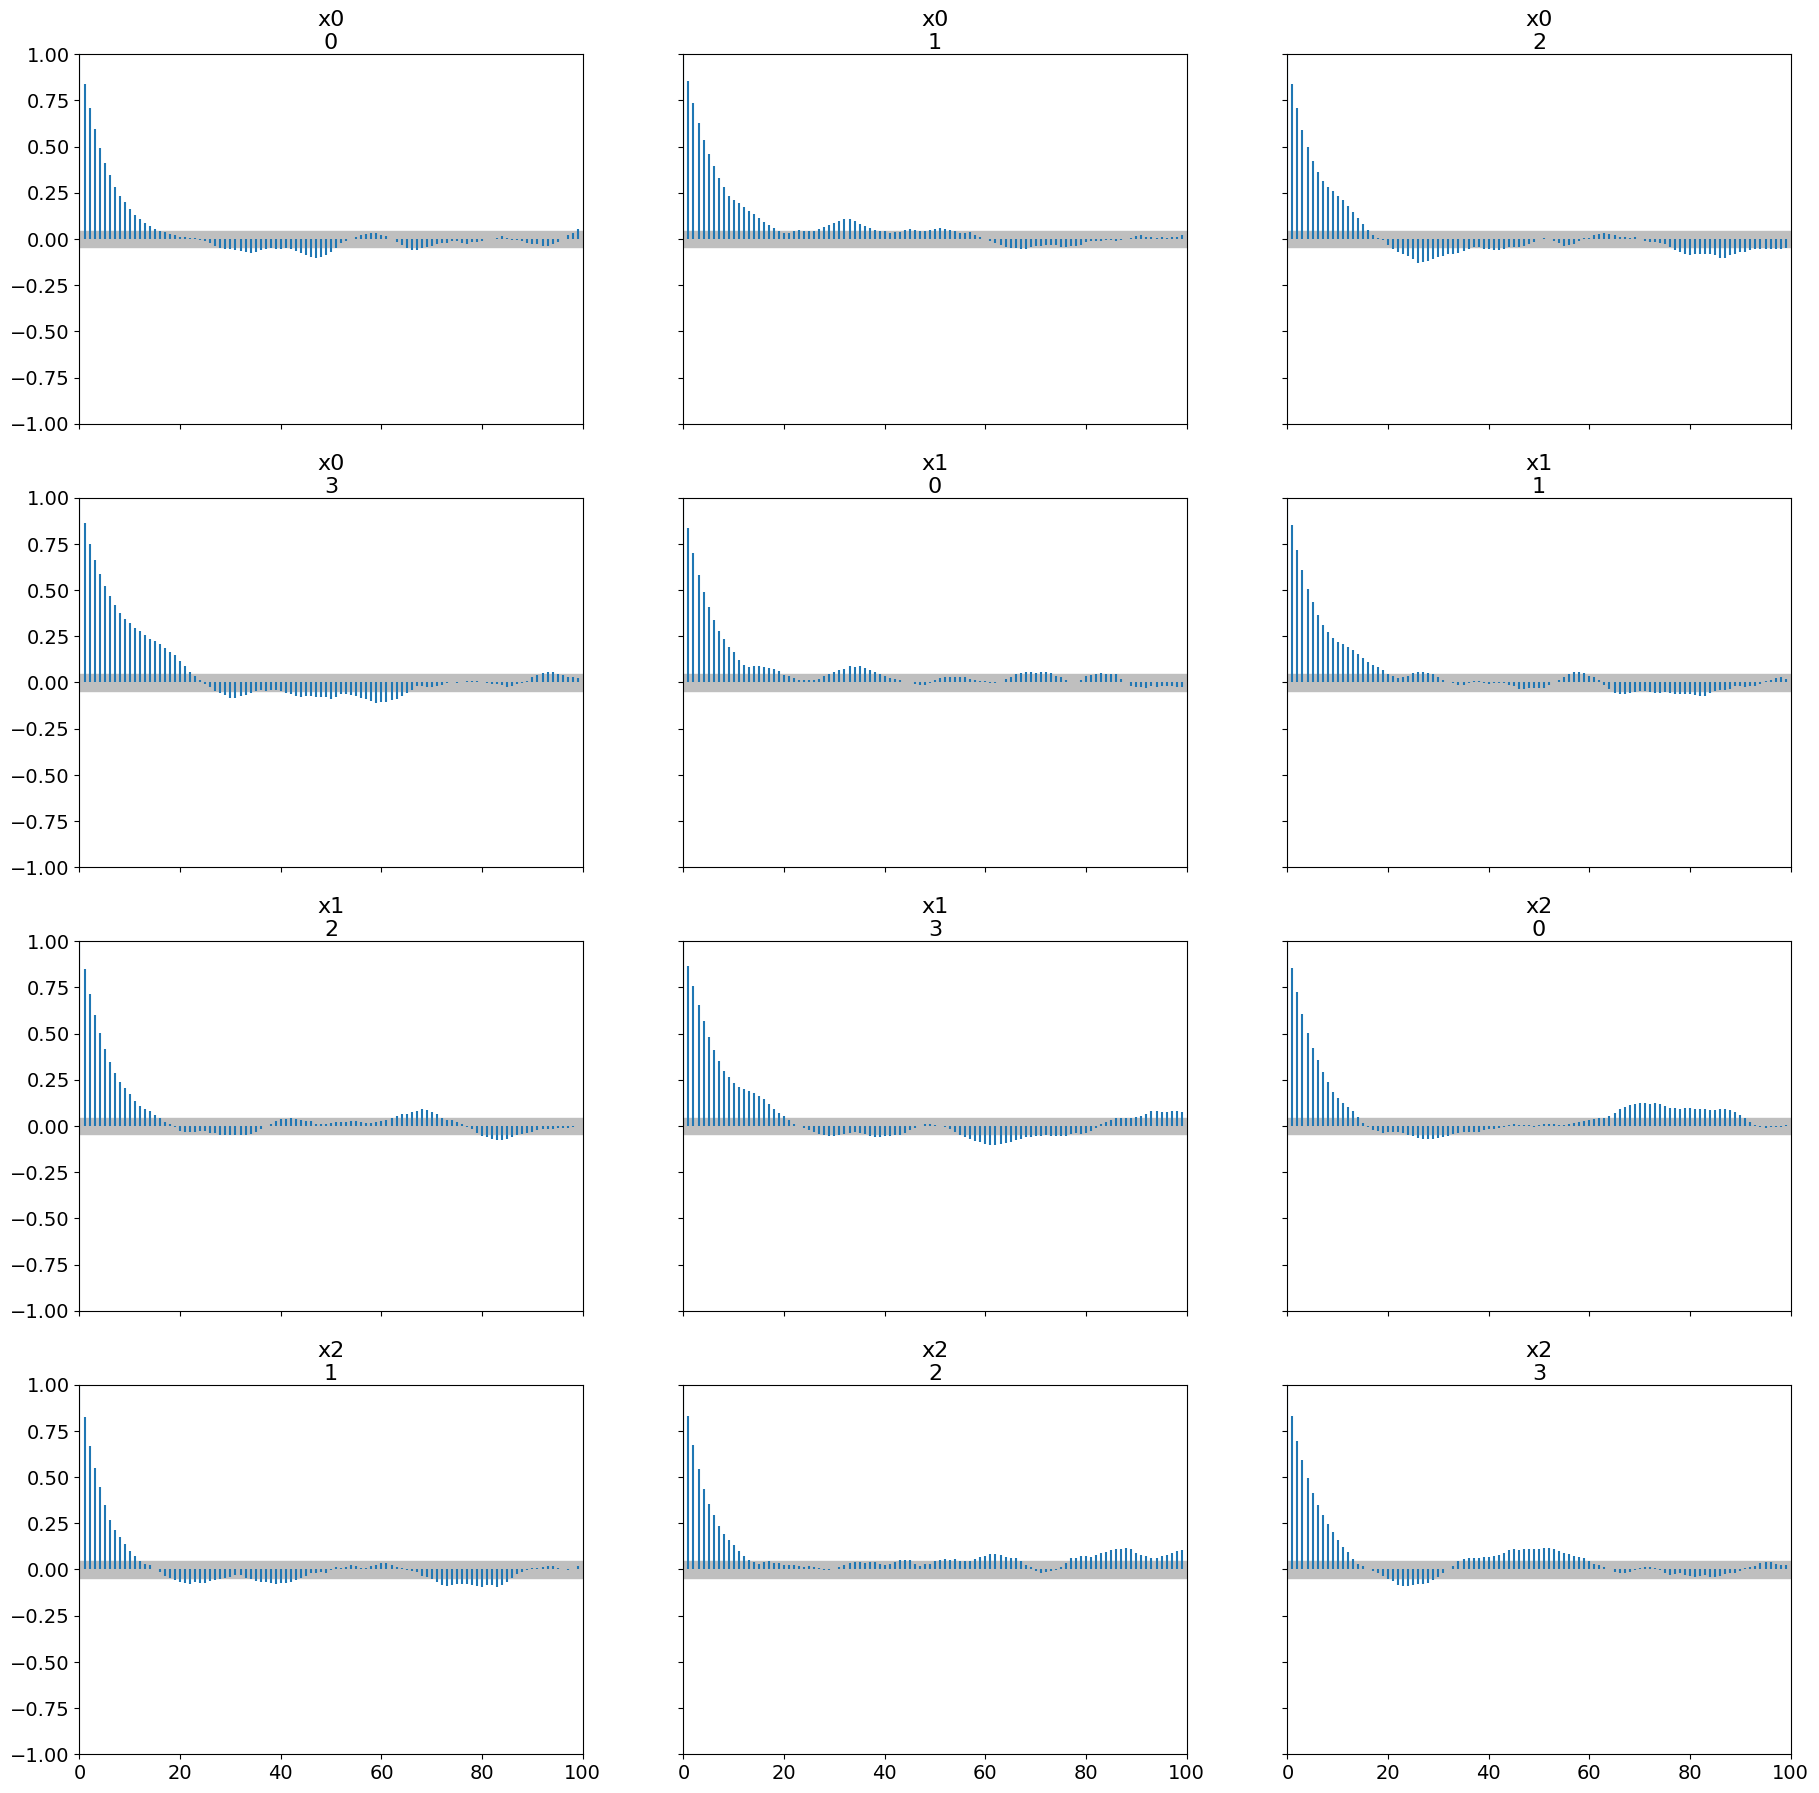

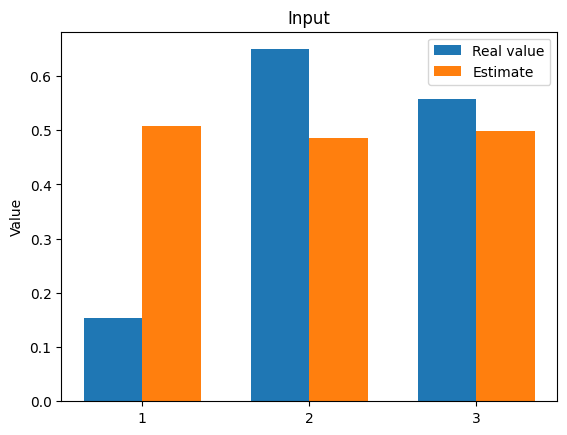

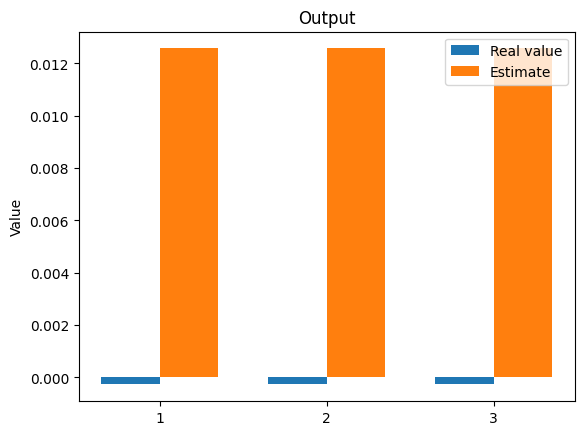

The function inverse took 1352.1599550247192 seconds.
********************  # Nb. basis = 6  ********************
real values are [[0.15373916 0.64911885 0.55741353]]
Sampling chain 1/4


Running chain, α = 0.42: 100%|██████████| 4000/4000 [05:30<00:00, 12.09it/s]


Sampling chain 2/4


Running chain, α = 0.53: 100%|██████████| 4000/4000 [05:30<00:00, 12.10it/s]


Sampling chain 3/4


Running chain, α = 0.50: 100%|██████████| 4000/4000 [05:28<00:00, 12.17it/s]


Sampling chain 4/4


Running chain, α = 0.46: 100%|██████████| 4000/4000 [05:28<00:00, 12.18it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.492 0.49  0.509]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.492  0.218   0.062    0.881      0.009    0.007     553.0     862.0   
x1  0.490  0.219   0.090    0.910      0.008    0.006     710.0     921.0   
x2  0.509  0.215   0.077    0.887      0.008    0.006     651.0    1065.0   

    r_hat  
x0   1.00  
x1   1.01  
x2   1.00  
Autocorrelation...
[[0.33826084 0.15911885 0.04841353]]


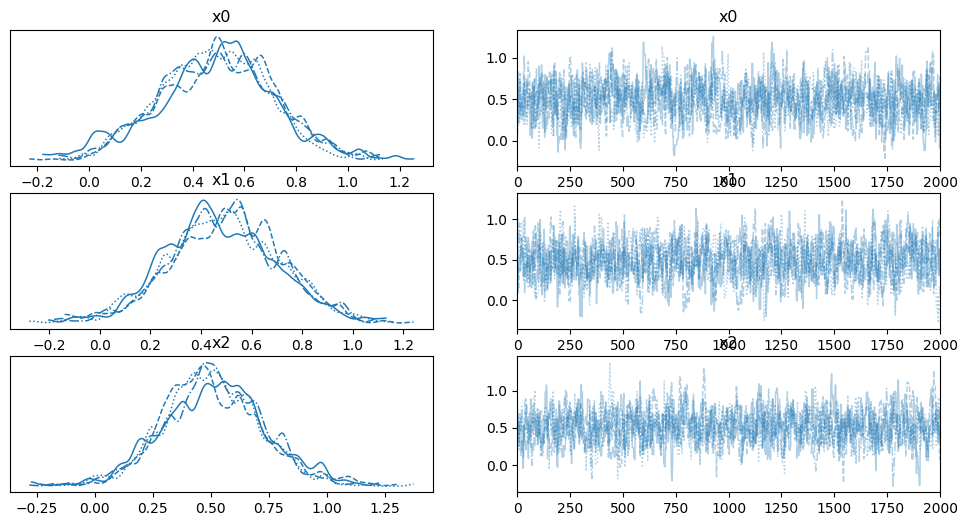

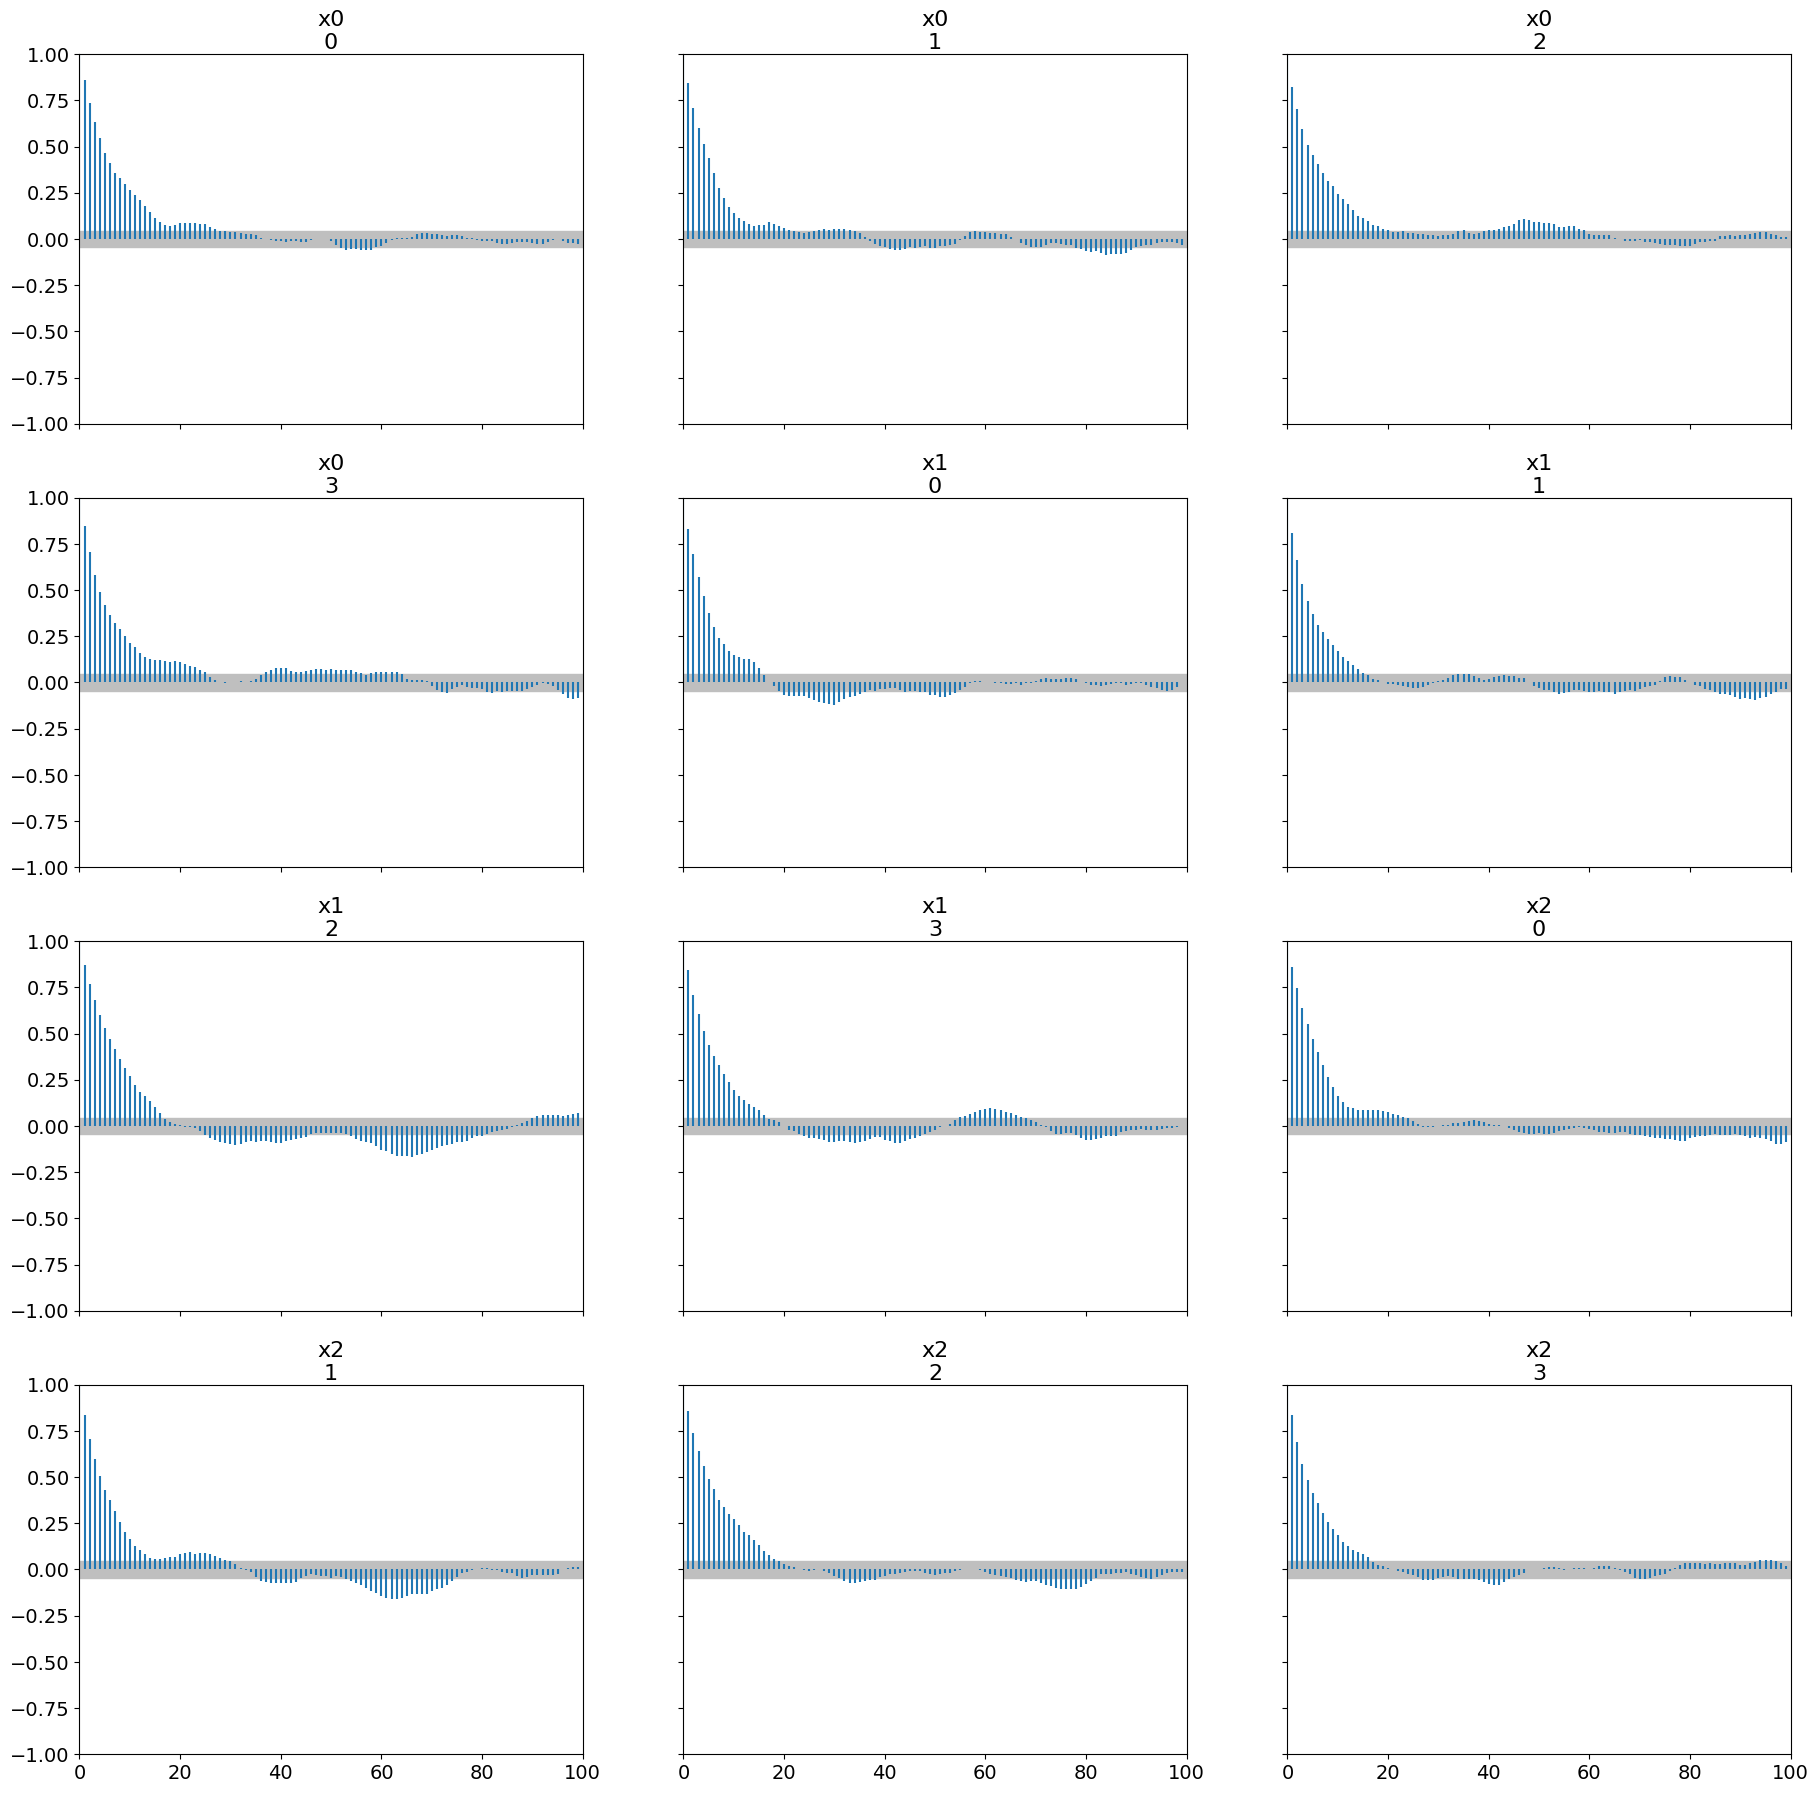

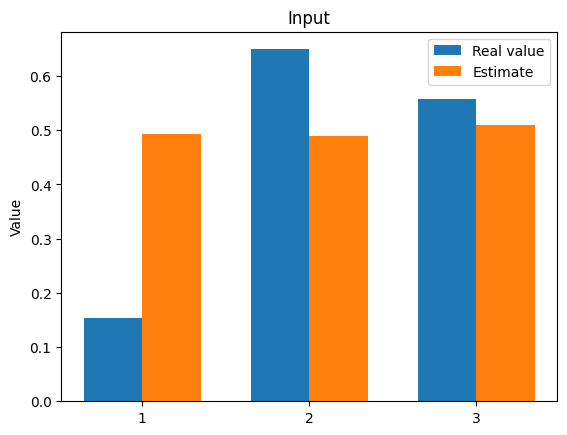

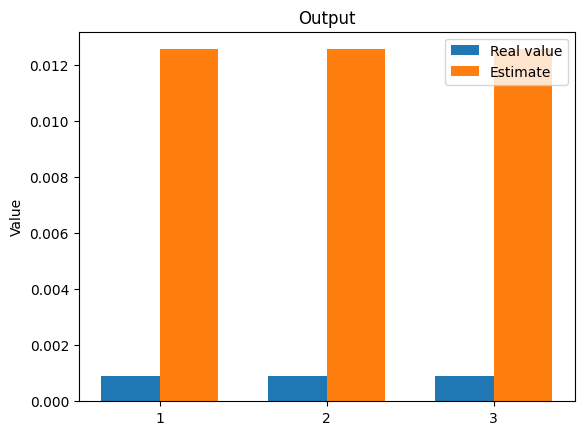

The function inverse took 1338.4043545722961 seconds.
********************  # Nb. basis = 7  ********************
real values are [[0.15373916 0.64911885 0.55741353]]
Sampling chain 1/4


Running chain, α = 0.50: 100%|██████████| 4000/4000 [05:30<00:00, 12.09it/s]


Sampling chain 2/4


Running chain, α = 0.47: 100%|██████████| 4000/4000 [05:32<00:00, 12.04it/s]


Sampling chain 3/4


Running chain, α = 0.55: 100%|██████████| 4000/4000 [05:33<00:00, 11.99it/s]


Sampling chain 4/4


Running chain, α = 0.43: 100%|██████████| 4000/4000 [05:32<00:00, 12.02it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.511 0.511 0.487]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.511  0.216   0.101    0.910      0.008    0.006     651.0     879.0   
x1  0.511  0.228   0.070    0.941      0.009    0.006     643.0     764.0   
x2  0.487  0.233   0.052    0.939      0.010    0.007     539.0     582.0   

    r_hat  
x0   1.01  
x1   1.00  
x2   1.01  
Autocorrelation...
[[0.35726084 0.13811885 0.07041353]]


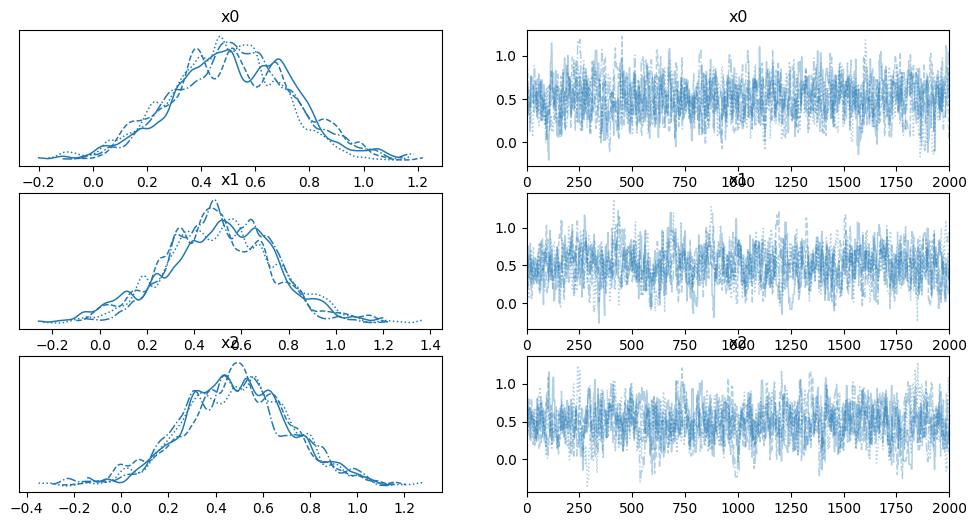

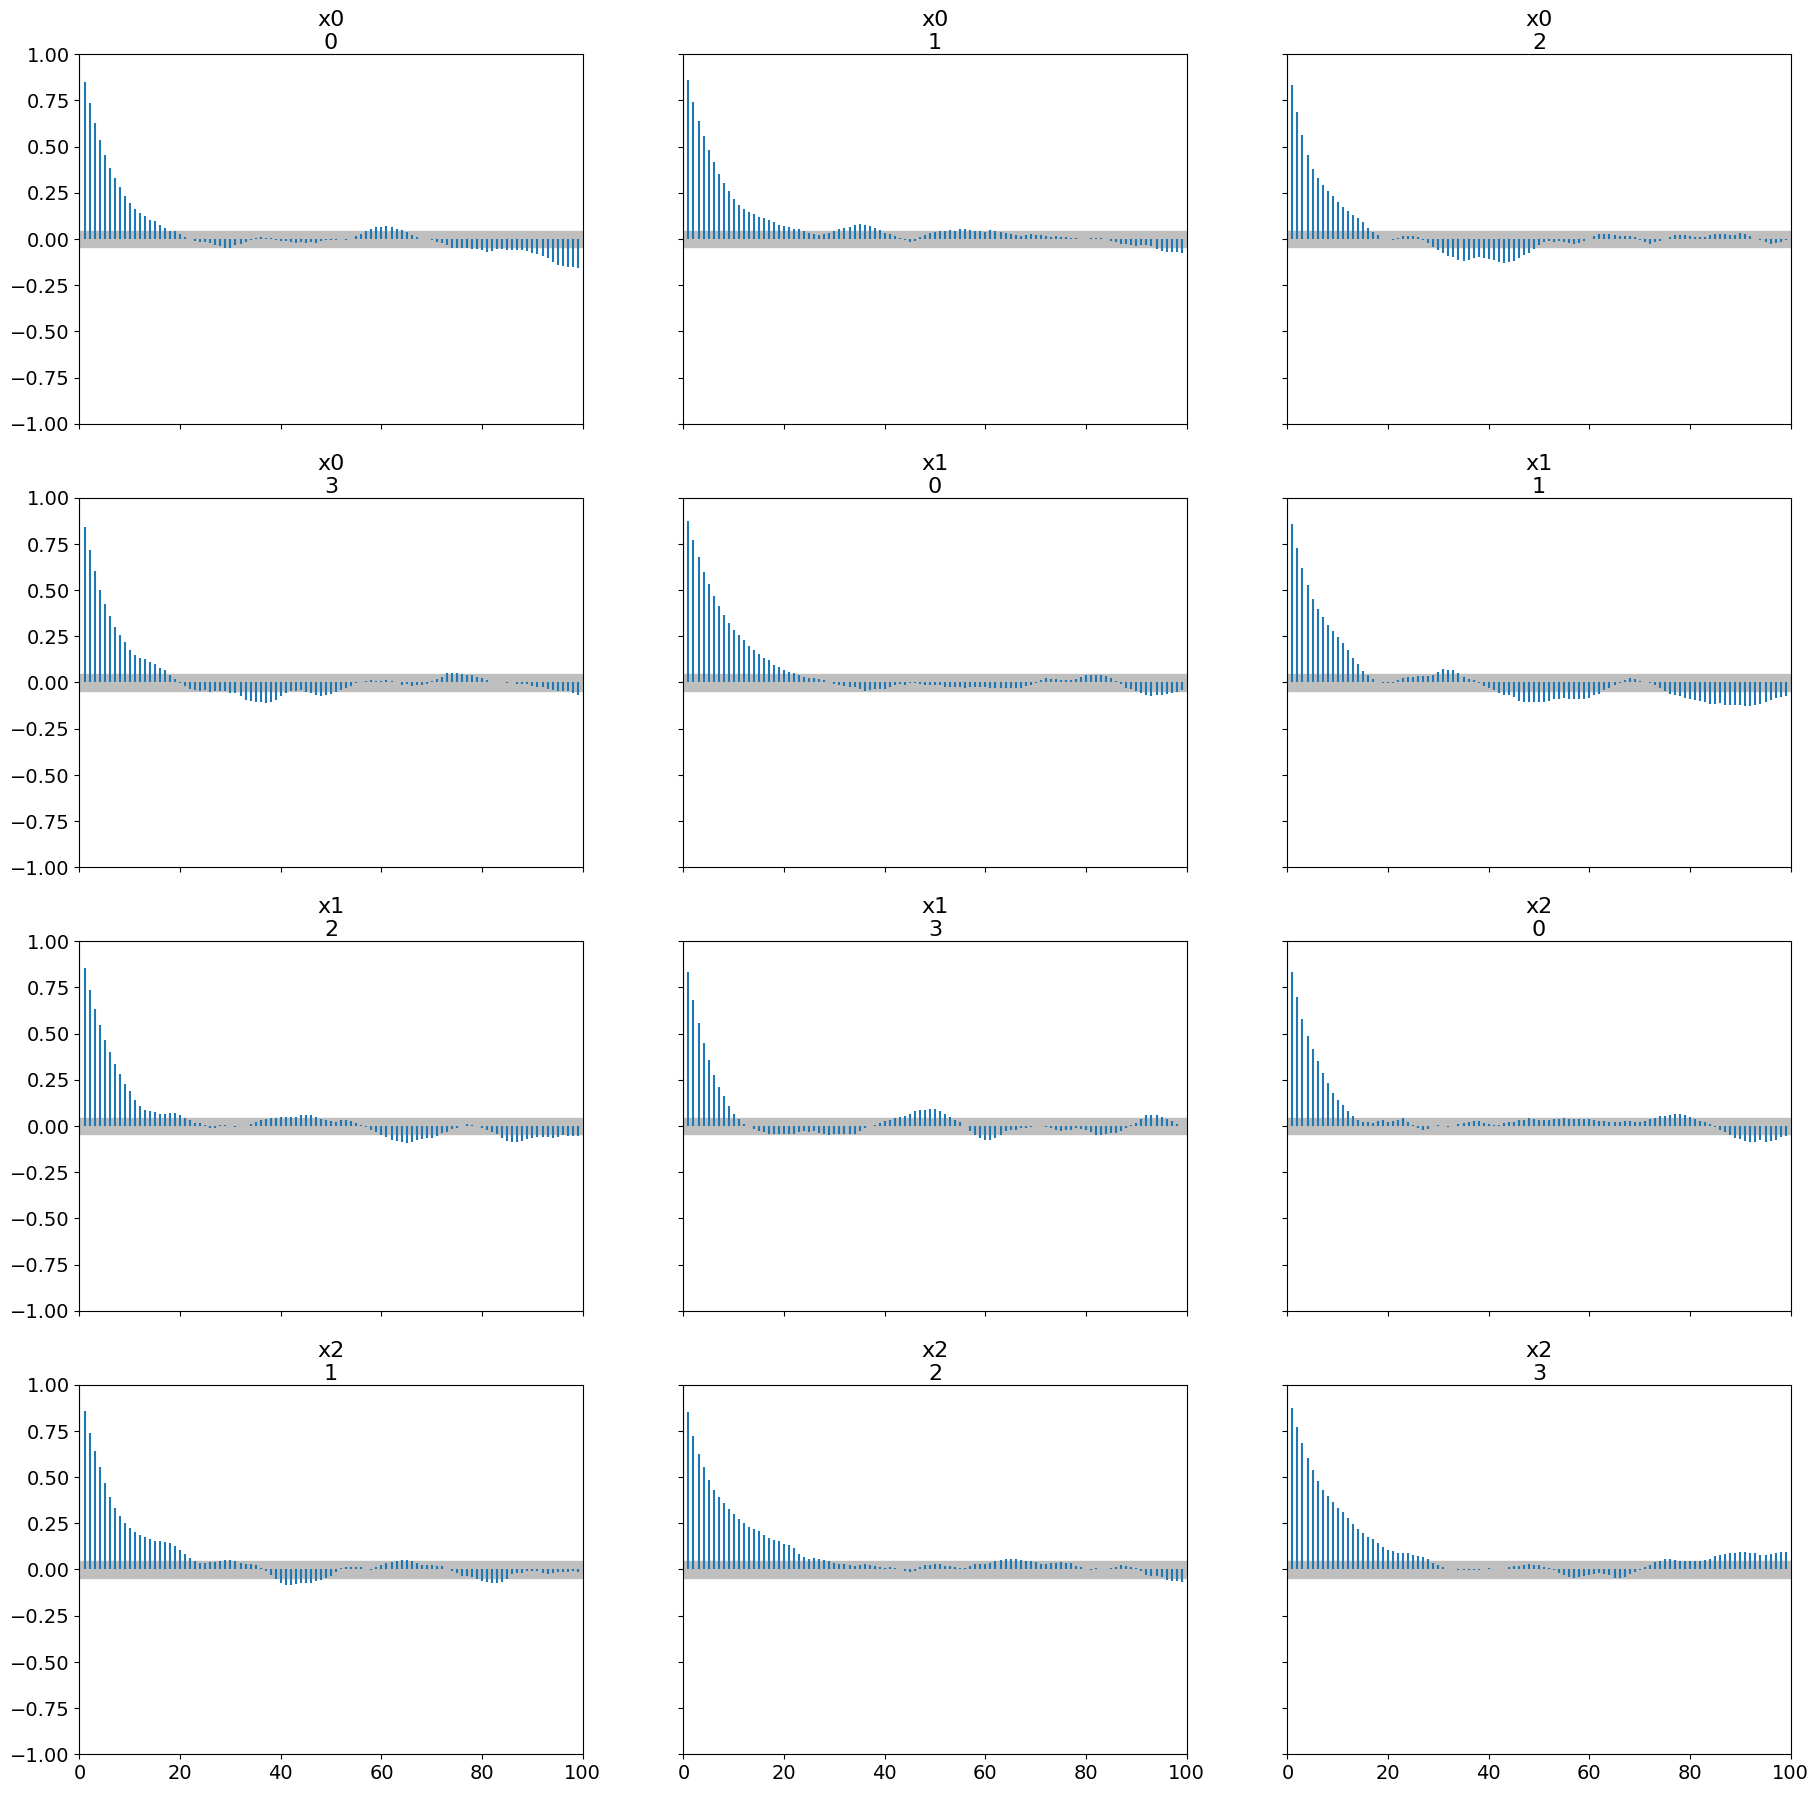

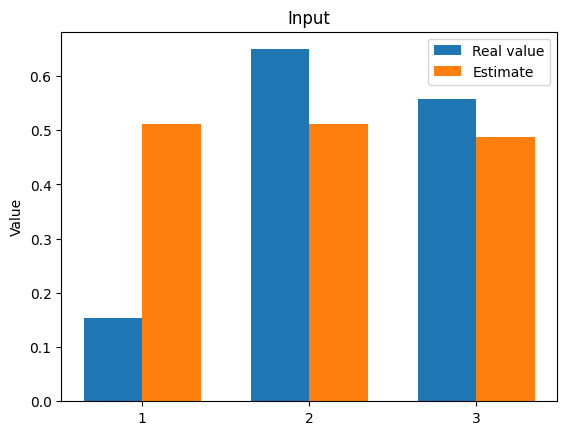

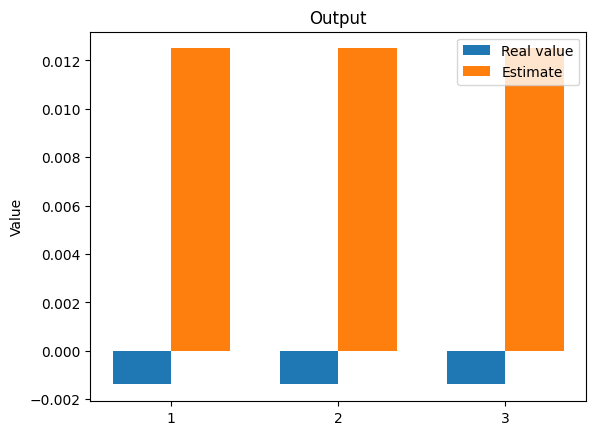

The function inverse took 1349.1620275974274 seconds.


In [ ]:
for j in range(len(model_list)):
    print(
        f"********************  # Nb. basis = {j+1}  ********************"
        )
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")
